# UK Biobank: Academic Impact

This is the sole active notebook for analysis 03. It preserves the complete field,
author, Showcase+ citation, and publication-figure workflows that previously occupied
four separately executed notebooks.

| Part | Retained source | Role | Coverage |
|---:|---|---|---|
| 1 | `03_academic_impact_01_for_analysis.ipynb` | Field-level analysis | Fields of Research volume, concentration, citation impact, quality bands, and growth. |
| 2 | `03_academic_impact_02_citation.ipynb` | Author-level citation analysis | Paper-level normalisation, author metrics, entry cohorts, and influence profiles. |
| 3 | `03_academic_impact_02_citation_extra.ipynb` | Showcase+ citation diagnostics | Disciplinary composition, citation stock, concentration, cohorts, and field-normalised performance. |
| 4 | `03_academic_impact_99_all.ipynb` | Publication figure assembly | The selected main-paper and supplementary panels, their tables, and the selection record. |

Run the notebook from top to bottom. Parts execute in their original order because the
author tables are inputs to the publication figure assembly. Explicit boundary cells
close figures, restore Matplotlib defaults, reset warning filters, and clear the user
namespace between parts. This reproduces the separate-kernel isolation of the source
notebooks without dropping their markdown, diagnostics, figures, or tables.

The source notebook is intentionally stored without cell outputs. Executed copies and
compact logs are written by `run_analysis_notebooks.sh` under `output/notebook_runs/`;
all publication artefacts retain their established output paths and filenames.


# Part I: Fields of Research (ANZSRC FoR 2020)

Where 20 years of UK Biobank publications sit inside the world literature, read through
the **ANZSRC 2020 Fields of Research** classification: how much UK Biobank publishes,
which fields it concentrates in, and how well that work is cited against everyone else
publishing in the same field in the same year.

**Two arms, one denominator.** Every number here compares two count tables built from one
file list: the **UK Biobank arm** (papers that use UK Biobank) and the **background arm**
(everything else Dimensions indexes). The two summed are the **whole database**, which is
the denominator for every share, index and ratio below. Nothing is compared against a
hand-picked control group.

**One publication window, everywhere: 2013–2025.** Both UK Biobank and background
publications use the inclusive 1 January 2013–31 December 2025 window. Citation totals
retain their snapshot date. Missing field-year citation references remain unavailable
and are reported separately; they do not move the publication window. §3.1 audits exclusions.

**The size fact that governs every reading.** UK Biobank is a small share of the tagged
literature; §3 prints the share for the current window. So a *share* of a field is small everywhere by
construction and mostly reproduces "which fields are big", and UK Biobank is far too small
to bend a whole-database curve — a rise during the study is a database-wide trend, not an effect.
The measures that survive this are the **activity index** (§4.5), the **relative citation
impact** (§5) and the **quality bands** (§6).

**Sections**

| § | question | output |
|---|---|---|
| 1 | Setup | environment, repo paths, shared `STYLE`, shared analysis module |
| 2 | Analysis parameters | every switch this run depends on, in one cell |
| 3 | Data layer | load both arms, run the guards, derive the analysis tables |
| 3.1 | **What the window excludes** | the corpus-to-analysis-set audit, for the methods section |
| 4 | **Volume** — how much, and where | Charts 1–4 + the marginal-growth table |
| 5 | **Citation impact** — how well it lands | Charts 5–7 |
| 6 | **Quality bands** — the cut-offs behind the percentiles | §6.1 + Charts 9, 9a, 10 |
| 7 | **Growth** — where UK Biobank is moving next | Chart 11 |

Chart numbers are stable: chart *n* saves as `0n_…` / `n_…` in `STYLE["savedir"]`, and the
same numbers are used in the sibling notebook.

> **Sibling notebook.** [`03_academic_impact_02_rcdc_analysis.ipynb`](../../doc/archive/03_academic_impact_02_rcdc_analysis.ipynb)
> runs this same analysis over the NIH **RCDC** disease/condition vocabulary. Everything the
> two must agree on — loading, guards, the activity index, the citation windows, the impact
> table — lives in `src/utils/data_analysis_03_academic_impact_analysis.py`; only the charts
> live in the notebooks, so a chart cell can be moved between them unchanged.


## 1. Setup

Imports, repo-anchored paths, and the shared plotting style.

* **Paths** — `shared_paths.bootstrap()` anchors every input/output on the repo root, so the
  notebook runs identically from the repo root, `src/`, or `src/data_analysis/`.
* **Style** — palette, font sizes and figure directory come from
  `universal_settings.yml` (`style.notebooks.03_academic_impact`), merged over the shared
  `base` by `load_style`, so every figure in this project draws from one file. `savefig`
  and `extended_palette` read the same registered `STYLE`.
* **Analysis module** — `data_analysis_03_academic_impact_analysis` (imported as `AI`) is
  the data layer shared with the RCDC notebook; see §3.


In [1]:
import json
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, filter_analysis_window
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. load_style merges the shared `base` with this notebook's overrides,
# registers the result for savefig()/extended_palette() and pushes it into rcParams.
from utils.shared_style import (apply_style, extended_palette, load_style, savefig,
                                use_style, year_ticks)
from utils.shared_style import apply_typography, facet_ylabel, set_figure_title, set_title
apply_typography()
STYLE = load_style("03_academic_impact")

# --- the analysis data layer -----------------------------------------------------
# Loading, guards, the activity index, the citation windows and the impact table are
# identical for both classification systems, so they live in one module that this
# notebook and its sibling share. Charts stay here; see the module docstring.
from utils import data_analysis_03_academic_impact_analysis as AI

print("palette:", STYLE["colors"])
print("figures ->", P.raw_path(STYLE["savedir"]), f"(save={STYLE['save']})")


palette: ['#B80C09', '#D4AF37', '#6E8B3D', '#345995']
figures -> output/figures/data_analysis/03_academic_impact (save=False)


## 2. Analysis parameters

Every switch this run depends on, in one cell: which level of the vocabulary to compare on,
how a multi-labelled paper is counted, which citation measures lead, the guards, the year
window, and which pathway produced the counts. Nothing downstream hard-codes a choice made
here, and the cell prints the resulting configuration so any figure can be traced back to it.

**The analysis window — 2013–2025, inclusive.** `ANALYSIS_MIN`/`ANALYSIS_MAX` and
`YEAR_MIN`/`YEAR_MAX` use the shared publication window for both arms, including volume,
activity and author impact. Publication dates are checked when available. Citation
counts retain their original snapshot date. Missing early citation references are
reported as unmeasured; the publication cohort still starts in 2013. Pre-2013 comparisons
are unavailable because those publications lie outside the study window.

**The vocabulary.** ANZSRC 2020 Fields of Research is a two-level hierarchy: `FOR_LEVEL="L4"`
compares fine fields (*4202 Epidemiology*), `"L2"` broad divisions (*42 Health Sciences*).
"Field" below always means a category at the level set here.

**Where the counts come from** (`SOURCE`):

* `"vm"` — counted row by row off the Dimensions corpus copy on BMRC by
  `src/utils/data_analysis_03_academic_impact_field_counts.py --category for`. A **fixed
  snapshot**, and the only pathway that can carry fractional counts and citation weights.
* `"api"` — **this run.** The whole-database counts faceted straight out of the Dimensions
  API by `src/utils/data_analysis_03_academic_impact_dimensions_api.py`, with the UK Biobank
  arm fetched per paper from the same live index in the same pass. Aggregates only on the
  background side, so there is no fractional column there and no per-paper FCR — but both
  arms are one index read on one day, which is what makes the subtraction
  `background = whole − ukbb` exact. The VM contributes only the id list that says which
  papers are UK Biobank's.

Both arms always come off one file list, and everything downstream adapts rather than
breaks: measures only one arm carries are dropped (and said so), the activity index falls
back to whole counting when there is no fractional column, and the citation sections skip
themselves.

**Sibling notebook.** A guard fixed here is fixed in
[`03_academic_impact_02_rcdc_analysis.ipynb`](../../doc/archive/03_academic_impact_02_rcdc_analysis.ipynb)
too — the shared logic lives in `src/utils/data_analysis_03_academic_impact_analysis.py`.


In [2]:
COL_TYPE = "for"

# Which level of the hierarchy to compare on:
#   "L4" = fine field       (e.g. 4202 Epidemiology)
#   "L2" = broad division   (e.g. 42 Health Sciences)
FOR_LEVEL = "L4"

# FOR has no sub-vocabulary to slice; the RCDC notebook uses this to separate diseases
# from cross-cutting tags. Kept here so both notebooks share one build cell verbatim.
RCDC_VIEW = "all"

# THE ANALYSIS WINDOW ---------------------------------------------------------
# Every primary analysis includes publications from 2015 through 2025 (D19).
# Early papers remain in volume and eligible citation metrics. A field-year without
# a measured citation reference remains unavailable; it is never assigned zero impact.
#
# 2015, NOT the project-wide ANALYSIS_START_YEAR of 2013. The shared constant is where
# the CORPUS is cut; this is where this analysis can MEASURE. Three independent limits
# put it two years higher: UK Biobank published 27 papers in 2014 against 63 in 2015,
# `percentiles --min-ukbb 10` measured no 2014 cell in any field so field_thresholds.csv
# has no 2014 row at all, and CITE_MIN_DOCS would drop 2014 regardless. D19 considered
# 2014 for a rounder window and rejected it.
ANALYSIS_MIN = 2015
ANALYSIS_MAX = ANALYSIS_END_YEAR

# Kept under its old name because the module's signature and the charts' "first year"
# reference line both use it; it now means the first year of the analysis window.
UKBB_YEAR = ANALYSIS_MIN

# How many of UK Biobank's OWN top fields to follow through the whole database.
TOP_N = 8

# Counting metric for the VOLUME charts:
#   "n_papers" = a paper counts once in EVERY field it carries (absolute)
#   "n_frac"   = its weight split evenly across its fields (per-level fractional)
# For FOR the two agree closely, unlike RCDC where a UK Biobank paper carries nearly twice
# the tags of an average one. UK Biobank carries 1.49 L4 codes per paper, measured
# directly off the records (§3.1 prints it). The database's own figure CANNOT be measured
# this way — a facet returns per-cell totals, never the union of papers behind them — so
# the closest available check is the L4/L2 count ratio over the window: 1.06 for the
# database against 0.99 for UK Biobank. Close enough that n_papers and n_frac agree. Shares of a single field are absolute; anything comparing ACROSS fields
# uses the fractional columns regardless of this line.
WEIGHT = "n_papers"

# CITATION METRICS ------------------------------------------------------------
# Which citation quantities exist depends on how the counts were built; this run (API)
# carries four, and the loader prints the list it actually found:
#   "n_cit"     raw times_cited        — citation mass. Accrues with age, and is NOT
#                                        normalised by year, so it is used for SHARES
#                                        and descriptive means only — never as an
#                                        rci_ ratio. See RCI_WEIGHTS in the module.
#   "n_mncs"    times_cited / the mean of its own (year, field) — 1.0 = the field's
#                                        average paper that year. The headline.
#   "n_top10f"  1.0 if the paper is in the most-cited tenth OF ITS OWN (year, field),
#                                        against a cut-off MEASURED by counting
#                                        (dimensions_api.py deciles).
#   "n_top50f"  1.0 if it is at or above that (year, field)'s MEDIAN.
# The VM pathway carries "n_fcr" (Dimensions' own field citation ratio) and "n_top10"
# (the decile of the whole corpus rather than of the field) in place of the last two.
#
# NOT CARRIED ANY MORE: "n_top10p", the proxy that called a paper top-decile when its
# mncs cleared a K calibrated per (year, type). The `deciles` mode measures the real
# per-field cut-off now, so the proxy adds nothing — and it was the weight with the
# shortest usable window, which held the whole impact window back a year. The column is
# no longer in the partials either: the current API run does not write it, and the
# analysis module does not list it. Both would have to be put back to see it again.
#
# CITE_HEADLINE   the intensity measure the impact map and the time panel lead with.
#                 A REQUEST, not a fact: if the run has no FCR (the API pathway does
#                 not) the loader substitutes n_mncs and says so.
# CITE_SHARE_METRIC  what Chart 7 tracks: UK Biobank's share of the world's ___ in a
#                 field. Set it to "n_papers" to see the volume baseline on the same
#                 axes, or "n_cit" for the share of the field's citations.
CITE_HEADLINE = "n_mncs"
CITE_SHARE_METRIC = "n_top10f"

# WHERE THE MEASURING FLOOR IS ------------------------------------------------
# The API job measures a (year, field) cut-off only where UK Biobank has at least this
# many papers in the cell — `percentiles --min-ukbb` in
# data_analysis_03_academic_impact_dimensions_api.py. It is written down here because the
# notebook's own per-year floor has to sit AT OR ABOVE it: a year-cell this notebook is
# willing to DRAW has to be one that was MEASURED, or the panel loses its left edge to
# cells that were never thresholded.
API_MIN_UKBB = 10

# A field-window with a handful of UK Biobank papers has a mean citation rate that is
# noise, so the impact measures drop anything thinner than these. The two floors below are
# not the same quantity and are not comparable to each other:
#
#   CITE_MIN_DOCS       pooled over the WHOLE impact window. The floor under a field's
#                       single RCI number in the IMPACT table (charts 5 and 6-left): how
#                       many UK Biobank papers in that field carried a citation value at
#                       all, summed across every year of the window.
#   CITE_MIN_DOCS_YEAR  within a SINGLE year. The floor under one cell of the RCI time
#                       series (chart 6, right), where a ratio of two means is at its
#                       noisiest, and the one that has to clear API_MIN_UKBB.
#
# 50 over the thirteen-year window is under four papers a year, so it is a far weaker
# per-year condition than CITE_MIN_DOCS_YEAR — a pooled figure survives thin years, an
# individual year does not.
CITE_MIN_DOCS = 50       # over the whole impact window
CITE_MIN_DOCS_YEAR = 20  # within a single year; >= API_MIN_UKBB by construction
assert CITE_MIN_DOCS_YEAR >= API_MIN_UKBB, (
    f"CITE_MIN_DOCS_YEAR ({CITE_MIN_DOCS_YEAR}) is below the API's measuring floor "
    f"({API_MIN_UKBB}): the notebook would draw year-cells whose cut-offs were never "
    f"measured. Raise it, or re-measure with "
    f"`percentiles --min-ukbb {CITE_MIN_DOCS_YEAR}`.")

# How the usable citation window is derived (see the module for the reasoning):
#   a year needs CITE_COV_MIN of papers measured IN BOTH ARMS to be usable at all, and
#   the weights that are NOT year-normalised then drop CITE_LAG further years, because
#   a 2024 paper has not been cited yet however completely it is indexed.
#
# CITE_LAG = 0, deliberately, and it is safe here because of WHICH weights this run
# carries. The lag protects a comparison that puts young papers against old ones. That
# cannot happen to any weight below:
#   n_mncs, n_top10f, n_top50f  are each scored against a reference measured INSIDE
#       their own (year, field) — the field's mean that year, the field's decile cut-off
#       that year, the field's median that year. A 2024 paper is judged against 2024's
#       bar. (The module lists all three in YEAR_NORMALISED, so the lag would not reach
#       them anyway; this line only ever bites n_cit.)
#   n_cit  is never divided into a ratio — see RCI_WEIGHTS and the note in §5. It is
#       used as a SHARE and as a descriptive mean, and in both the numerator and the
#       denominator are the same year's papers from the same index, so immaturity
#       cancels rather than biasing.
# Set it back to 1 if a weight that accrues with age is ever given a ratio.
CITE_COV_MIN = 0.5
CITE_LAG = 0

# WHAT THE ACTIVITY INDEX IS MEASURED AGAINST ---------------------------------
# The index is a ratio of shares, so it depends entirely on what "the database" means:
#   "global"         every paper Dimensions indexes, art history included
#   "universe"       restricted to UNIVERSE_DIVISIONS below
#   "within_parent"  each L4 field against its own L2 division, both arms
#
# Worth knowing before choosing: "universe" divides EVERY field's index by one and the
# same constant (historical calibration: 2.70 over 2015-2025 — UK Biobank has 93% of its mass in
# those divisions against the database's 34%), so it re-ranks nothing; it only moves where
# parity sits. "within_parent" is the one that removes "UK Biobank is a biomedical
# resource" from the comparison per field, and it does re-rank: Public Health reads 4.7x
# globally and 0.9x within Health Sciences — against all research it looks like a
# speciality, against health research UK Biobank is slightly under-represented in it.
# Epidemiology 61.4x -> 12.0x.
ACTIVITY_BASE = "within_parent"
UNIVERSE_DIVISIONS = ("31", "32", "42", "52")   # bio, biomedical, health, psychology

# How far back the BACKGROUND arm is carried. D19 sets this to 2004 so a field's
# twenty-year trend has something to be a trend against, and it is deliberately NOT part
# of the analysis window. It is left at the project floor here because `AI.load_arm` puts
# every partial through `filter_analysis_window` before applying year_min, and that
# filter floors at 2013 — so a 2004 written here would be discarded and read as a longer
# history than the charts actually have. Relax that filter for the background arm before
# restoring 2004.
YEAR_MIN = ANALYSIS_START_YEAR
YEAR_MAX = ANALYSIS_MAX

BEFORE_WIN = None                         # pre-study years are outside this analysis
AFTER_WIN  = (ANALYSIS_MIN, ANALYSIS_MAX)     # the analysis window itself

# LABEL QUALITY GUARD ---------------------------------------------------------
# A year where the background arm's category labels came back blank has no usable
# whole-database denominator, so any share computed from it is meaningless. Both
# guards are tripwires: with both arms counted from one snapshot they are currently
# inert, and that is exactly when they are worth keeping.
BLANK_MAX = 0.05
MASK_BAD_DENOM = True

# VOCABULARY SKEW GUARD -------------------------------------------------------
# A tag whose vocabulary changed between two snapshots has a real numerator and a
# near-empty denominator. Any field where UK Biobank exceeds this share of the world
# is that artefact, not a finding. None keeps them.
SKEW_MAX_SHARE = 5.0

# WHERE THE COUNTS COME FROM ---------------------------------------------------
# Two pathways produce the same tables, and both are kept because they answer
# different amounts of the question:
#
#   "vm"   counted row by row off the Dimensions corpus copy on BMRC by
#          data_analysis_03_academic_impact_field_counts.py. Slow to run, but it is a
#          FIXED SNAPSHOT and it can count anything a row contains — fractional counts,
#          citation weights, the top-decile indicator.
#   "api"  the whole-database counts faceted straight out of the Dimensions API by
#          data_analysis_03_academic_impact_dimensions_api.py — about twenty queries for
#          the whole year x field matrix. Aggregates only: no fractional column and no
#          citation weights, and it is the LIVE index rather than the snapshot the UK
#          Biobank arm came from.
#
# Everything downstream adapts rather than breaks: the loader drops any measure only one
# arm carries and says so, the activity index falls back to whole counting when there is
# no fractional column, and the citation sections skip themselves.
SOURCE = "api"

# WHERE THE PARTIALS LIVE ------------------------------------------------------
# One output directory holds every category's partials; they are named per-category,
# and the two pathways write the same filenames into different directories.
COUNTS_DIR = AI.resolve_counts_dir(P.FOR_COUNTS if SOURCE == "vm" else P.FOR_COUNTS_API)

print(f"source={SOURCE}   category={COL_TYPE}   level={FOR_LEVEL}   weight={WEIGHT}   top-N={TOP_N}")
print(f"citation: headline={CITE_HEADLINE}  share metric={CITE_SHARE_METRIC}  lag={CITE_LAG}")
print(f"ANALYSIS WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX} — every UK Biobank measure, volume "
      f"and citation alike")
print(f"background history {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")


source=api   category=for   level=L4   weight=n_papers   top-N=8
citation: headline=n_mncs  share metric=n_top10f  lag=0
ANALYSIS WINDOW 2015-2025 — every UK Biobank measure, volume and citation alike
background history 2013-2025   before=None  after=(2015, 2025)


## 3. Data layer — load both arms, run the guards, derive the analysis tables

One call does the whole data layer: resolve which partials belong to which arm, drop
blank-labelled years, build the whole-database denominator (= both arms summed), rank UK
Biobank's own top fields, compute the activity index, derive the usable citation window
from coverage, and build the per-field impact table.

**Read the printed output** — it says what was guarded against as it went, which is the
difference between "this field shrank" and "the classification got sparser that year". It
closes with UK Biobank's overall share of the database and its top `TOP_N` fields with
share and activity index side by side.

`globals().update()` is deliberate: it puts the frames into the notebook under their own
names (`whole_ts`, `TOP_CODES`, `IMPACT`, …), so a chart cell reads the same here as in the
RCDC notebook and can be moved between them unchanged. Everything it injects is listed in
`AI.build`'s docstring.


In [3]:
CTX = AI.build(
    COUNTS_DIR, COL_TYPE,
    level=FOR_LEVEL, rcdc_view=RCDC_VIEW,
    year_min=YEAR_MIN, year_max=YEAR_MAX, ukbb_year=UKBB_YEAR,
    top_n=TOP_N, weight=WEIGHT, palette=extended_palette,
    blank_max=BLANK_MAX, mask_bad_denom=MASK_BAD_DENOM,
    skew_max_share=SKEW_MAX_SHARE,
    cite_headline=CITE_HEADLINE, cite_min_docs=CITE_MIN_DOCS,
    cite_cov_min=CITE_COV_MIN, cite_lag=CITE_LAG,
    activity_base=ACTIVITY_BASE, universe_divisions=UNIVERSE_DIVISIONS,
)
globals().update(CTX)

# Bound to this run's guards, so a chart that has no whole-database series left to draw
# says so on the figure instead of drawing an empty axis.
flag_denominator = AI.denominator_flagger(STYLE, WHOLE_DB_OK, WHOLE_DB_MSG)

# FRAC_COL is n_frac when both arms carry fractional counts and n_papers when they do
# not (the API pathway) — the loader has already said which, and why.
_ukbb_overall = (ukbb[ukbb.year.between(*AFTER_WIN)][FRAC_COL].sum()
                 / whole[whole.year.between(*AFTER_WIN)][FRAC_COL].sum() * 100)
print(f"\nUK Biobank is {_ukbb_overall:.3f}% of the whole database over {AFTER_WIN[0]}-"
      f"{AFTER_WIN[1]} ({FRAC_COL}), so read\nthe activity index, not the share, for "
      f"where it concentrates.\n")
print(f"UK Biobank top {TOP_N} {SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}, by {VALUE}, "
      f"{UKBB_YEAR}+):\n")
for code, lab in zip(TOP_CODES, TOP_LABELS):
    # Keep each displayed total aligned with the declared publication window.
    tot = int(ukbb[(ukbb.for_label == lab)
                   & ukbb.year.between(ANALYSIS_MIN, ANALYSIS_MAX)][VALUE].sum())
    ai = ACTIVITY.get(code, np.nan)
    print(f"  {AI.short(lab, 44):44s} UKBB {tot:>7,}   share@{YEAR_MAX} "
          f"{pct(share_at(lab), 2):>7s}   activity {ai:5.1f}x")
print(f"\n(activity index measured {ACTIVITY_LABEL} — ACTIVITY_BASE={ACTIVITY_BASE})")


loading for partials from data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 613 rows, 113 fields, blank labels 0.0%
  background 1 partial(s), 2,223 rows, 171 fields, blank labels 0.0%
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10f, n_top10f_docs, n_top50f, n_top50f_docs
  citation weights: n_cit, n_top10f, n_top50f, n_mncs
  no relative ratio for n_cit — not normalised by publication year, and the two arms'
     papers are not spread over the window alike. Shares and means only (see RCI_WEIGHTS).

activity inde

### 3.1 What the window excludes — the corpus-to-analysis-set audit *(for the methods section)*

Every number in this notebook describes the papers that survived §2's window and the
classification. This cell counts the ones that did not, so the methods section can state the
analysis set exactly rather than describing it as "UK Biobank publications".

It walks the funnel in the order the pipeline applies it:

| step | what is lost |
|---|---|
| ids submitted → records returned | ids the live index no longer resolves (retracted, merged, re-identified) |
| all years → `ANALYSIS_MIN`-`ANALYSIS_MAX` | papers below the window, and papers above it |
| tagged → L4-tagged | papers Dimensions gives no Fields of Research code, or only a 2-digit division |

**The top of the window.** The UK Biobank arm is fetched per paper, so it holds every year
the index does — including 2026. 2025 was added to the background arm by a top-up
(§2 lists the four commands) and is fully in the analysis. **2026 is excluded because it is
a part-year**: it is August 2026 as this runs, so the year holds roughly two thirds of a
year's papers with a fraction of a year's citations, and drawing it would show a collapse
where there is only a calendar. It comes in when the year closes.

The bottom of the window *is* a methodological choice, and §2 gives the three floors that
agree on it. The counts below are what that choice costs.


In [4]:
# The funnel, in the order the pipeline applies it. Everything is recounted from the raw
# record cache rather than from `ukbb`, because `ukbb` has already had the window applied
# and so cannot see what the window removed — which is the entire point of this cell.
_recs_path = COUNTS_DIR / "api_ukbb_records.json"
if not _recs_path.exists():
    print(f"no record cache at {P.raw_path(_recs_path)} — this audit is API-pathway only.\n"
          f"The VM pathway's equivalent counters are in totals.{COL_TYPE}.ukbb.parquet "
          f"(n_filtered_out, n_no_cat).")
else:
    import collections

    _recs = json.loads(_recs_path.read_text())
    _ids_file = P.FOR_COUNTS / "ukbb_ids.txt"
    _n_ids = sum(1 for l in open(_ids_file) if l.strip()) if _ids_file.exists() else None

    def _l4(rec):
        """The 4-digit FOR codes on one record. Dimensions writes the name as
        '4202 Epidemiology', and a record may carry only 2-digit divisions."""
        out = set()
        for c in (rec.get("category_for_2020") or []):
            head = str(c.get("name", "")).split()
            if head and len(head[0]) == 4 and head[0].isdigit():
                out.add(head[0])
        return out

    _yrs = collections.Counter(r["year"] for r in _recs if r.get("year"))
    _n_total = len(_recs)
    _below = sum(v for y, v in _yrs.items() if y < ANALYSIS_MIN)
    _above = sum(v for y, v in _yrs.items() if y > ANALYSIS_MAX)
    _noyear = sum(1 for r in _recs if not r.get("year"))
    _eligible = filter_analysis_window(pd.DataFrame(_recs))
    _win = [_recs[i] for i in _eligible.index]
    _nocat = [r for r in _win if not r.get("category_for_2020")]
    _tagged = [r for r in _win if _l4(r)]
    _l2only = len(_win) - len(_tagged) - len(_nocat)

    def _line(label, n, base=None, note=""):
        pct = f"{n / base:6.2%}" if base else "       "
        print(f"  {label:<46s} {n:>7,}  {pct}  {note}")

    print(f"UK BIOBANK CORPUS -> ANALYSIS SET  ({ANALYSIS_MIN}-{ANALYSIS_MAX}, "
          f"{SYSTEM} {LEVEL})\n")
    if _n_ids:
        _line("ids submitted to the index", _n_ids)
        _line("records returned", _n_total, _n_ids,
              f"({_n_ids - _n_total:,} unresolved: retracted, merged or re-identified)")
    else:
        _line("records in the cache", _n_total)
    print()
    _line(f"EXCLUDED  published before {ANALYSIS_MIN}", _below, _n_total,
          "(" + ", ".join(f"{y}: {_yrs[y]:,}"
                          for y in sorted(y for y in _yrs if y < ANALYSIS_MIN)) + ")")
    _line(f"EXCLUDED  published after {ANALYSIS_MAX}", _above, _n_total,
          "(" + ", ".join(f"{y}: {_yrs[y]:,}"
                          for y in sorted(y for y in _yrs if y > ANALYSIS_MAX))
          + ") — beyond the last complete publication year")
    if _noyear:
        _line("EXCLUDED  no publication year", _noyear, _n_total)
    print()
    _line(f"IN WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX}", len(_win), _n_total)
    _line("  of which: no FOR category at all", len(_nocat), len(_win))
    _line(f"  of which: L2 division only, no {LEVEL} field", _l2only, len(_win))
    _line(f"ANALYSIS SET ({LEVEL}-classified)", len(_tagged), len(_win))
    print(f"\n  carrying {sum(len(_l4(r)) for r in _tagged) / len(_tagged):.2f} {LEVEL} "
          f"codes per paper, over {len({c for r in _tagged for c in _l4(r)})} distinct "
          f"{UNIT}s")

    _t = collections.Counter(r.get("type") for r in _win)
    print(f"\n  publication types in the window: "
          + ", ".join(f"{k} {v:,} ({v / len(_win):.0%})"
                      for k, v in _t.most_common()))

    print(f"\n  by year: "
          + ", ".join(f"{y}: {_yrs[y]:,}"
                      for y in range(ANALYSIS_MIN, ANALYSIS_MAX + 1) if y in _yrs))


UK BIOBANK CORPUS -> ANALYSIS SET  (2015-2025, Fields of Research (ANZSRC 2020) L4)

  records in the cache                            26,080           

  EXCLUDED  published before 2015                     32   0.12%  (2013: 5, 2014: 27)
  EXCLUDED  published after 2025                   2,670  10.24%  (2026: 2,670) — beyond the last complete publication year

  IN WINDOW 2015-2025                             23,410  89.76%  
    of which: no FOR category at all                  20   0.09%  
    of which: L2 division only, no L4 field          629   2.69%  
  ANALYSIS SET (L4-classified)                    22,761  97.23%  

  carrying 1.49 L4 codes per paper, over 113 distinct fields

  publication types in the window: article 18,029 (77%), preprint 4,967 (21%), proceeding 273 (1%), chapter 139 (1%), seminar 1 (0%), monograph 1 (0%)

  by year: 2015: 63, 2016: 160, 2017: 310, 2018: 612, 2019: 1,018, 2020: 1,626, 2021: 2,270, 2022: 2,780, 2023: 3,701, 2024: 4,947, 2025: 5,891


## 4. Volume — how much UK Biobank publishes, and where it concentrates

Four charts and one table on paper counts alone, before any citation weighting. They move
from the raw trend towards the one volume measure that survives UK Biobank's size:

| | question | measure |
|---|---|---|
| Chart 1 | is this field growing, and how much of it is UK Biobank's? | yearly counts, stacked |
| Chart 2 | how much has UK Biobank added since it started publishing? | count, and share of the field |
| §4.3 | did the pace change before vs after `UKBB_YEAR`? | straight-line slope per window |
| Chart 3 | how fast is each field gaining papers, year by year? | first difference of Chart 1 |
| Chart 4 | what is UK Biobank *disproportionately* about? | activity index |

**Read Chart 4 before Chart 2's right panel.** The share is bounded by UK Biobank's size, so
it is small everywhere and mostly ranks fields by how big they are; the activity index
divides that size out and answers the question a funder is actually asking.


### 4.1 Chart 1 — Whole-database growth in UK Biobank's top fields

Small multiples, one panel per field. Each panel stacks the field's yearly papers into
**UK Biobank** vs **everyone else**, so both readings are available at once: the top of the
stack is the whole database's trend, and the coloured slice is UK Biobank's part of it.
That slice is small in absolute terms, so each panel is annotated with UK Biobank's share in
the final year. The dashed line marks the first year of the analysis window — **a time
reference, not a claimed cause**.

*Saves as* `01_whole_db_trends_…`


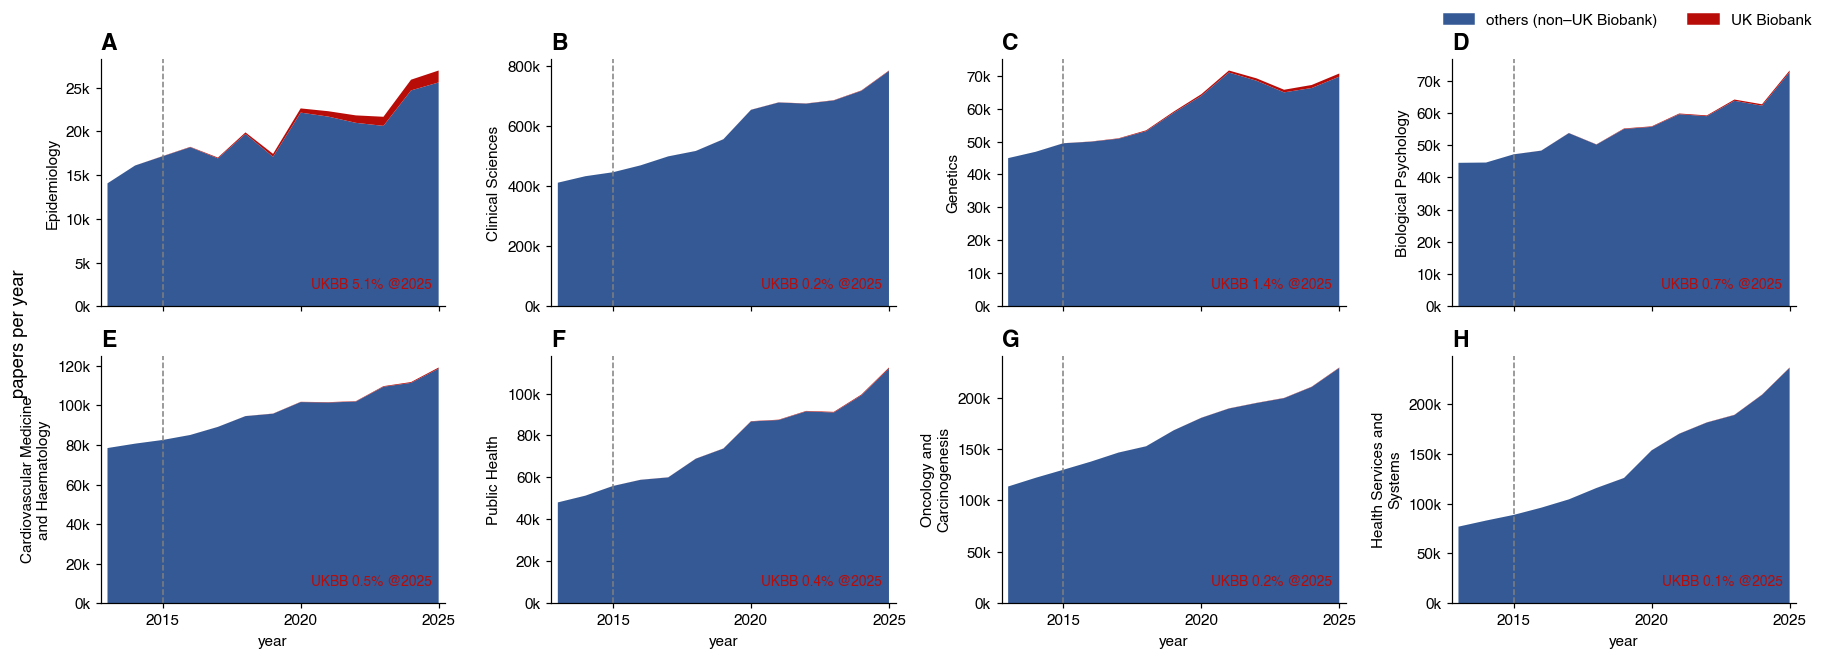

In [5]:
from matplotlib.patches import Patch

C_UKBB = STYLE["colors"][0]     # red  = UK Biobank
C_REST = STYLE["colors"][3]     # blue = everyone else
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")   # 25371 -> "25k"

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    yrs = whole_ts.index.values
    ukb = ukbb_ts[lab].reindex(whole_ts.index).fillna(0.0).values
    rest = whole_ts[lab].values - ukb
    ax.stackplot(yrs, rest, ukb, colors=[C_REST, C_UKBB])
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    set_title(ax, chr(65 + list(axes).index(ax)), fontsize=STYLE["title_fs"])
    facet_ylabel(ax, lab, fontsize=STYLE["annot_fs"] + 1)
    ax.yaxis.set_major_formatter(kfmt)
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.annotate(f"UKBB {pct(share_at(lab))} @{YEAR_MAX}",
                xy=(0.96, 0.06), xycoords="axes fraction", ha="right", va="bottom",
                fontsize=STYLE["annot_fs"], color=C_UKBB)
# One tick set for all the panels (they share an x-axis), anchored on the LAST year so
# the series is not read as ending at whatever the step happened to land on.
axes[0].set_xticks(year_ticks(whole_ts.index.min(), whole_ts.index.max(), 5))
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:      # x-label only on the bottom row that exists
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.legend(handles=[Patch(color=C_REST, label="others (non–UK Biobank)"),
                    Patch(color=C_UKBB, label="UK Biobank")],
           loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
set_figure_title(fig, f"Whole-database publications per year — UK Biobank's top {TOP_N} "
             f"{SYSTEM} {UNIT}s ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("papers per year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"01_whole_db_trends_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

### 4.2 Chart 2 — What UK Biobank adds, in papers and in share

* **Left** — UK Biobank's own output in each field (absolute count).
* **Right** — that output as a **share of the whole database** in the same field.

UK Biobank is a small slice of a vast literature, so the share is the truer measure of its
footprint than the raw count. Fields are direct-labelled on both panels, and colour follows
the field across the whole notebook.

The left panel comes from the UK Biobank arm alone, so it stays readable even when the
background arm has no usable labels and the right panel is stamped out by the guard.

*Saves as* `02_ukbb_contribution_…`


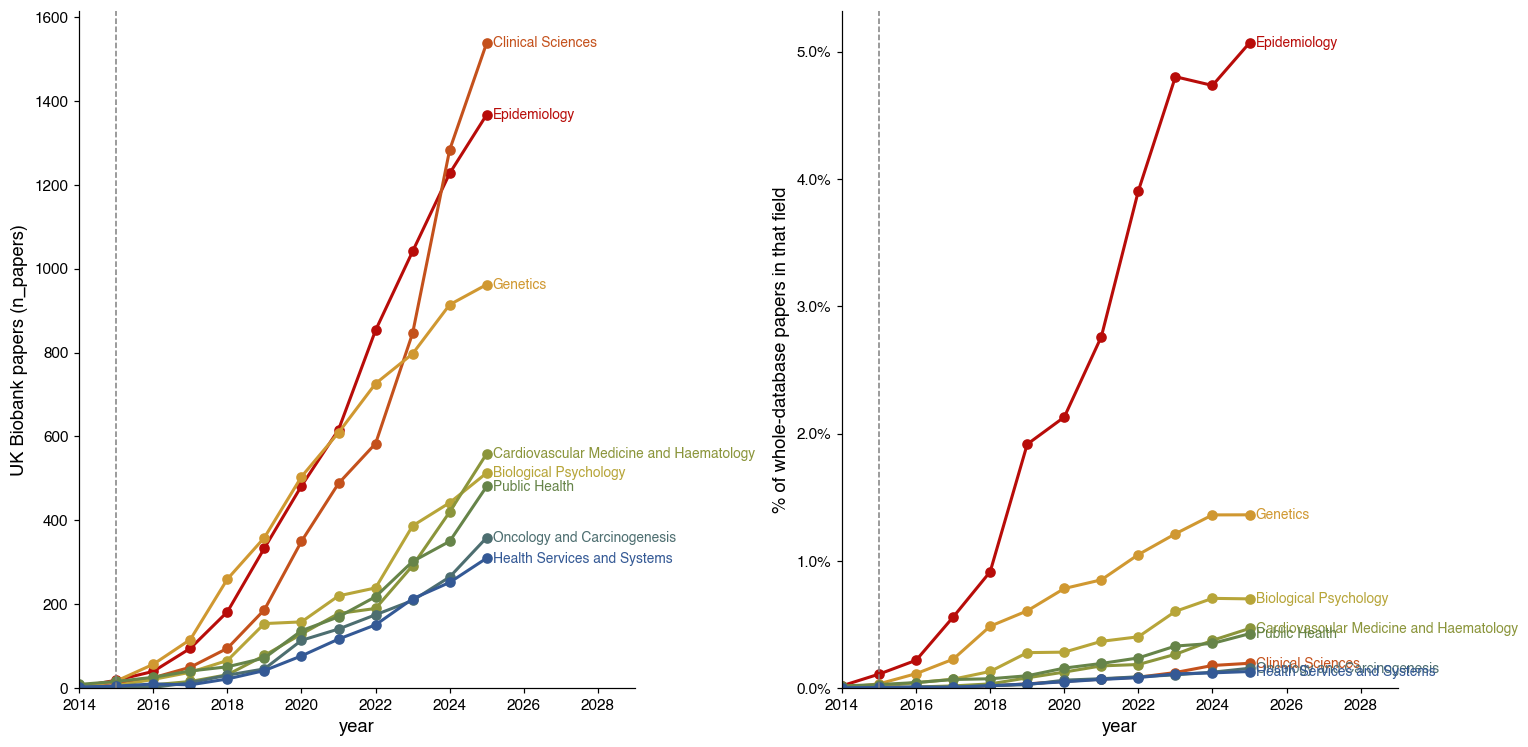

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"])

for lab in TOP_LABELS:
    col = FIELD_COLORS[lab]
    axL.plot(ukbb_ts.index, ukbb_ts[lab], color=col, lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    axR.plot(share_ts.index, share_ts[lab], color=col, lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    yl = ukbb_ts[lab].dropna()
    if len(yl):
        axL.annotate(lab, (yl.index[-1], yl.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")
    yr = share_ts[lab].dropna()
    if len(yr):
        axR.annotate(lab, (yr.index[-1], yr.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")

for ax in (axL, axR):
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_xlabel("year")
    ax.set_ylim(bottom=0)
    ax.set_xlim(UKBB_YEAR - 1, YEAR_MAX + 4)       # room for the direct labels
set_title(axL, f"UK Biobank papers per {UNIT}", loc="left", fontsize=STYLE["title_fs"])
axL.set_ylabel(f"UK Biobank papers ({VALUE})")
set_title(axR, f"UK Biobank share of the {UNIT}{DENOM_NOTE}", loc="left",
              fontsize=STYLE["title_fs"])
axR.set_ylabel(f"% of whole-database papers in that {UNIT}")
# Pick the tick precision from the data: RCDC shares sit below 2%, and a 0-decimal
# formatter would render every tick as "0%" or "1%".
_smax = float(np.nanmax(share_ts.values)) if share_ts.notna().any().any() else 1.0
_nd = 0 if _smax >= 10 else (1 if _smax >= 1 else 2)
axR.yaxis.set_major_formatter(mticker.StrMethodFormatter(f"{{x:.{_nd}f}}%"))
#flag_denominator(axR)
set_figure_title(fig, f"{SYSTEM} ({LEVEL}{VIEW_NOTE})", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"02_ukbb_contribution_{COL_TYPE}_{LEVEL}{FILE_TAG}_{WEIGHT}")
plt.show()

### 4.3 Marginal annual increase within the study window *(table)*

**Marginal speed** = the slope (papers **added** per year) of a straight-line fit to the
yearly counts over 2013–2025 (`AFTER_WIN`). It is fitted on the **whole database**
and, for context, on UK Biobank's own output. `BEFORE_WIN` is unavailable: pre-2013
publications are excluded, so before-window and acceleration columns remain missing.

> **Caution.** UK Biobank is far too small — a fraction of a percent of any field — to bend
> the whole-database slope, so any acceleration in the `whole_*` columns is a **database-wide
> trend, not something UK Biobank caused**. The `ukbb_after` column is UK Biobank's own pace.
> `whole_*` comes back `<NA>` where the masking guard left that window empty.

**Read `activity_x` before `ukbb_share_%`.** The share answers "how much of this field is UK
Biobank?" and is bounded by UK Biobank's size, so it is small everywhere by construction. The
activity index answers "how much **more** of UK Biobank's work is in this field than the
literature's?" — 1.0 is parity, 3.0 is triple concentration — and that is the question a
funder is actually asking.


In [7]:
print("Pre-2013 comparison unavailable: those years are outside the study window.")
def slope(frame, code, win, value=VALUE):
    if win is None:
        return np.nan
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        UNIT: lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_at(lab),
        "activity_x": float(ACTIVITY.get(code, np.nan)),
    })

speed = pd.DataFrame(rows).set_index(UNIT)
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt["activity_x"] = speed_fmt["activity_x"].round(2)
speed_fmt

Pre-2013 comparison unavailable: those years are outside the study window.


,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2025_%,activity_x
field,,,,,,
Epidemiology,<NA>,932,NaN,145,5.07,12.00
Clinical Sciences,<NA>,33605,NaN,148,0.20,0.86
Genetics,<NA>,2388,NaN,103,1.36,6.20
Biological Psychology,<NA>,2193,NaN,52,0.70,2.42
Cardiovascular Medicine and Haematology,<NA>,3388,NaN,52,0.47,1.84
Public Health,<NA>,5435,NaN,44,0.43,0.93
Oncology and Carcinogenesis,<NA>,9591,NaN,35,0.16,0.74
Health Services and Systems,<NA>,14773,NaN,31,0.13,0.32


### 4.4 Chart 3 — Growth speed of each field, year by year

**Speed** = the annual increase: how many more papers a field gained than the year before
(the first difference of Chart 1's whole-database curve). It is plotted **across** years, per
field, rather than collapsed into a single before/after number (§4.3), so the change in pace
is shown descriptively rather than as a story about a cause.

The dashed line at `UKBB_YEAR` is **only a time reference**: a rise to its right is a
database-wide trend, and UK Biobank — single-digit percent of any field at most — is far too
small to have bent these curves.

*Saves as* `03_growth_speed_…`


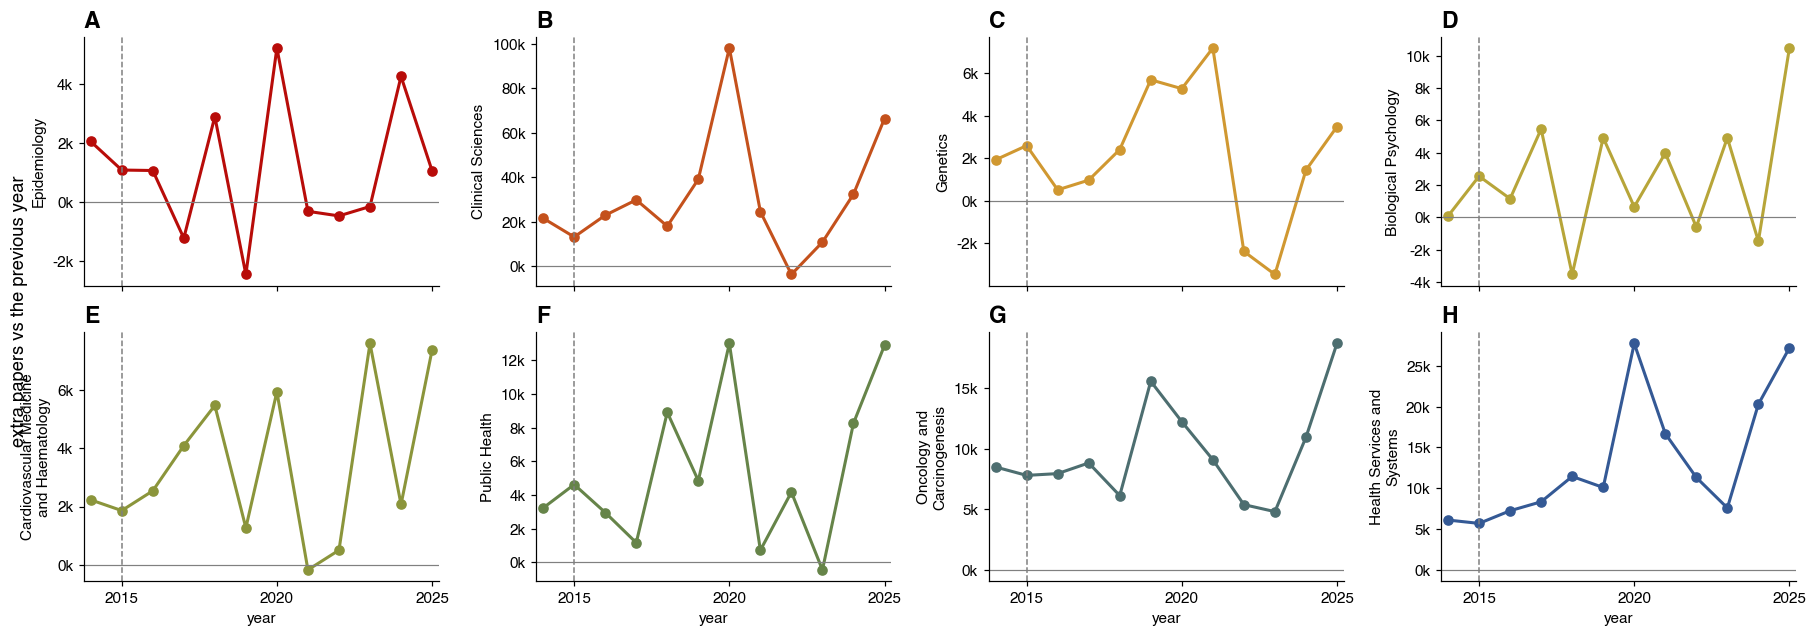

In [8]:
speed_ts = whole_ts.diff()      # papers gained vs the previous year
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    s = speed_ts[lab].dropna()
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    ax.axhline(0, color=STYLE["edgecolor"], lw=0.8)
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    set_title(ax, chr(65 + list(axes).index(ax)), fontsize=STYLE["title_fs"])
    facet_ylabel(ax, lab, fontsize=STYLE["annot_fs"] + 1)
    ax.yaxis.set_major_formatter(kfmt)
    ax.margins(x=0.02)
# One tick set for all the panels (they share an x-axis), anchored on the LAST year so
# the series is not read as ending at whatever the step happened to land on.
axes[0].set_xticks(year_ticks(speed_ts.dropna(how='all').index.min(), speed_ts.dropna(how='all').index.max(), 5))
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

set_figure_title(fig, f"Annual growth speed per year — UK Biobank's top {TOP_N} {SYSTEM} "
             f"{UNIT}s ({LEVEL}{VIEW_NOTE}, whole database){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("extra papers vs the previous year", fontsize=STYLE["label_fs"])
flag_denominator(fig)
fig.tight_layout()
savefig(fig, f"03_growth_speed_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

### 4.5 Chart 4 — The activity index: what UK Biobank is disproportionately about

Chart 2's share is bounded by UK Biobank's size, so every field looks tiny there and the
ranking mostly reproduces "which fields are big". The activity index divides that size out:

$$\text{AI}(X)=\frac{\text{UK Biobank's papers in }X\ /\ \text{all UK Biobank papers}}
{\text{database's papers in }X\ /\ \text{all database papers}}$$

**1.0** = UK Biobank works on *X* exactly as much as the literature does, **3.0** = three
times as concentrated, **0.3** = a third. It is a *ratio of shares*, so it is computed on
`n_frac` whatever `WEIGHT` says — the same convention as `ACTIVITY` in the §3 build cell —
and it is measured against whatever `ACTIVITY_BASE` sets (see §2: `within_parent` is the one
that removes "UK Biobank is a biomedical resource" from the comparison).

* **Left** — UK Biobank's biggest fields against parity. Log axis, so 2× and 0.5× sit the
  same distance from the 1.0 line; dot area = UK Biobank papers, so a large dot far to the
  right is both a big and a distinctive body of work.
* **Right** — the same index year by year: is the concentration deepening or fading?
  Field-years carrying fewer than `ACT_MIN_N` UK Biobank papers are dropped — a ratio of
  shares built on a handful of papers is noise, which is most of what 2015 and 2016
  contain even inside the window (63 and 160 UK Biobank papers across 103 fields).

In the historical 2015–2025 calibration, using `within_parent`, Epidemiology read **12.0×** its own division and
**61.4×** against all research — the gap between those two numbers is the whole reason
§2 defaults to `within_parent`.

*Saves as* `04_activity_index_…`


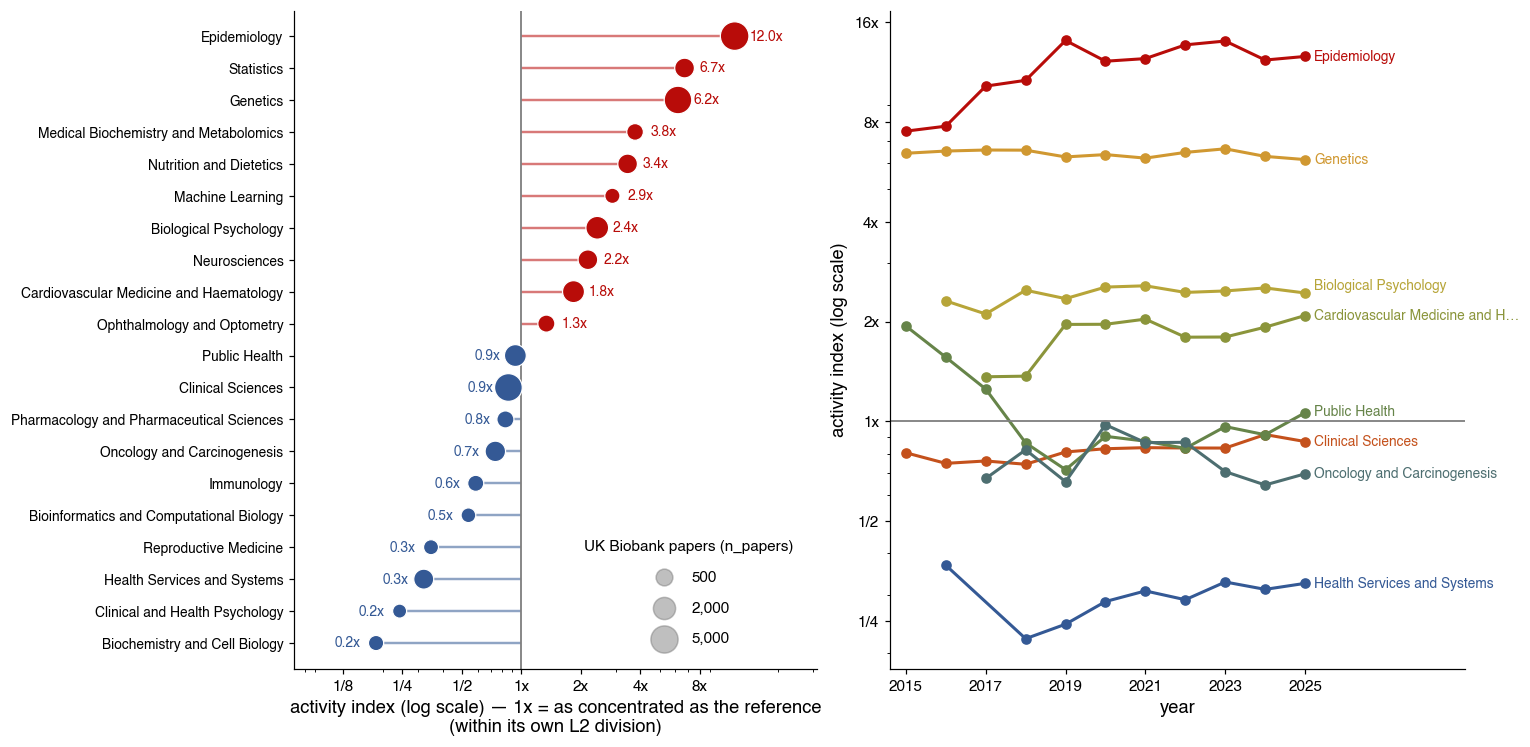

activity index over 2015-2025, UK Biobank's top 20 fields (>1 = over-represented vs the whole database):

  Epidemiology                                          12.00x     6,256 papers
  Statistics                                             6.69x     1,136 papers
  Genetics                                               6.20x     5,321 papers
  Medical Biochemistry and Metabolomics                  3.76x       483 papers
  Nutrition and Dietetics                                3.45x     1,112 papers
  Machine Learning                                       2.89x       292 papers
  Biological Psychology                                  2.42x     2,244 papers
  Neurosciences                                          2.17x     1,114 papers
  Cardiovascular Medicine and Haematology                1.84x     1,904 papers
  Ophthalmology and Optometry                            1.34x       550 papers
  Public Health                                          0.93x     1,864 papers
  Clinical Sci

In [9]:
ACT_TOP_M = 20      # how many of UK Biobank's biggest categories to rank (left)
ACT_MIN_N = 10      # min UK Biobank papers in a category-year to plot it (right)

C_ABOVE, C_BELOW = STYLE["colors"][0], STYLE["colors"][3]   # red over, blue under

# -- left panel data: UK Biobank's ACT_TOP_M biggest categories, ranked by index ----
_rank_m = (ukbb[ukbb.year >= UKBB_YEAR].groupby(["code", "for_label"])[VALUE].sum()
           .sort_values(ascending=False).head(ACT_TOP_M))
act_tbl = (pd.DataFrame({"label": [lab for _, lab in _rank_m.index],
                         "ukbb": _rank_m.to_numpy(),
                         "activity": [ACTIVITY.get(c, np.nan) for c, _ in _rank_m.index]})
           .dropna(subset=["activity"]).sort_values("activity").reset_index(drop=True))

# -- right panel data: the index recomputed within each year ------------------------
# Both arms are re-shared within each year, so a year in which the whole database grew
# does not move the index; only a change in its COMPOSITION does.
# It goes through activity_index() rather than re-deriving the shares here, because the
# BASE has to be ACTIVITY_BASE — the one the left panel, the axis label and every
# printed number already use. Re-sharing over all codes inline is the global index, and
# under ACTIVITY_BASE="within_parent" that is a different number entirely: Epidemiology
# is 12.0x within its own division and 61.4x against all research, so the two panels
# would disagree by a factor of five under one shared title.
# activity_index() follows FRAC_COL by itself, so the fallback to whole counting when
# the partials carry no fractional column (the API pathway) still holds here.
act_ts = pd.DataFrame({y: activity_index((y, y))
                       for y in sorted(whole.year.unique())}).T.sort_index()
_u_year = ukbb.pivot_table(index="year", columns="code", values=FRAC_COL, aggfunc="sum")
act_ts = act_ts.where(_u_year.reindex(index=act_ts.index, columns=act_ts.columns)
                      >= ACT_MIN_N)
act_ts = act_ts.reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.1]})

# ---- left: ranked lollipop against parity ----------------------------------------
ypos = np.arange(len(act_tbl))
colors = [C_ABOVE if a >= 1 else C_BELOW for a in act_tbl.activity]
sizes = 30 + 320 * np.sqrt(act_tbl.ukbb / act_tbl.ukbb.max())
axL.hlines(ypos, 1.0, act_tbl.activity, color=colors, lw=1.6, alpha=0.55)
axL.scatter(act_tbl.activity, ypos, s=sizes, color=colors, zorder=3,
            edgecolor="white", linewidth=0.8)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
for y, a in zip(ypos, act_tbl.activity):
    left = a < 1.0
    axL.annotate(f"{a:.1f}x", (a, y), fontsize=STYLE["annot_fs"],
                 color=C_BELOW if left else C_ABOVE, va="center",
                 ha="right" if left else "left",
                 xytext=(-10 if left else 10, 0), textcoords="offset points")
axL.set_xscale("log")
axL.set_xticks([0.125, 0.25, 0.5, 1, 2, 4, 8])
axL.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:g}x" if x >= 1 else f"1/{1 / x:g}"))
axL.xaxis.set_minor_formatter(mticker.NullFormatter())
axL.set_xlim(act_tbl.activity.min() / 2.6, act_tbl.activity.max() * 2.6)
axL.set_yticks(ypos)
axL.set_yticklabels([short(lab) for lab in act_tbl.label], fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.8, len(act_tbl) - 0.2)
axL.set_xlabel(f"activity index (log scale) — 1x = as concentrated as the reference\n({ACTIVITY_LABEL})")
set_title(axL, f"UK Biobank's {len(act_tbl)} biggest {UNIT}s", loc="left",
              fontsize=STYLE["title_fs"])

# Dot area is a second encoding on this panel, so it needs its own key.
_legend_n = [n for n in (500, 2000, 5000) if n <= act_tbl.ukbb.max()]
axL.legend(handles=[plt.scatter([], [], s=30 + 320 * np.sqrt(n / act_tbl.ukbb.max()),
                                color=STYLE["edgecolor"], alpha=0.5,
                                label=f"{n:,}") for n in _legend_n],
           title=f"UK Biobank papers ({VALUE})", loc="lower right", frameon=False,
           labelspacing=1.1, borderpad=1.0, fontsize=STYLE["legend_fs"],
           title_fontsize=STYLE["legend_fs"])

# ---- right: the index year by year ------------------------------------------------
ends = []                       # (final value, final year, label) for the direct labels
for lab in TOP_LABELS:
    s = act_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)

# Direct labels rather than a legend box, but several series finish within a few
# percent of each other; nudge them apart in log space so none is unreadable.
_lo = min(v for v, _, _ in ends) if ends else 0.5
_hi = max(v for v, _, _ in ends) if ends else 2.0
_gap = 0.045 * (np.log10(_hi / _lo) + 0.4)
_prev = None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Log majors are decades and the whole index lives inside one decade — put the ticks
# on the doublings instead, so the reader can tell 2x from 4x.
_ticks = [t for t in (0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32) if _lo / 1.6 <= t <= _hi * 1.6]
axR.set_yticks(_ticks)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda y, _: f"{y:g}x" if y >= 1 else f"1/{1 / y:g}"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_years = act_ts.dropna(how="all").index
_y0 = int(_years.min()) if len(_years) else UKBB_YEAR
axR.set_xlim(_y0 - 0.4, YEAR_MAX + 4)        # room for the direct labels
axR.set_xticks(year_ticks(_y0, YEAR_MAX, 2))
axR.set_xlabel("year")
axR.set_ylabel("activity index (log scale)")
set_title(axR, f"…and how it moved (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])
flag_denominator(axR)

set_figure_title(fig, f"Activity index — {SYSTEM} ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"04_activity_index_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

print(f"activity index over {AFTER_WIN[0]}-{AFTER_WIN[1]}, UK Biobank's top "
      f"{len(act_tbl)} {UNIT}s (>1 = over-represented vs the whole database):\n")
for _, r in act_tbl.iloc[::-1].iterrows():
    print(f"  {short(r.label, 52):52s} {r.activity:6.2f}x   {int(r.ukbb):>7,} papers")


## 5. Citation impact — how well that work lands

Volume answered "how much"; this part asks whether UK Biobank's papers are cited more than
the world's papers in the same field and year. Four citation weights are carried through
side by side on this run, because a result that only holds under one of them is a property of the
measure rather than of UK Biobank:

| weight | what it is | what it rewards |
|---|---|---|
| `n_cit` | raw `times_cited` | citation mass — accrues with age, and with citation-heavy fields. **Shares and means only:** it is not year-normalised, so it never becomes an `rci_` ratio (see below) |
| `n_mncs` | `times_cited` ÷ the mean of its own (year, field) | 1.0 = the field's average paper that year. The headline on this run |
| `n_top10f` | top-decile indicator, **per field** | 1.0 if the paper is in the most-cited tenth of its own (year, field), against a cut-off measured by counting |
| `n_top50f` | above-median indicator, per field | 1.0 if it is at or above that (year, field)'s median |
| `n_fcr` | `field_citation_ratio` | field- **and** year-normalised; 1.0 = world average. VM pathway only |
| `n_top10` | top-decile indicator, whole corpus | VM pathway's decile: the most-cited tenth of the (year, type), not of the field |

**Why `n_cit` gets no ratio.** `rci_<w>` pools the whole impact window before taking the two
means, and the arms are not spread over that window alike: UK Biobank's output is still
ramping: in the historical 2015–2025 calibration, **64–78%** of its papers in its top fields are from the last four
years (2022–2025), against **40–49%** of the world's. A weight that accrues with age therefore
meets a far younger population in the numerator than in the denominator, and the ratio comes
out too low — pooled **1.48** against a year-controlled **1.73** for Epidemiology, and
**1.54** against **2.13** for Biological Psychology. Every weight that *does* carry a ratio is normalised
against its own publication year **before** it is aggregated, so the composition cancels.
`n_cit` stays available as a *share* (Chart 7), where numerator and denominator are the same
set of papers and the problem does not arise.

`CITE_HEADLINE` (§2) picks the one the headline panels lead with; `CITE_MIN_DOCS` /
`CITE_MIN_DOCS_YEAR` set how thin a field-window may be before its mean is treated as noise,
and the usable citation window is derived from coverage in §3. §5.1 builds the table, §§5.2–5.4
draw it.


### 5.1 The citation-weighted table — `IMPACT`

`IMPACT` (built in the §3 load cell) carries, per field, over the impact window:

* **`rci_<w>` — relative citation impact.** The mean weight of UK Biobank's papers in *X*
  over the mean weight of the whole database's papers in *X*. **1.0 = cited exactly like
  everyone else's work in the same field.** It is a *mean* over the papers that carried a
  value, which is what lets it survive the two arms being measured to different depths (on
  the VM pathway FCR reaches 97% of the UK Biobank arm and 73% of the background; on this
  one every weight is measured in ~100% of both). Only the weights in `RCI_WEIGHTS` get
  one — `n_cit` does not, for the reason in §5.
* **`act_<w>` — citation activity index.** Chart 4's activity index with citation mass in
  place of paper counts; folds volume and impact together.
* **`activity_x`** — the volume activity index recomputed on the impact window, so all the
  columns describe the same years.

**The pooled figure comes first, deliberately.** Without it a field's 2.5× reads as
remarkable when the whole corpus sits at 2.4× and the field is merely average *for UK
Biobank*.


In [10]:
if not CITE_OK:
    print("no usable citation window — the impact section is skipped")
else:
    _u = ukbb[ukbb.year.between(*CITE_WIN)]
    _w = whole[whole.year.between(*CITE_WIN)]
    # FRAC_SFX is "_frac" on the VM pathway and "" on the API one, where there are no
    # fractional columns to take a mean over — same measure either way.
    _mean = lambda f, wt: f[f"{wt}{FRAC_SFX}"].sum() / f[f"{wt}_docs{FRAC_SFX}"].sum()
    print(f"UK Biobank overall, {CITE_WIN[0]}-{CITE_WIN[1]}, against the whole database"
          f" ({UNIT}-tagged papers):")
    # Every weight gets its two means printed; only the year-normalised ones get the
    # ratio beside them. n_cit's means are worth seeing — they are the arithmetic
    # everything else is built on — but their quotient would compare UK Biobank's
    # recent papers with the world's older ones, so it is withheld rather than shown
    # with a caveat nobody reads. RCI_WEIGHTS is the list that may be divided.
    for wt in WEIGHTS_PRESENT:
        label = {"n_cit": "citations per paper", "n_fcr": "field citation ratio",
                 "n_top10": "share in the top decile",
                 "n_top10f": "share in the field's top decile",
                 "n_top50f": "share above the field median",
                 "n_mncs": "citations vs the field average"}.get(wt, wt)
        fmt = "{:.1%}" if wt.startswith("n_top") else "{:.2f}"
        ratio = (f"= {OVERALL[wt[2:]]:.2f}x" if wt in RCI_WEIGHTS
                 else "(no ratio — not year-normalised)")
        print(f"  {label:31s} UKBB {fmt.format(_mean(_u, wt)):>7s}   whole "
              f"{fmt.format(_mean(_w, wt)):>7s}   {ratio}")

    _head = CITE_HEADLINE[2:]
    cols = (["ukbb_papers", "activity_x"] + [f"rci_{w[2:]}" for w in RCI_WEIGHTS]
            + [f"act_{_head}"])
    impact_fmt = (IMPACT.loc[TOP_CODES, cols]
                  .rename(index=dict(zip(TOP_CODES, TOP_LABELS))).round(2))
    impact_fmt["ukbb_papers"] = impact_fmt.ukbb_papers.round(0).astype("Int64")
    impact_fmt.index.name = UNIT
    print(f"\nUK Biobank's top {TOP_N} {UNIT}s — volume beside impact "
          f"({CITE_WIN[0]}-{CITE_WIN[1]}, {'fractional' if FRAC_OK else 'whole'} counts):")
    display(impact_fmt)


UK Biobank overall, 2015-2025, against the whole database (field-tagged papers):
  citations per paper             UKBB   28.64   whole   12.86   (no ratio — not year-normalised)
  share in the field's top decile UKBB   24.5%   whole    9.6%   = 2.55x
  share above the field median    UKBB   61.5%   whole   46.5%   = 1.32x
  citations vs the field average  UKBB    2.50   whole    1.00   = 2.50x

UK Biobank's top 8 fields — volume beside impact (2015-2025, whole counts):


,ukbb_papers,activity_x,rci_top10f,rci_top50f,rci_mncs,act_mncs
field,,,,,,
Epidemiology,6256,12.00,1.96,1.13,1.80,44.03
Clinical Sciences,5458,0.86,3.12,1.48,2.83,2.09
Genetics,5321,6.20,2.48,1.20,2.72,19.50
Biological Psychology,2244,2.42,2.06,1.10,2.12,6.85
Cardiovascular Medicine and Haematology,1904,1.84,4.30,1.68,4.29,6.76
Public Health,1864,0.93,3.23,1.45,3.11,5.92
Oncology and Carcinogenesis,1359,0.74,1.95,1.37,1.62,1.03
Health Services and Systems,1207,0.32,3.08,1.39,3.04,1.99


### 5.2 Chart 5 — Impact map: how much UK Biobank publishes vs how well it lands

The two questions are independent, so they get an axis each.

* **Horizontal** — Chart 4's volume activity index: is UK Biobank over- or under-represented
  in this field?
* **Vertical** — the relative citation impact: are its papers there cited more than the
  world's papers there?

Both are ratios against the whole database and both are drawn on log scales, so "twice" and
"half" sit the same distance from the parity lines.

**The horizontal reference is UK Biobank's own average impact, not 1.0.** Against the world,
essentially every field is above parity — a resource whose papers average 2.4× world is not
told apart by that line. What a portfolio owner needs to know is which fields beat **UK
Biobank's own** standard, so that is the line drawn solid; world parity is the dotted one
below it.

*Saves as* `05_impact_map_…`


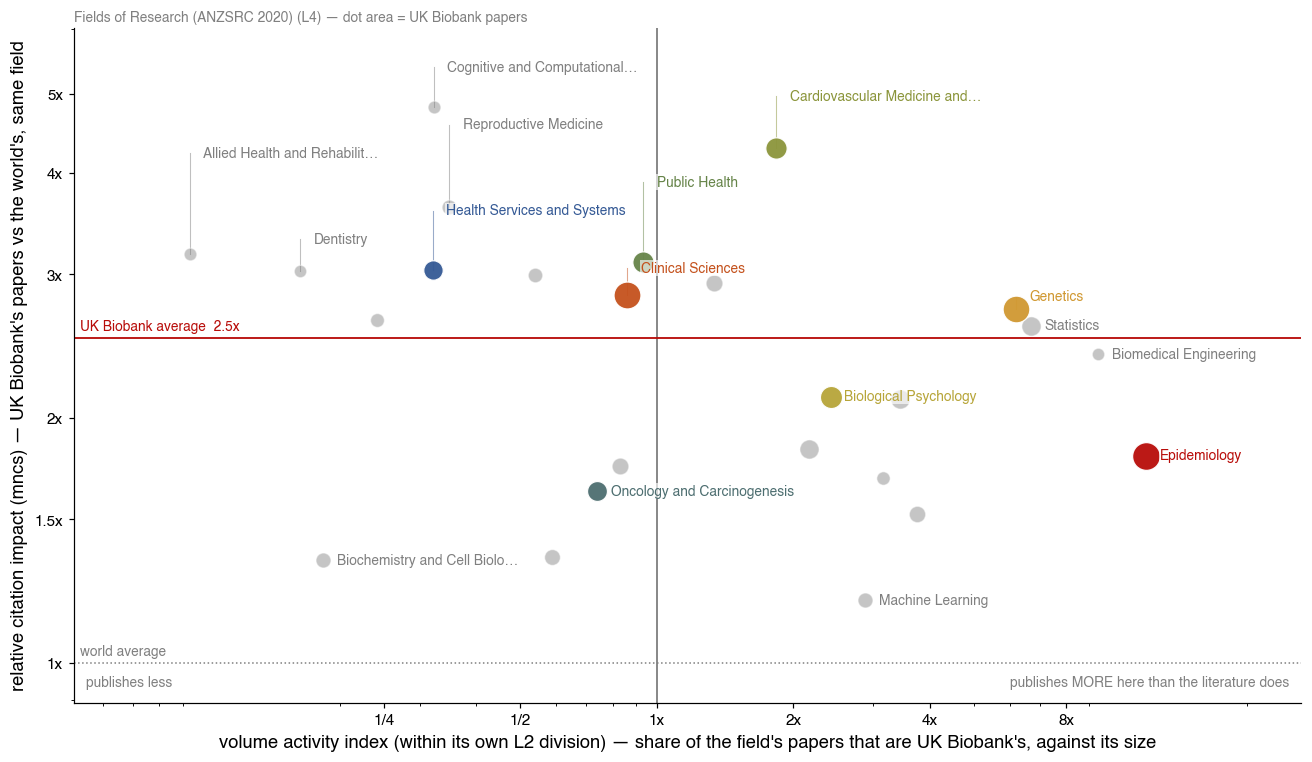

In [11]:
CHART5_M = 25          # categories to plot, UK Biobank's biggest first
_head = CITE_HEADLINE[2:]
_rci = f"rci_{_head}"

_big = (IMPACT.dropna(subset=[_rci, "activity_x"])
        .nlargest(CHART5_M, "ukbb_papers"))
_labels = {c: l for c, l in zip(TOP_CODES, TOP_LABELS)}
_ref = OVERALL[_head]

fig, ax = plt.subplots(figsize=STYLE["figsize"])
for code, r in _big.iterrows():
    top = code in _labels
    col = FIELD_COLORS[_labels[code]] if top else STYLE["edgecolor"]
    ax.scatter(r.activity_x, r[_rci], s=30 + 300 * np.sqrt(r.ukbb_papers / _big.ukbb_papers.max()),
               color=col, alpha=0.95 if top else 0.45, zorder=3 if top else 2,
               edgecolor="white", linewidth=0.8)

# Label the top-N (colour-matched to every other chart) plus whatever is extreme on
# either axis — those are the points a reader will ask about. The dementia family sits
# in one tight cluster, so labels are nudged apart in log space as in Chart 4.
_extreme = set(_big.nlargest(3, _rci).index) | set(_big.nsmallest(2, _rci).index) \
    | set(_big.nlargest(3, "activity_x").index) | set(_big.nsmallest(2, "activity_x").index)
_to_label = [(r[_rci], r.activity_x, code) for code, r in _big.iterrows()
             if code in _labels or code in _extreme]
_span = np.log10(_big[_rci].max() / _big[_rci].min())
_gap, _prev = 0.035 * (_span + 0.4), None
for value, xpos, code in sorted(_to_label):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    lab = label_of(code)
    col = FIELD_COLORS[lab] if code in _labels else STYLE["edgecolor"]
    # A nudged label must still point at its own dot, or the reader attaches it to a
    # neighbour; anything moved more than a hair gets a leader line.
    if abs(ly - np.log10(value)) > 0.008:
        ax.plot([xpos, xpos], [value, 10 ** ly], color=col, lw=0.7, alpha=0.5,
                zorder=1)
    ax.annotate(short(lab, 28), (xpos, 10 ** ly), color=col,
                fontsize=STYLE["annot_fs"], va="center",
                xytext=(9, 0), textcoords="offset points",
                bbox=dict(fc="white", ec="none", alpha=0.65, pad=0.6))

# World parity is drawn only when the data comes near it. Every disease UK Biobank
# works in is cited above world average, so forcing 1.0 onto the axis would spend half
# the panel on empty space; when it is off-scale the corner note says so instead.
SHOW_WORLD = _big[_rci].min() < 1.3
ax.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
ax.axhline(_ref, color=STYLE["colors"][0], lw=1.2)
if SHOW_WORLD:
    ax.axhline(1.0, color=STYLE["edgecolor"], lw=1, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
for axis, ticks in ((ax.xaxis, [0.25, 0.5, 1, 2, 4, 8]),
                    (ax.yaxis, [1, 1.5, 2, 3, 4, 5])):
    axis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{v:g}x" if v >= 1 else f"1/{1 / v:g}"))
    axis.set_minor_formatter(mticker.NullFormatter())
ax.set_xticks([0.25, 0.5, 1, 2, 4, 8])
ax.set_yticks([1, 1.5, 2, 3, 4, 5])
ax.set_xlim(_big.activity_x.min() / 1.8, _big.activity_x.max() * 2.2)
ax.set_ylim((1.0 if SHOW_WORLD else _big[_rci].min()) / 1.12,
            _big[_rci].max() * 1.25)

ax.annotate(f"UK Biobank average  {_ref:.1f}x", (ax.get_xlim()[0], _ref),
            color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
            xytext=(4, 3), textcoords="offset points")
if SHOW_WORLD:
    ax.annotate("world average", (ax.get_xlim()[0], 1.0), color=STYLE["edgecolor"],
                fontsize=STYLE["annot_fs"], va="bottom", xytext=(4, 3),
                textcoords="offset points")
else:
    ax.annotate(f"world average (1x) is below this axis — every {UNIT} shown is "
                f"cited above it", (0.01, 0.08), xycoords="axes fraction", ha="left",
                fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
# Name the halves rather than all four quadrants: with the reference line at UK
# Biobank's own average, "left" and "right" of it is the whole message.
ax.annotate("publishes MORE here than the literature does", (0.99, 0.02),
            xycoords="axes fraction", ha="right", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
ax.annotate("publishes less", (0.01, 0.02), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=STYLE["annot_fs"],
            color=STYLE["edgecolor"])

ax.set_xlabel(f"volume activity index ({ACTIVITY_LABEL}) — share of the {UNIT}'s "
              f"papers that are UK Biobank's, against its size")
ax.set_ylabel(f"relative citation impact ({_head}) — UK Biobank's papers vs the "
              f"world's, same {UNIT}")
set_title(ax, f"Where UK Biobank concentrates, and where that work lands "
             f"({CITE_WIN[0]}-{CITE_WIN[1]})", loc="left", fontsize=STYLE["title_fs"],
             pad=18)
# Subtitle as an axes annotation, not a suptitle: a suptitle on a single-panel figure
# collides with the y-label once the ticks are this wide.
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — dot area = UK Biobank papers",
            (0, 1.005), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"05_impact_map_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()


### 5.3 Chart 6 — Do the measures agree, and is the impact holding up?

* **Left — agreement.** The same fields under every weight that carries a ratio
  (`RCI_WEIGHTS`). Citation analysis lives or dies on whether a result survives the choice of
  measure: `mncs` divides out the field-year average but is a mean of ratios and so follows
  the biggest hits, while a top-decile rate ignores how big those hits are entirely. Where the
  markers sit together the result is **robust**; where they spread, the ranking is an
  **artefact of the measure** and should be reported as such. The dashed line of each colour
  is UK Biobank's *own* average on that measure — the reference a field should be judged
  against.
* **The spread statistic excludes `n_top50f`.** An above-median rate cannot exceed **2×** by
  construction (the world's rate is 50%), where a decile rate can reach 10× and `mncs` has no
  ceiling at all. Including it would put a floor under every field's "disagreement" that is
  arithmetic rather than evidence. It is still drawn — it just does not vote on whether the
  measures agree.
* **Right — over time.** The headline measure year by year. Impact ratios are noisier than
  volume shares (a field-year needs enough UK Biobank papers to have a mean at all), so thin
  cells are dropped rather than drawn as spikes.

*Saves as* `06_citation_impact_…`


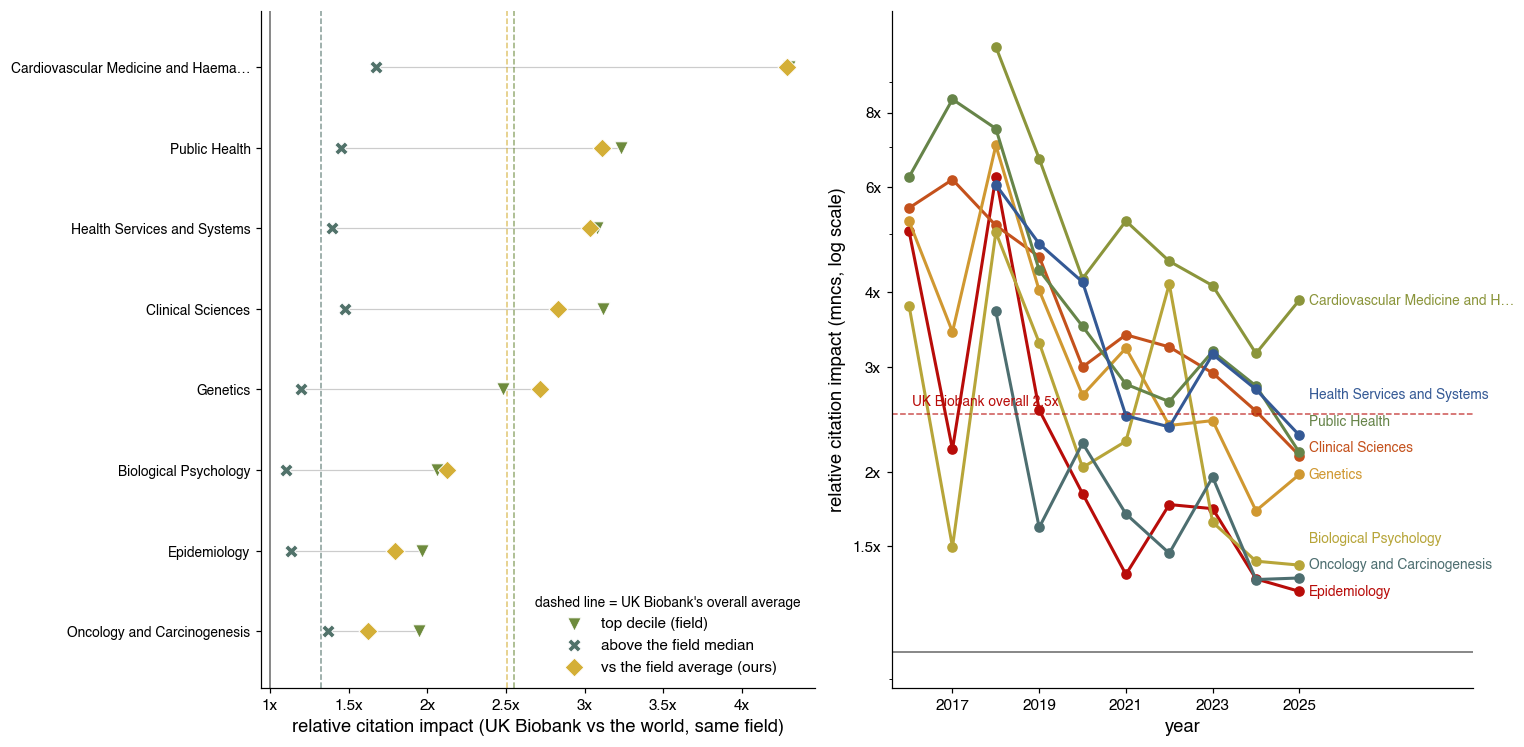

measure agreement over UK Biobank's top 8 fields (spread = max/min over top10f, mncs; top50f is shown but excluded — its ceiling is 2x by construction):
  Cardiovascular Medicine and Haema… top10f  4.3x  top50f  1.7x    mncs  4.3x   spread 1.00x
  Public Health                      top10f  3.2x  top50f  1.5x    mncs  3.1x   spread 1.04x
  Health Services and Systems        top10f  3.1x  top50f  1.4x    mncs  3.0x   spread 1.01x
  Clinical Sciences                  top10f  3.1x  top50f  1.5x    mncs  2.8x   spread 1.10x
  Genetics                           top10f  2.5x  top50f  1.2x    mncs  2.7x   spread 1.09x
  Biological Psychology              top10f  2.1x  top50f  1.1x    mncs  2.1x   spread 1.03x
  Epidemiology                       top10f  2.0x  top50f  1.1x    mncs  1.8x   spread 1.09x
  Oncology and Carcinogenesis        top10f  1.9x  top50f  1.4x    mncs  1.6x   spread 1.20x


In [12]:
CHART6_MIN_DOCS = CITE_MIN_DOCS_YEAR    # set in the parameter block

_head = CITE_HEADLINE[2:]
_order = (IMPACT.loc[[c for c in TOP_CODES if pd.notna(IMPACT.loc[c, f"rci_{_head}"])]]
          .sort_values(f"rci_{_head}"))
# Colour follows the MEASURE here, not the category, and it has to stay put whichever
# measures a given run happens to have — so the palette is assigned over the full known
# list and then filtered, rather than over whatever turned up today.
_W_ORDER = ["n_cit", "n_fcr", "n_mncs", "n_top10", "n_top10f", "n_top50f", "n_recent"]
_W_PAL = dict(zip(_W_ORDER, extended_palette(len(_W_ORDER))))
W_COLORS = {w: _W_PAL.get(w, STYLE["edgecolor"]) for w in RCI_WEIGHTS}
W_MARKERS = {"n_cit": "s", "n_fcr": "o", "n_mncs": "D", "n_top10": "^",
             "n_top10f": "v", "n_top50f": "X", "n_recent": "P"}
W_NAMES = {"n_cit": "raw citations", "n_fcr": "field-normalised (FCR)",
           "n_mncs": "vs the field average (ours)", "n_top10": "top decile (corpus)",
           "n_top10f": "top decile (field)", "n_top50f": "above the field median",
           "n_recent": "recent citations"}

# The measures that vote on whether the ranking is robust. n_top50f is drawn but left out
# of the spread: its ceiling is 2x by construction (the world is at 50% by definition), so
# it would widen every row's max/min for an arithmetic reason rather than a substantive one.
SPREAD_W = [w for w in RCI_WEIGHTS if w != "n_top50f"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"],
                               gridspec_kw={"width_ratios": [1, 1.05]})

# ---- left: every ratio-carrying measure, side by side -----------------------------
ypos = np.arange(len(_order))
for wt in RCI_WEIGHTS:
    vals = _order[f"rci_{wt[2:]}"]
    axL.scatter(vals, ypos, s=STYLE["dot_marker_area"], color=W_COLORS[wt], marker=W_MARKERS.get(wt, "o"),
                label=W_NAMES.get(wt, wt), zorder=3, edgecolor="white", linewidth=0.6)
    axL.axvline(OVERALL[wt[2:]], color=W_COLORS[wt], lw=1, ls="--", alpha=0.7)
# A hairline joining the measures makes the spread readable as one object per row.
for y, (_, r) in zip(ypos, _order.iterrows()):
    vals = [r[f"rci_{w[2:]}"] for w in RCI_WEIGHTS]
    axL.plot([min(vals), max(vals)], [y, y], color=STYLE["edgecolor"], lw=0.8,
             alpha=0.4, zorder=1)
axL.axvline(1.0, color=STYLE["edgecolor"], lw=1.2)
axL.set_yticks(ypos)
axL.set_yticklabels([short(label_of(c), 34) for c in _order.index],
                    fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.7, len(_order) - 0.3)
axL.set_xlabel("relative citation impact (UK Biobank vs the world, same "
               f"{UNIT})")
axL.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
set_title(axL, f"{len(RCI_WEIGHTS)} measures, same {UNIT}s", loc="left",
              fontsize=STYLE["title_fs"])
axL.legend(loc="lower right", frameon=False, fontsize=STYLE["legend_fs"],
           title="dashed line = UK Biobank's overall average",
           title_fontsize=STYLE["annot_fs"])

# ---- right: the headline measure, year by year -----------------------------------
rci_ts = (rci_timeseries(CITE_HEADLINE, CHART6_MIN_DOCS)
          .reindex(columns=TOP_CODES).set_axis(TOP_LABELS, axis=1))

ends = []
for lab in TOP_LABELS:
    s = rci_ts[lab].dropna()
    if not len(s):
        continue
    axR.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))
# As in Chart 5: world parity earns a line only when the data comes near it.
_dmin, _dmax = np.nanmin(rci_ts.values), np.nanmax(rci_ts.values)
if _dmin < 1.3:
    axR.axhline(1.0, color=STYLE["edgecolor"], lw=1.2)
axR.axhline(OVERALL[_head], color=STYLE["colors"][0], lw=1, ls="--", alpha=0.7)
axR.annotate(f"UK Biobank overall {OVERALL[_head]:.1f}x",
             (rci_ts.dropna(how="all").index.min(), OVERALL[_head]),
             color=STYLE["colors"][0], fontsize=STYLE["annot_fs"], va="bottom",
             xytext=(2, 3), textcoords="offset points")

_lo = min(v for v, _, _ in ends) if ends else 1.0
_hi = max(v for v, _, _ in ends) if ends else 3.0
_gap, _prev = 0.05 * (np.log10(_hi / _lo) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (xend, 10 ** ly), color=FIELD_COLORS[lab],
                 fontsize=STYLE["annot_fs"], va="center",
                 xytext=(6, 0), textcoords="offset points")

axR.set_yscale("log")
# Ticks span the whole series, not just where the lines end — the early years are the
# highest points on this panel and were going unlabelled.
_ticks = [t for t in (0.5, 1, 1.5, 2, 3, 4, 6, 8, 12) if _dmin / 1.2 <= t <= _dmax * 1.2]
axR.set_yticks(_ticks)
axR.set_ylim((1.0 if _dmin < 1.3 else _dmin) / 1.15, _dmax * 1.15)
axR.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
_yrs = rci_ts.dropna(how="all").index
axR.set_xlim(int(_yrs.min()) - 0.4, int(_yrs.max()) + 4)
axR.set_xticks(year_ticks(_yrs.min(), _yrs.max(), 2))
axR.set_xlabel("year")
axR.set_ylabel(f"relative citation impact ({_head}, log scale)")
set_title(axR, f"…and how it held up (top {TOP_N})", loc="left",
              fontsize=STYLE["title_fs"])

set_figure_title(fig, f"Citation impact — {SYSTEM} ({LEVEL}{VIEW_NOTE}), "
             f"{CITE_WIN[0]}-{CITE_WIN[1]}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.tight_layout()
savefig(fig, f"06_citation_impact_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_head}")
plt.show()

# Abbreviations for the printed table: taken from a map, not by truncating W_NAMES, which
# gave two different weights the same five characters ("top d…" twice) and printed the raw
# column name for anything the map had missed.
_W_ABBR = {"n_cit": "cit", "n_fcr": "fcr", "n_mncs": "mncs", "n_top10": "top10",
           "n_top10f": "top10f", "n_top50f": "top50f", "n_recent": "recent"}
print(f"measure agreement over UK Biobank's top {TOP_N} {UNIT}s "
      f"(spread = max/min over {', '.join(_W_ABBR[w] for w in SPREAD_W)}; "
      f"top50f is shown but excluded — its ceiling is 2x by construction):")
for code in _order.index[::-1]:
    vals = {w: IMPACT.loc[code, f"rci_{w[2:]}"] for w in RCI_WEIGHTS}
    spread = [vals[w] for w in SPREAD_W]
    lab = label_of(code)
    print(f"  {short(lab, 34):34s} " + "  ".join(
        f"{_W_ABBR.get(w, w):>6s} {v:4.1f}x" for w, v in vals.items())
        + f"   spread {max(spread) / min(spread):.2f}x")


### 5.4 Chart 7 — UK Biobank's share of the world's citations over time

Chart 2 asked what share of the world's **papers** in a field are UK Biobank's. This asks
what share of the world's **citations** in that field are — which is the number a funder
actually wants: a resource can be 1% of the papers in a field and 3% of its citations, and
that gap is the whole argument for the resource.

The measure is set once, in §2, by `CITE_SHARE_METRIC`:

| value | share of the field's… |
|---|---|
| `n_papers` | papers — the volume baseline the citation shares are read against |
| `n_cit` | raw citations |
| `n_top10f` | **top-decile papers**, measured per field (see §6.1) — the current setting |
| `n_top50f` | papers above the field's median |
| `n_fcr` / `n_top10` | the VM pathway's equivalents |

A share is the one place `n_cit` is safe: numerator and denominator are the same set of
papers in the same field-years, so the publication-year composition that rules out
`rci_cit` (§5) cancels here.

**Shares use the absolute columns, not the fractional ones.** "UK Biobank's share of
Epidemiology's citations" is a statement about Epidemiology, so a paper tagged both
Epidemiology and Genetics belongs whole to each. (The activity index and every impact ratio
use the fractional columns instead, because those compare *across* fields and a paper must not
be counted twice there.)

The requested metric may not exist in these partials — a run whose counts were built without
the `deciles` step has no per-field top-decile column, for instance. The cell then falls back
to the volume share, which every pathway can answer, and says so.

**The chart is labelled from the years it actually drew**, not from `CITE_WIN`. The two are
not always the same: `CITE_WIN` remains 2013–2025, while the chart follows its chosen
measure's available reference years. Missing references are not zero citation impact.

*Saves as* `07_citation_share_…`

> **Three top-decile percentages live in this notebook, and they are not the same number.**
> All three share one numerator — UK Biobank's top-decile papers in the field — and differ
> only in what they are divided by:
>
> | | divided by | reads as | Epidemiology 2022 |
> |---|---|---|---|
> | **Chart 7** (this one) | the **field's** top-decile papers | "how much of this field's best work is UK Biobank's" | 7.9% |
> | **Chart 9's solid band height** | **all** the field's papers | "per 100 papers in the field, how many are UK Biobank's *and* top-decile" | 0.79% |
> | **Chart 9's in-panel %** | **UK Biobank's own** papers in the field | "how much of UK Biobank's work here is top-decile" (10% = ordinary) | 20.3% |
>
> They are linked by `chart 7 = (in-panel %) × (footprint share) ÷ (pool size)`, and the
> pool is ~10% of a field by construction, so the band is Chart 7's value divided by ten.
> Two of them being close in a given year is a coincidence, not a cross-check: in
> Epidemiology 2018 the same three read 3.65%, 0.36% and 39.6%.


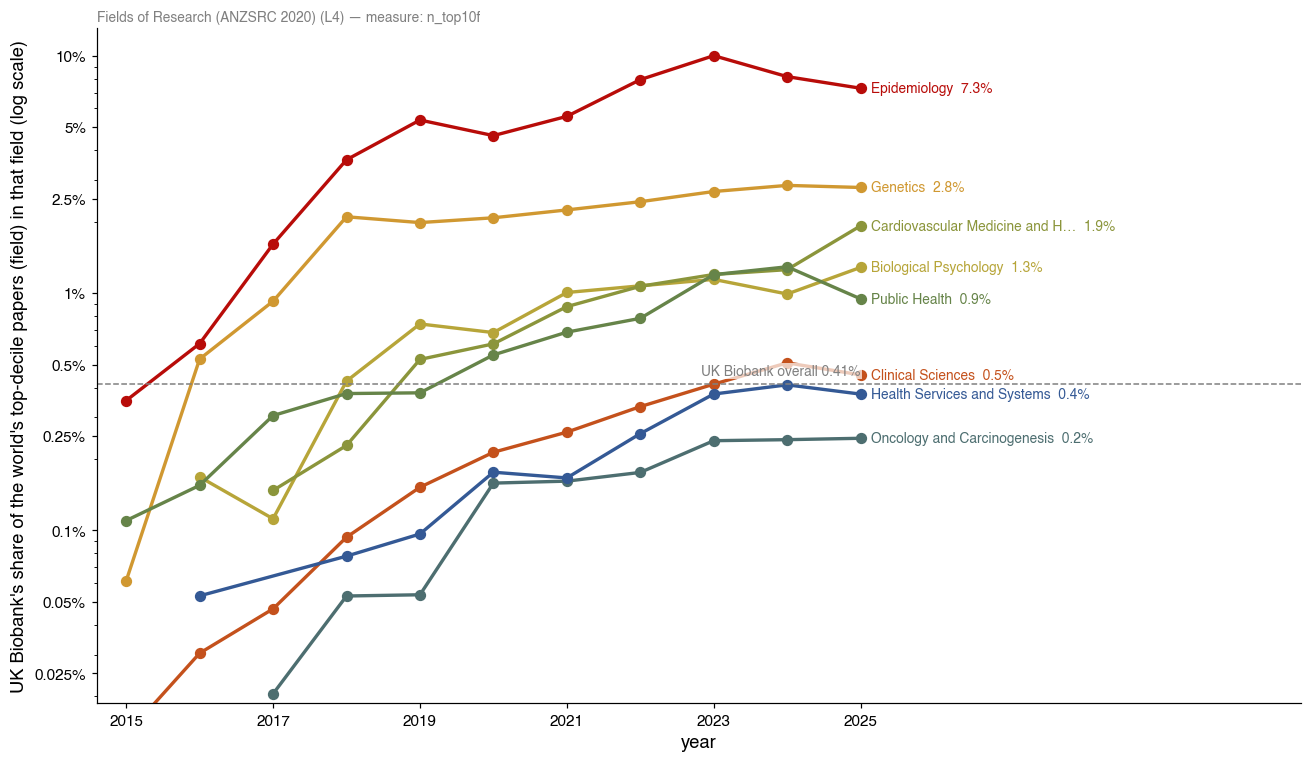

UK Biobank's share of the world's top-decile papers (field), 2025 (and how it moved since each field's first measured year):

  Epidemiology                               7.30% in 2025   ( 0.35% in 2015, up 6.95pp)
  Genetics                                   2.79% in 2025   ( 0.06% in 2015, up 2.73pp)
  Cardiovascular Medicine and Haematology    1.92% in 2025   ( 0.15% in 2017, up 1.77pp)
  Biological Psychology                      1.28% in 2025   ( 0.17% in 2016, up 1.12pp)
  Public Health                              0.95% in 2025   ( 0.11% in 2015, up 0.84pp)
  Clinical Sciences                          0.45% in 2025   ( 0.01% in 2015, up 0.44pp)
  Health Services and Systems                0.38% in 2025   ( 0.05% in 2016, up 0.32pp)
  Oncology and Carcinogenesis                0.24% in 2025   ( 0.02% in 2017, up 0.22pp)


In [13]:
_m = CITE_SHARE_METRIC
if _m not in MEASURES:
    print(f"CITE_SHARE_METRIC={_m} is not in these partials "
          f"(have: {', '.join(m for m in MEASURES if not m.endswith('_docs'))});"
          f"\nfalling back to n_papers — the volume share.\n")
    _m = "n_papers"
_mname = {"n_papers": "papers", "n_cit": "citations", "n_mncs": "field-relative citations",
          "n_fcr": "field-normalised citation weight",
          "n_top10": "top-decile papers",
          "n_top10f": "top-decile papers (field)",
          "n_top50f": "papers above the field median"}[_m]
_cshare = share_timeseries(_m)
if _m in CITE_YEARS:                      # citation metrics stop where the data does
    _cshare = _cshare.loc[_cshare.index.isin(CITE_YEARS[_m])]
_cshare = _cshare.rename(columns=dict(zip(TOP_CODES, TOP_LABELS)))
# A share of exactly zero has no place on a log axis — matplotlib draws it as a line
# dropping off the bottom of the panel, which reads as a crash rather than as "UK
# Biobank had no papers in this field that year". Blank them instead.
_cshare = _cshare.where(_cshare > 0)

fig, ax = plt.subplots(figsize=STYLE["figsize"])
ends = []
for lab in TOP_LABELS:
    s = _cshare[lab].dropna()
    if not len(s):
        continue
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2.2, marker="o", ms=STYLE["marker_size"] * 0.75)
    ends.append((float(s.iloc[-1]), float(s.index[-1]), lab))

# Direct labels carrying the final value, so the chart can be read without the axis.
_lo = min(v for v, _, _ in ends) if ends else 0.1
_hi = max(v for v, _, _ in ends) if ends else 1.0
_gap, _prev = 0.042 * (np.log10(_hi / max(_lo, 1e-6)) + 0.4), None
for value, xend, lab in sorted(ends):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    ax.annotate(f"{short(lab, 30)}  {value:.1f}%", (xend, 10 ** ly),
                color=FIELD_COLORS[lab], fontsize=STYLE["annot_fs"], va="center",
                xytext=(7, 0), textcoords="offset points")

# UK Biobank's overall share of this measure — the line a field has to beat to be one
# of its stronger showings rather than simply a big field.
_u_all = ukbb[ukbb.year.between(*CITE_WIN)][_m].sum()
_w_all = whole[whole.year.between(*CITE_WIN)][_m].sum()
_overall_share = 100 * _u_all / _w_all
ax.axhline(_overall_share, color=STYLE["edgecolor"], lw=1, ls="--")
ax.annotate(f"UK Biobank overall {_overall_share:.2f}%",
            (int(_cshare.dropna(how="all").index.max()), _overall_share),
            color=STYLE["edgecolor"], fontsize=STYLE["annot_fs"], va="bottom",
            ha="right", xytext=(0, 4), textcoords="offset points",
            bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.6))

ax.set_yscale("log")            # shares span two orders of magnitude across fields
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
# The early years are a rounding error against today's shares — a field UK Biobank
# entered in 2015 starts at 0.01% — and letting them set the floor squashes the decade
# that matters into the top inch. The axis starts two decades below the LATEST values
# instead, so the lines enter from the bottom rather than dictating the scale.
_floor = max(_hi / 300, float(np.nanmin(_cshare.values)))
_ticks = [t for t in (0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2.5, 5, 10, 25)
          if _floor / 1.2 <= t <= _hi * 1.6]
ax.set_yticks(_ticks)
ax.set_ylim(_floor / 1.3, _hi * 1.8)
# The span this chart DREW may be narrower than the full study window CITE_WIN:
# _m follows its measured reference years (CITE_YEARS[_m]). Labelling from CITE_WIN
# put "2022" on a series whose last point is 2023.
_yrs = _cshare.dropna(how="all").index
_drawn_lo, _drawn_hi = int(_yrs.min()), int(_yrs.max())
ax.set_xlim(_drawn_lo - 0.4, _drawn_hi + 6)
# Ticks anchored on the last drawn year too: stepping by 2 from 2015 stops at 2023, which
# left the 2023 endpoint sitting past an unlabelled tick and reading as 2022.
ax.set_xticks(year_ticks(_drawn_lo, _drawn_hi, 2))
ax.set_xlabel("year")
ax.set_ylabel(f"UK Biobank's share of the world's {_mname} in that {UNIT} (log scale)")
set_title(ax, f"UK Biobank's share of {_mname}, by {UNIT} ({_drawn_lo}-{_drawn_hi})",
             loc="left", fontsize=STYLE["title_fs"], pad=18)
ax.annotate(f"{SYSTEM} ({LEVEL}{VIEW_NOTE}) — measure: {_m}", (0, 1.005),
            xycoords="axes fraction", ha="left", va="bottom",
            fontsize=STYLE["annot_fs"], color=STYLE["edgecolor"])
flag_denominator(ax)
fig.tight_layout()
savefig(fig, f"07_citation_share_{COL_TYPE}_{LEVEL}{FILE_TAG}_{_m}")
plt.show()

# Each field's own first and last year, because they differ: a measured cut-off exists
# only where it was measured, so Cardiovascular starts two years after Epidemiology.
print(f"UK Biobank's share of the world's {_mname}, {_drawn_hi} "
      f"(and how it moved since each {UNIT}'s first measured year):\n")
for value, last_year, lab in sorted(ends, reverse=True):
    s = _cshare[lab].dropna()
    first = float(s.iloc[0])
    arrow = "up" if value > first else "down"
    print(f"  {short(lab, 40):40s} {value:6.2f}% in {int(last_year)}   "
          f"({first:5.2f}% in {int(s.index[0])}, {arrow} {abs(value - first):.2f}pp)")


## 6. Quality bands — the citation cut-offs behind the percentiles

§5 works in ratios. This part puts the same claim back into counts a reader can check a single
paper against: what "top decile" and "above the median" were **worth in citations** in each
year, how much of UK Biobank's footprint in a field clears each bar, and how large the field's
top-cited pool is in the first place.

| | question |
|---|---|
| §6.1 | what were the cut-offs, per (year, field)? |
| Chart 9 | how much of UK Biobank's slice of a field clears the field's median, and its top decile? |
| Chart 9a | were the bands moving, or were the cut-offs? |
| Chart 10 | how big is the field's top-decile pool, and how much of it is UK Biobank's? |

All of §6 needs cut-off columns that only some pathways carry; each cell says what is missing
and skips itself rather than drawing something it cannot support.


### 6.1 The cut-offs behind the quality bands

Charts 9, 9a and 10 all split UK Biobank's papers by where they land in their **own field's**
citation distribution. "Top decile" and "above the median" are percentile language; this cell
puts both back into a unit a reader can check a single paper against, and hands the charts a
per-panel annotation built from it.

* **`thr10`** — the top-decile cut-off for that (year, field): the lowest citation count
  whose at-or-above tail is still inside the field's most-cited tenth. Binary-searched
  cell by cell against the live index (`percentiles --percentiles 10`), so it exists only
  where it was measured. Across UK Biobank's top eight that is **2015 for four fields,
  2016 for two and 2017 for two** — Biological Psychology and Health Services entering in
  2016, Cardiovascular and Oncology in 2017, none of them holding 10 UK Biobank papers in
  a cell before then.
  The retained reference cache has **no 2013 or 2014 threshold rows**. Publications in
  those years remain in the study; these percentile metrics are unavailable for them.

* **`median`** — the field-year median, measured **the same way** (`--percentiles 50`) and
  in the same pass, so it is an **integer** cut-off with the field's own count above it.
  This is the cut-off the `n_top50f` band uses, and because that count is measured, the
  whole-database side of the band is counted rather than imputed at half the field.

  Both cut-offs come back with the share they actually achieved, which is the honest
  reading of how well a cell supports a percentile at all. Over the **213 measured L4
  cells**: the decile lands at **7.30-10.00%** (median 9.77%) — tight, because a tail has
  few ties — while the median lands at **34.23-50.00%** (median **47.69%**), and **49
  cells** fall more than five points short. That is not error: citations are small integers with
  enormous ties, so in a recent year the cut sits at ">= 1 citation" and more than half
  the field is uncited. The count above the cut is still exact; what is approximate is
  calling it the 50th percentile.

  *(Before this was measured, the notebook read `citations_median` off the facet — an
  interpolated percentile that came back fractional (0.1, 0.88, 2.02) in 3,365 of 3,762
  cells, silently cut at `ceil()`, and forced the background arm to assume exactly half
  the field. Cells the percentile pass never reached still fall back to it, and say so.)*

* **`mean`** — the field-year mean, **for scale only**. Citation distributions are skewed hard
  enough that the mean sits near the 70th percentile, not in the middle: in 2020 Epidemiology
  the mean is 27.8 and the measured median is 7.

All three fall steeply with publication year because citations accrue — 2015's tenth-best
Epidemiology paper needed 63 citations, 2025's needs 8. **That is the clock, not a decline in
standards**, and it is exactly why the cut is taken per year.


In [14]:
CUTS = None
if SOURCE == "api":
    try:
        # field_thresholds carries one row per (year, field, PERCENTILE): the top decile
        # and the median are two measurements of the same cell, so each is picked out by
        # its own percentile rather than merged blind.
        _thr = pd.read_csv(COUNTS_DIR / f"field_thresholds.{COL_TYPE}.csv",
                           dtype={"code": str})
        if "percentile" not in _thr.columns:
            _thr["percentile"] = 10.0      # a file from before the percentiles mode
        _thr = filter_analysis_window(_thr)
        _thr = _thr[_thr.level == LEVEL]
        _med = pd.read_parquet(COUNTS_DIR / f"api_whole.{COL_TYPE}.parquet",
                               columns=["year", "level", "code", "mean_cit",
                                        "api_citations_median"])
        _med = filter_analysis_window(_med)
        _p10 = (_thr.loc[_thr.percentile == 10, ["year", "code", "threshold"]]
                .rename(columns={"threshold": "thr10"}))
        _cols50 = ["year", "code", "threshold"] + (
            ["achieved_pct"] if "achieved_pct" in _thr.columns else [])
        _p50 = (_thr.loc[_thr.percentile == 50, _cols50]
                .rename(columns={"threshold": "med_meas", "achieved_pct": "med_pct"}))
        if "med_pct" not in _p50.columns:
            _p50["med_pct"] = np.nan
        CUTS = (_med[_med.level == LEVEL]
                .merge(_p10, on=["year", "code"], how="left")
                .merge(_p50, on=["year", "code"], how="left")
                .astype({"year": int}))
        # The MEASURED median wherever the percentile pass reached the cell; only
        # otherwise the facet's interpolated citations_median, which is fractional, cuts
        # at ceil() and has no count of the field behind it (§6.1).
        CUTS["median_measured"] = CUTS.med_meas.notna()
        CUTS["median"] = CUTS.med_meas.fillna(CUTS.api_citations_median)
        CUTS = CUTS.set_index(["year", "code"])[["thr10", "median", "mean_cit",
                                                 "med_pct", "median_measured"]]
        _n10, _n50 = int(CUTS.thr10.notna().sum()), int(CUTS.median_measured.sum())
        print(f"cut-offs: top decile measured in {_n10} cell(s), median in {_n50}"
              + ("" if _n50 else " — falling back to the facet's INTERPOLATED median")
              + "\n")
    except (FileNotFoundError, KeyError) as exc:
        print(f"no cut-off tables in {P.raw_path(COUNTS_DIR)} ({exc}) — the charts draw without them")

def _cit(v):
    """A citation cut-off as a reader would say it: 59, 6, 0.4."""
    return "–" if v != v else (f"{v:.0f}" if v >= 1 else f"{v:.1f}")


def _cites(v):
    """The same, with its unit: "16 cites", "1 cite", "0.4 cites"."""
    return "–" if v != v else f"{_cit(v)} cite" + ("" if v == 1 else "s")

def contiguous_tail(index):
    """The longest run of CONSECUTIVE years ending at the last one.

    A cut-off exists only where it was measured, and the cells that were measured are
    the ones UK Biobank had papers in — so a field can have 2015 measured, 2016 and
    2017 not, and 2018 onwards measured again. Plotting that index as-is draws a
    straight line across the hole, which reads as a smooth trend through years nobody
    looked at. Dropping the isolated head is the honest reading: the panel starts where
    the uninterrupted record starts.
    """
    years = [int(y) for y in index]
    if len(years) < 2:
        return index
    keep = [years[-1]]
    for y in reversed(years[:-1]):
        if keep[0] - y != 1:
            break
        keep.insert(0, y)
    return index[[years.index(y) for y in keep]]


def cut_note(code, year):
    """One line naming what the bands mean in citations, for a single year.

    The cut-offs move every year — 2016's decile in Epidemiology is 59 citations and
    2024's is 16 — but a panel does not need the whole series to stay readable: what a
    reader wants is what "top decile" is worth at the sharp end of the chart, so only the
    final year is quoted here and the printed table below carries the rest.
    """
    if CUTS is None:
        return ""
    r = CUTS.reindex([(int(year), code)]).iloc[0]
    if r["median"] != r["median"]:
        return ""
    ten = "" if r.thr10 != r.thr10 else f"top 10%: at least {_cites(r.thr10)}   ·   "
    # A measured median cut says what share of the field it actually kept. Where that is
    # far off 50% the ties could not be split (most of the field is uncited), and the
    # band is "cited at all" rather than "above the median" — so the panel says so.
    got = r.get("med_pct", float("nan")) if hasattr(r, "get") else r["med_pct"]
    tail = ("" if (got != got or abs(got - 50) <= 5)
            else f" (= top {got:.0f}% of the {UNIT})")
    return f"{int(year)}:   {ten}median: at least {_cites(r['median'])}{tail}"


if CUTS is not None:
    _show = [y for y in (2016, 2020, YEAR_MAX) if (y, TOP_CODES[0]) in CUTS.index]
    print(f"citation cut-offs per {UNIT} and year — what the bands are made of:\n")
    print(f"  {'':34s}" + "".join(f"{y:^24d}" for y in _show))
    print(f"  {'':34s}" + "".join(f"{'top10%   median   mean':^24s}" for _ in _show))
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        cells = ""
        for y in _show:
            r = CUTS.reindex([(y, code)]).iloc[0]
            cells += f"{_cit(r.thr10):>7s}{_cit(r['median']):>9s}{_cit(r.mean_cit):>8s}"
        print(f"  {short(lab, 32):34s}{cells}")
    print("\n(the cut-offs fall with year because citations accrue; a 2024 paper has had "
          "one year\n to collect them and a 2016 paper nine)")

cut-offs: top decile measured in 213 cell(s), median in 213

citation cut-offs per field and year — what the bands are made of:

                                              2016                    2020                    2025          
                                     top10%   median   mean  top10%   median   mean  top10%   median   mean 
  Epidemiology                           59        6      29     54        7      28      8        2       3
  Clinical Sciences                      48        5      20     36        4      17      5        1       2
  Genetics                               74       13      39     47        9      22      7        2       3
  Biological Psychology                  72       12      30     45        8      19      7        1       2
  Cardiovascular Medicine and Hae…        –        2      16     28        3      12      5        1       1
  Public Health                          57        8      25     44        7      20      6        1       2

### 6.2 Chart 9 — The footprint cut twice: the best tenth and the better half

This draws UK Biobank's slice of each field — the same footprint Chart 2's right panel plots —
and cuts it at the field's own citation distribution. The top decile is a demanding bar, and a
paper just under it is not an ordinary paper, so the slice is split at **both** cut-offs:

| | |
|---|---|
| **total height** | UK Biobank's papers as a % of all the field's papers |
| **solid band** | those in the field's most-cited **tenth** |
| **pale band** | the rest of those above the field's **median** |
| **white** | the rest — below the median of their own field |

The two reference points would be arithmetic if the cuts were exact — an ordinary paper is in
its field's top decile **a tenth** of the time and above its field's median **half** the time —
so a solid band at 16% of the line reads as 1.6× an ordinary performance and a pale band at 55%
as 1.1×. **Use the measured share, not the round number, wherever the two differ.** The decile
cut achieves 7.3-10.0% and the round 10% is close enough; the median cut achieves 34-50%
(median 48%), so in the years where it falls short, dividing by 50 understates the multiplier —
a 58% band against a cut that keeps 34% of the field is 1.7×, not 1.2×. §6.1 prints what each cell
achieved, and the panel annotation carries it wherever it is more than five points off.

White is deliberately empty: the solid line already draws the footprint, so an unfilled gap under
it reads as "the part of UK Biobank's output that is not above the median" without adding a
fourth colour.

**Both cut-offs are measured the same way** — binary-searched per (year, field) against
the live index by `percentiles --percentiles 10,50`, ~13 queries a cell for the pair,
which is why a panel starts in 2015, 2016 or 2017 rather than at the window's edge. Neither is interpolated and neither
side of either band is imputed: the pass records `n_at_or_above`, the whole database's own
count above the cut, so UK Biobank's papers and the world's are counted against the same
integer bar.

What survives is not an error but a limit: **a percentile is often unreachable**. Half a
field's papers is a big enough set that the median cut is usually within a point or two of
50%, but in the most recent years, where most papers are uncited, the cut lands at
">= 1 citation" and keeps as little as 34% of the field. The measured share is recorded per cell, so a panel
whose median band is really "cited at all" says so rather than quietly claiming half.

*Saves as* `09_footprint_quality_median_…`


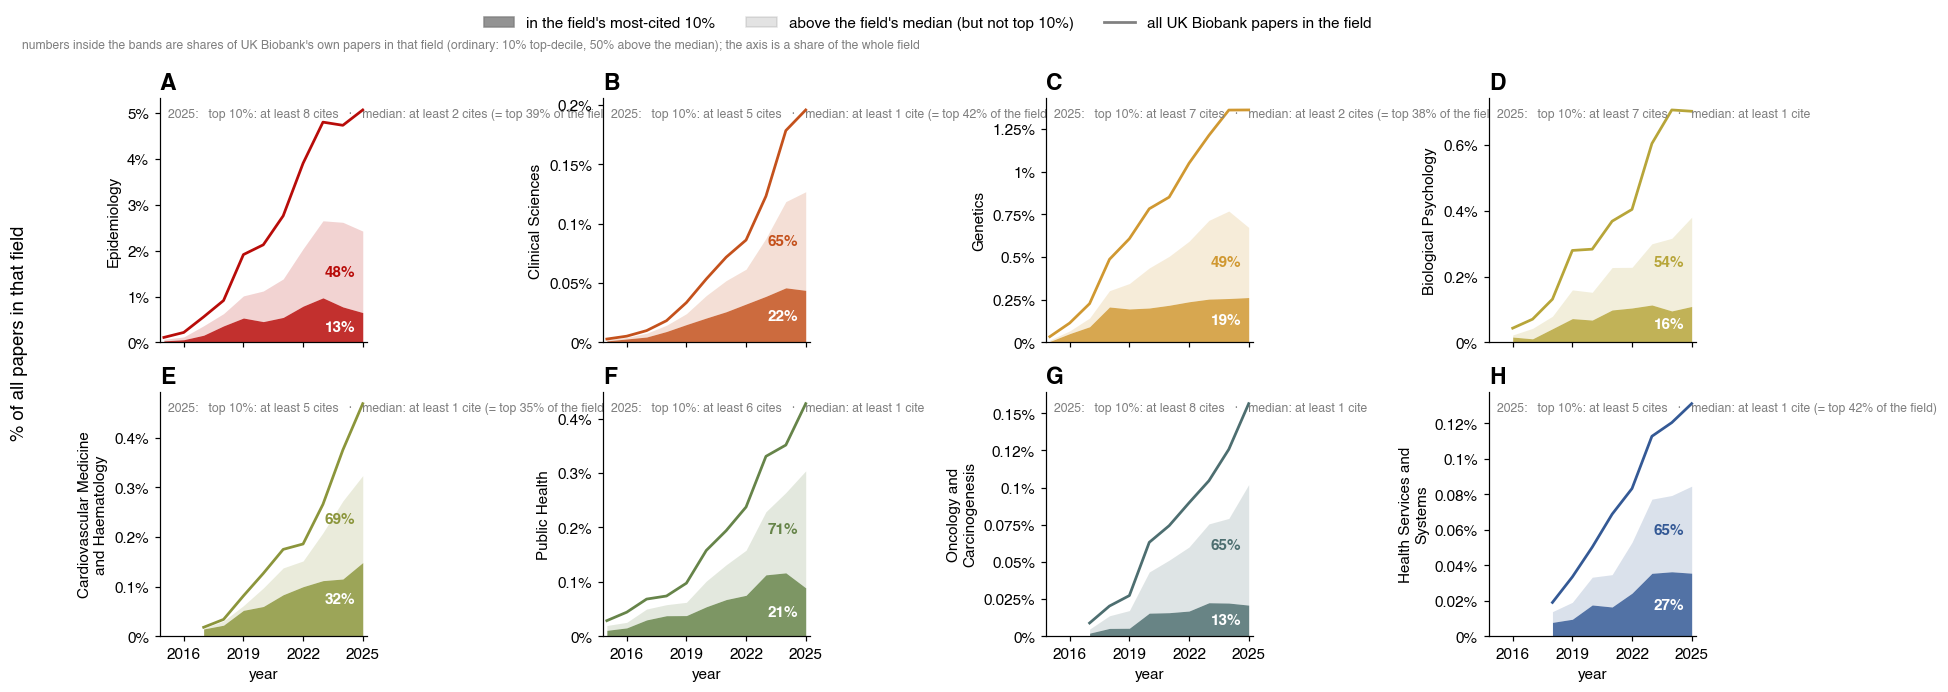

in 2025, of UK Biobank's papers in each field (an ordinary paper is above its field's median half the time, and in its top decile a tenth of the time):

  Epidemiology                      47.9% above the median ( 1.0x),  12.9% top decile ( 1.3x)
  Clinical Sciences                 64.8% above the median ( 1.3x),  22.4% top decile ( 2.2x)
  Genetics                          49.5% above the median ( 1.0x),  19.3% top decile ( 1.9x)
  Biological Psychology             54.2% above the median ( 1.1x),  15.6% top decile ( 1.6x)
  Cardiovascular Medicine and Hae…  69.1% above the median ( 1.4x),  31.7% top decile ( 3.2x)
  Public Health                     71.1% above the median ( 1.4x),  20.8% top decile ( 2.1x)
  Oncology and Carcinogenesis       65.2% above the median ( 1.3x),  13.4% top decile ( 1.3x)
  Health Services and Systems       64.5% above the median ( 1.3x),  27.1% top decile ( 2.7x)


In [15]:
if TOP10_COL is None or TOP50_COL is None:
    print("chart 9a needs both cut-offs — the API pathway carries them "
          f"(top10={TOP10_COL}, median={TOP50_COL})")
else:
    _all = share_timeseries("n_papers")                             # the footprint
    _best = share_timeseries(TOP10_COL, denominator="n_papers")     # its top-decile part
    _half = share_timeseries(TOP50_COL, denominator="n_papers")     # its above-median part
    # A cell whose cut-off was never measured comes back as a zero count, not as a gap,
    # and zero here would draw as "none of its papers made the decile" — the opposite of
    # "we did not look". The _docs counters say which it is, so they are the mask: a band
    # is drawn only where the papers under it were actually scored against a cut-off.
    def _measured(column):
        return (ukbb[ukbb.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=f"{column}_docs",
                             aggfunc="sum").reindex(columns=TOP_CODES))
    _best = _best.where(_measured(TOP10_COL).reindex_like(_best) > 0)
    _half = _half.where(_measured(TOP50_COL).reindex_like(_half) > 0)
    _yrs = sorted(set(_all.index) & set(_best.index) & set(_half.index))
    _all, _best, _half = (f.loc[f.index.isin(_yrs)] for f in (_all, _best, _half))
    _drawn = []          # the years each panel could actually draw, for the title

    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b, h = _all[code].dropna(), _best[code].dropna(), _half[code].dropna()
        idx = a.index.intersection(b.index).intersection(h.index)
        idx = contiguous_tail(idx)
        a, b, h = a.reindex(idx), b.reindex(idx), h.reindex(idx)
        # A paper above the decile is above the median too, so the bands nest; clip in
        # case a tie at the median cut-off makes the coarser count the smaller one.
        h = np.maximum(h, b)
        if not len(idx):
            continue
        _drawn += [int(idx[0]), int(idx[-1])]
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, h, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        set_title(ax, chr(65 + list(axes).index(ax)), fontsize=STYLE["title_fs"])
        facet_ylabel(ax, lab, fontsize=STYLE["annot_fs"] + 1)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        # Each share is written into the band it belongs to: white on the solid one,
        # the field's own colour on the pale one, which needs no legend lookup and no
        # second sentence explaining which number is which.
        if len(a) and a.iloc[-1] > 0:
            if b.iloc[-1] > 0:
                ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], b.iloc[-1] / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color="white", fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
            if h.iloc[-1] > b.iloc[-1]:
                ax.annotate(f"{100 * h.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], (h.iloc[-1] + b.iloc[-1]) / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color=col, fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
        ax.annotate(cut_note(code, idx[-1]), xy=(0.04, 0.96), xycoords="axes fraction",
                    ha="left", va="top", fontsize=STYLE["annot_fs"] - 1,
                    color=STYLE["edgecolor"])
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(min(_drawn), max(_drawn), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # Neutral grey patches: the encoding is what the legend describes, and every panel
    # has its own colour for the field.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    # As in chart 9: the bands are read against the FIELD, the numbers written in them
    # against UK BIOBANK'S OWN output (an ordinary paper: 10% top-decile, 50% above the
    # median).
    fig.text(0.01, 0.905, f"numbers inside the bands are shares of UK Biobank's own "
             f"papers in that {UNIT} (ordinary: 10% top-decile, 50% above the median); "
             f"the axis is a share of the whole {UNIT}",
             fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"], ha="left", va="top")
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="in the field's most-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22,
              label="above the field's median (but not top 10%)"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8,
               label="all UK Biobank papers in the field")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    set_figure_title(fig, f"UK Biobank's share of each {UNIT}, split at the {UNIT}'s own median "
                 f"and top decile ({min(_drawn)}-{max(_drawn)})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"09_footprint_quality_median_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last = max(_drawn)
    print(f"in {_last}, of UK Biobank's papers in each {UNIT} (an ordinary paper is "
          f"above its field's median half the time, and in its top decile a tenth of "
          f"the time):\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        a = _all[code].get(_last, np.nan)
        b, h = _best[code].get(_last, np.nan), _half[code].get(_last, np.nan)
        if not (np.isfinite(a) and np.isfinite(h) and a > 0):
            continue
        print(f"  {short(lab, 32):32s} {100 * h / a:5.1f}% above the median "
              f"({100 * h / a / 50:4.1f}x), {100 * b / a:5.1f}% top decile "
              f"({100 * b / a / 10:4.1f}x)")

### 6.3 Chart 9a — Chart 9 with the cut-offs drawn on a second axis

Chart 9 says what share of UK Biobank's papers cleared each bar. It does not say **where the bar
was**, and the bar moves every year: a 2016 Epidemiology paper needed 59 citations to make the
field's top tenth, a 2024 one needs 16. Read without that, the fall in the solid band after 2022
looks like a fall in quality, when the cut-off is simply still filling in for papers a year old.

| axis | what it shows |
|---|---|
| **left (bands)** | exactly Chart 9: solid = top decile, pale = above the median, line = UK Biobank's whole share of the field |
| **right (dashes)** | what those two cut-offs were, **in citations**, in the same year: dashed = top-decile cut-off, dotted = median |

The right axis is a different quantity in different units, so it is drawn in grey and never
filled — **nothing on it is meant to be compared to the bands by height**. What it is for is the
*shape*: both cut-offs decay to the right at much the same rate in every field, which is the
citation clock, and the bands do not follow them down. That is the argument this chart makes and
9 cannot.

*Saves as* `09a_footprint_quality_cutoffs_…`


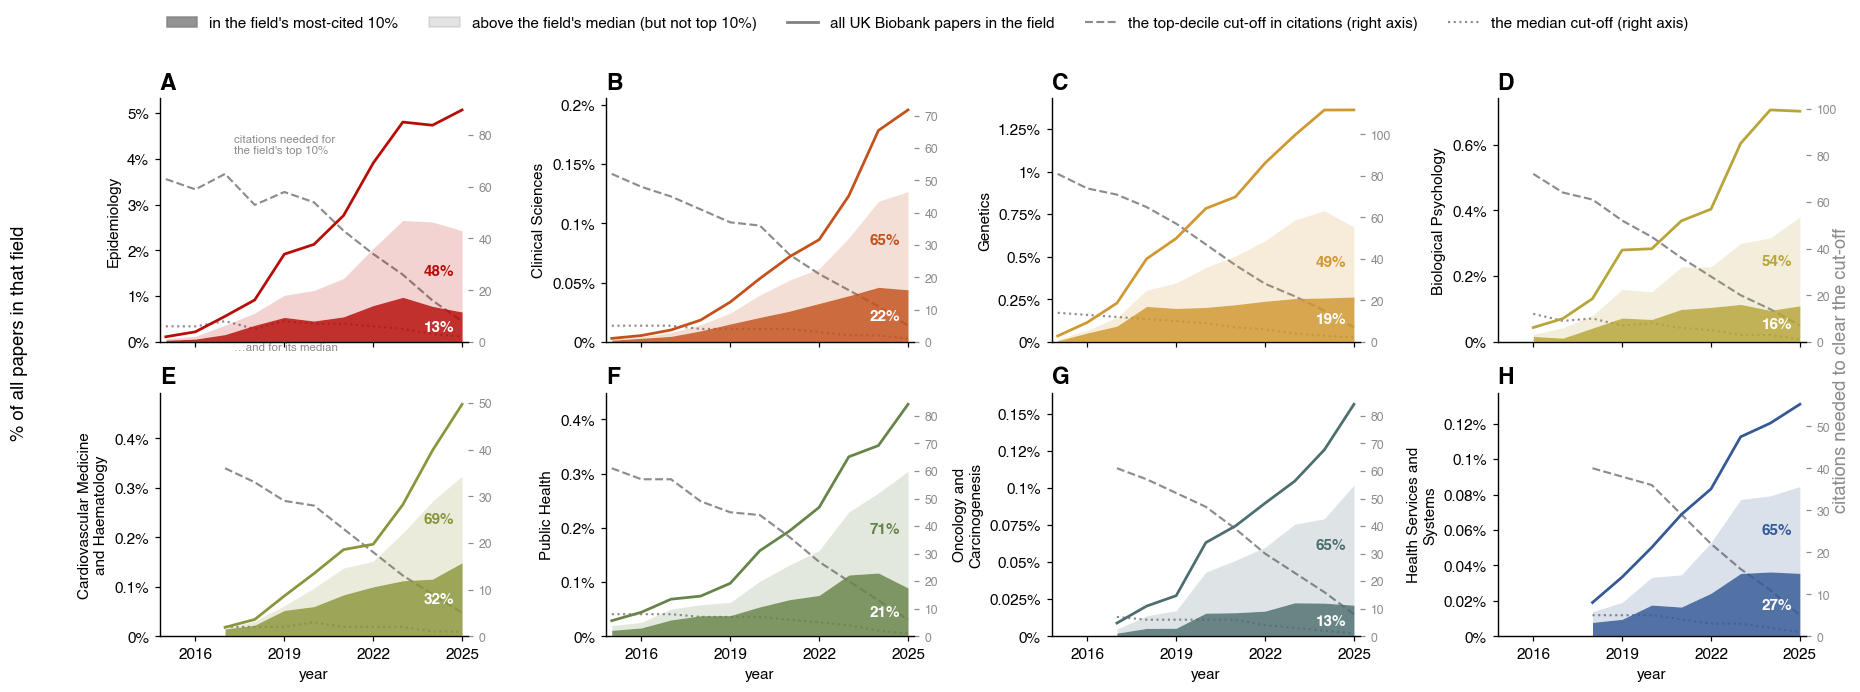

what it took to clear each bar, 2015 vs 2025 (a 2025 paper has had one year to collect citations, a 2015 one 10):

  Epidemiology                     top 10%:   63 ->    8 cites    median:    6 ->    2
  Clinical Sciences                top 10%:   52 ->    5 cites    median:    5 ->    1
  Genetics                         top 10%:   81 ->    7 cites    median:   14 ->    2
  Public Health                    top 10%:   61 ->    6 cites    median:    8 ->    1


In [16]:
if TOP10_COL is None or TOP50_COL is None or CUTS is None:
    print("chart 9b needs both cut-offs — the API pathway carries them "
          f"(top10={TOP10_COL}, median={TOP50_COL})")
else:
    _all = share_timeseries("n_papers")                             # the footprint
    _best = share_timeseries(TOP10_COL, denominator="n_papers")     # its top-decile part
    _half = share_timeseries(TOP50_COL, denominator="n_papers")     # its above-median part
    # A cell whose cut-off was never measured comes back as a zero count, not as a gap,
    # and zero here would draw as "none of its papers made the decile" — the opposite of
    # "we did not look". The _docs counters say which it is, so they are the mask: a band
    # is drawn only where the papers under it were actually scored against a cut-off.
    def _measured(column):
        return (ukbb[ukbb.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=f"{column}_docs",
                             aggfunc="sum").reindex(columns=TOP_CODES))
    _best = _best.where(_measured(TOP10_COL).reindex_like(_best) > 0)
    _half = _half.where(_measured(TOP50_COL).reindex_like(_half) > 0)
    _yrs = sorted(set(_all.index) & set(_best.index) & set(_half.index))
    _all, _best, _half = (f.loc[f.index.isin(_yrs)] for f in (_all, _best, _half))
    _drawn = []          # the years each panel could actually draw, for the title

    C_CUT = "#8C8C8C"      # the cut-off axis: grey, because it is not the subject
    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        a, b, h = _all[code].dropna(), _best[code].dropna(), _half[code].dropna()
        idx = a.index.intersection(b.index).intersection(h.index)
        idx = contiguous_tail(idx)
        a, b, h = a.reindex(idx), b.reindex(idx), h.reindex(idx)
        # A paper above the decile is above the median too, so the bands nest; clip in
        # case a tie at the median cut-off makes the coarser count the smaller one.
        h = np.maximum(h, b)
        if not len(idx):
            continue
        _drawn += [int(idx[0]), int(idx[-1])]
        ax.fill_between(idx, 0, b, color=col, alpha=0.85, lw=0)
        ax.fill_between(idx, b, h, color=col, alpha=0.18, lw=0)
        ax.plot(idx, a, color=col, lw=1.8)
        # ---- the cut-offs themselves, in citations, on their own axis -------------
        _c = CUTS.reindex([(int(y), code) for y in idx])
        axc = ax.twinx()
        axc.plot(idx, _c.thr10.to_numpy(), color=C_CUT, lw=1.4, ls="--")
        axc.plot(idx, _c["median"].to_numpy(), color=C_CUT, lw=1.4, ls=":")
        # Anchored at zero and headroom above the decile line, so the median line is not
        # squashed onto the axis and neither can be mistaken for one of the bands.
        axc.set_ylim(0, float(np.nanmax(_c.thr10.to_numpy())) * 1.45)
        axc.tick_params(labelsize=STYLE["annot_fs"] - 1, colors=C_CUT)
        axc.spines["right"].set_color(C_CUT)
        if code == TOP_CODES[0]:
            _m = min(2, len(idx) - 1)
            axc.annotate("citations needed for\nthe field's top 10%",
                         xy=(idx[_m], float(_c.thr10.iloc[_m])), xytext=(6, 12),
                         textcoords="offset points", ha="left", va="bottom",
                         fontsize=STYLE["annot_fs"] - 1.5, color=C_CUT)
            axc.annotate("…and for its median",
                         xy=(idx[_m], float(_c["median"].iloc[_m])), xytext=(6, -14),
                         textcoords="offset points", ha="left", va="top",
                         fontsize=STYLE["annot_fs"] - 1.5, color=C_CUT)
        ax.set_zorder(axc.get_zorder() + 1)   # keep the bands' labels above the dashes
        ax.patch.set_visible(False)
        set_title(ax, chr(65 + list(axes).index(ax)), fontsize=STYLE["title_fs"])
        facet_ylabel(ax, lab, fontsize=STYLE["annot_fs"] + 1)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda v, _: f"{v:g}%" if v >= 1 else f"{v:.2g}%"))
        ax.set_ylim(bottom=0)
        ax.margins(x=0.02)
        # Each share is written into the band it belongs to: white on the solid one,
        # the field's own colour on the pale one, which needs no legend lookup and no
        # second sentence explaining which number is which.
        if len(a) and a.iloc[-1] > 0:
            if b.iloc[-1] > 0:
                ax.annotate(f"{100 * b.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], b.iloc[-1] / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color="white", fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
            if h.iloc[-1] > b.iloc[-1]:
                ax.annotate(f"{100 * h.iloc[-1] / a.iloc[-1]:.0f}%",
                            xy=(idx[-1], (h.iloc[-1] + b.iloc[-1]) / 2), xytext=(-5, 0),
                            textcoords="offset points", ha="right", va="center",
                            color=col, fontsize=STYLE["annot_fs"] + 1,
                            fontweight="bold")
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(min(_drawn), max(_drawn), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    # Neutral grey patches: the encoding is what the legend describes, and every panel
    # has its own colour for the field.
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Patch(color=STYLE["edgecolor"], alpha=0.85,
              label="in the field's most-cited 10%"),
        Patch(color=STYLE["edgecolor"], alpha=0.22,
              label="above the field's median (but not top 10%)"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8,
               label="all UK Biobank papers in the field"),
        Line2D([], [], color="#8C8C8C", lw=1.4, ls="--",
               label="the top-decile cut-off in citations (right axis)"),
        Line2D([], [], color="#8C8C8C", lw=1.4, ls=":",
               label="the median cut-off (right axis)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=5, frameon=False,
        fontsize=STYLE["legend_fs"])
    set_figure_title(fig, f"The same, against the cut-offs themselves: what it took to clear each "
                 f"bar, year by year ({min(_drawn)}-{max(_drawn)})",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"% of all papers in that {UNIT}", fontsize=STYLE["label_fs"], x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    fig.text(0.999, 0.45, "citations needed to clear the cut-off", rotation=90,
             va="center", ha="right", fontsize=STYLE["label_fs"], color=C_CUT)
    savefig(fig, f"09a_footprint_quality_cutoffs_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    _last, _first = max(_drawn), min(_drawn)
    print(f"what it took to clear each bar, {_first} vs {_last} "
          f"(a {_last} paper has had one year to collect citations, a {_first} one "
          f"{_last - _first}):\n")
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        r0 = CUTS.reindex([(_first, code)]).iloc[0]
        r1 = CUTS.reindex([(_last, code)]).iloc[0]
        if r0.thr10 != r0.thr10 or r1.thr10 != r1.thr10:
            continue
        print(f"  {short(lab, 32):32s} top 10%: {_cit(r0.thr10):>4s} -> "
              f"{_cit(r1.thr10):>4s} cites    median: {_cit(r0['median']):>4s} -> "
              f"{_cit(r1['median']):>4s}")

### 6.4 Chart 10 — The field's top-cited pool, and UK Biobank in it

Chart 9 divides by the **field**: of all the papers published in Epidemiology, what share is UK
Biobank's, and how much of that share cleared each bar? This divides by the **top decile**: of
the papers that made the field's most-cited tenth, how many are there in the first place, and
how many of them are UK Biobank's?

| | |
|---|---|
| **bar height** | every paper in the world that made this field's top decile that year |
| **coloured foot** | UK Biobank's papers among them |
| **line** | that foot as a **percentage** of the bar (right axis) |

The line is not decoration. UK Biobank's share of these pools runs from 0.2% to 10%, a fiftyfold
spread, so at a common bar scale the coloured foot is a visible block in Epidemiology and a
hairline in Clinical Sciences — true, and unreadable. The line puts all eight panels on a scale
where the trend can be read; the foot keeps the reader honest about how small the absolute
contribution still is in the big fields.

**What the bar is and is not.** It is the count of papers at or above the measured decile cut-off
for that (year, field) — so it is ~10% of the field's papers by construction, and its **growth is
the field's growth**, not a change in standards. What moves between panels is the pool's size
(in 2025 Clinical Sciences puts 76,279 papers into its own top tenth; Epidemiology 2,411), which
is the context Chart 9's percentages do not carry. Years before the cut-off was measured are
absent rather than zero.

*Saves as* `10_top_decile_pool_…`


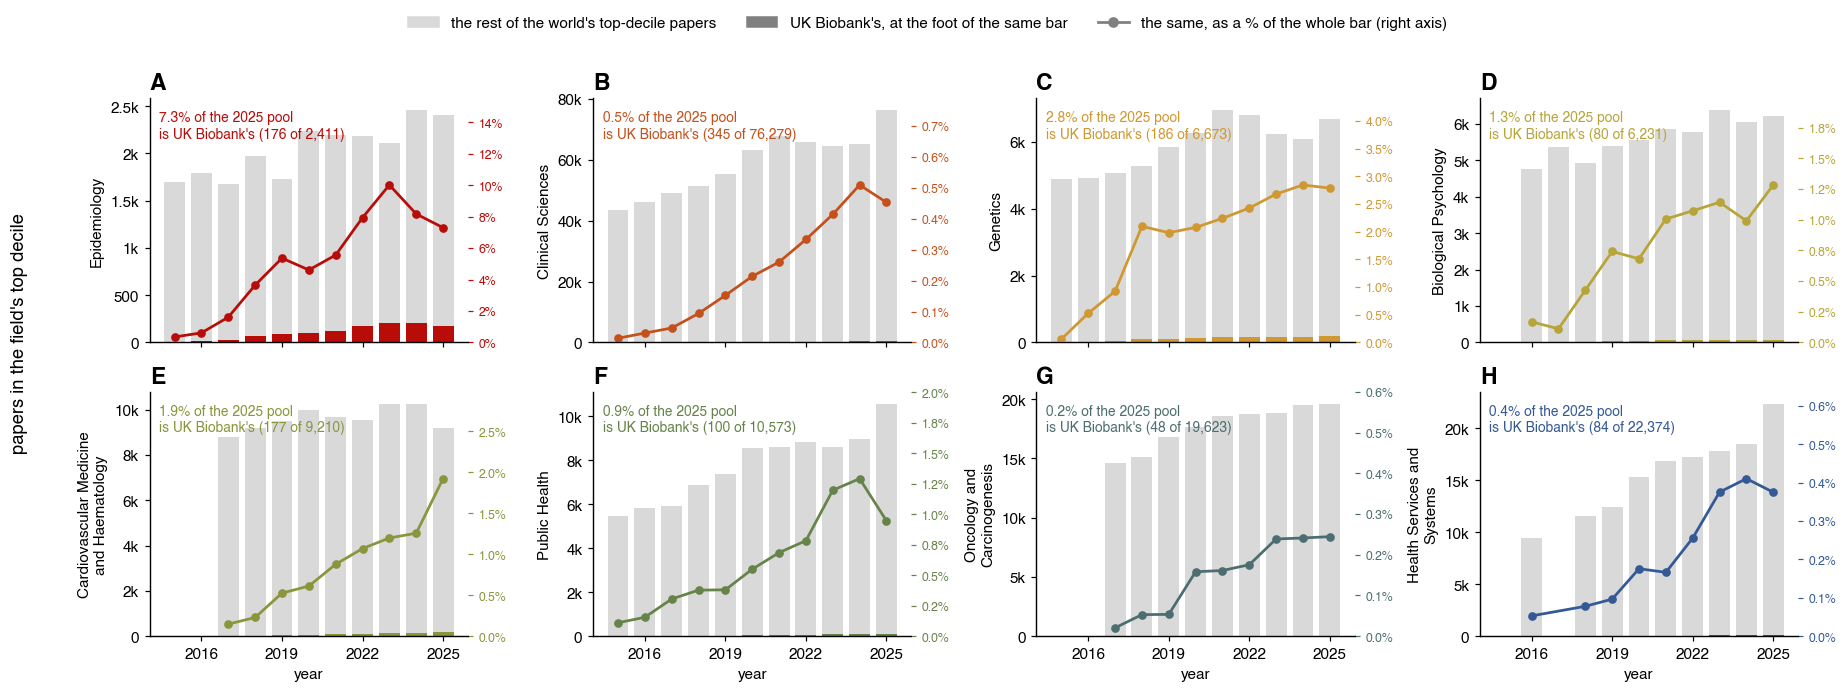


UK Biobank inside each field's most-cited tenth (the pool is ~10% of the field by construction, so its size is the field's size):


,pool@2025,ukbb@2025,ukbb_%@2025,measured_from,ukbb_%_then,x_since
field,,,,,,
Epidemiology,2411,176,7.30,2015,0.35,20.7
Clinical Sciences,76279,345,0.45,2015,0.01,32.9
Genetics,6673,186,2.79,2015,0.06,45.4
Biological Psychology,6231,80,1.28,2016,0.17,7.6
Cardiovascular Medicine and Haema…,9210,177,1.92,2017,0.15,13.0
Public Health,10573,100,0.95,2015,0.11,8.6
Oncology and Carcinogenesis,19623,48,0.24,2017,0.02,11.9
Health Services and Systems,22374,84,0.38,2016,0.05,7.1


In [17]:
if TOP10_COL is None:
    print("no top-decile column — VM: --weights top10,top10f; API: the `deciles` mode")
else:
    def _pool(frame, column):
        return (frame[frame.code.isin(TOP_CODES)]
                .pivot_table(index="year", columns="code", values=column, aggfunc="sum")
                .reindex(columns=TOP_CODES))
    _w10 = _pool(whole, TOP10_COL).where(_pool(whole, f"{TOP10_COL}_docs") > 0)
    _u10 = _pool(ukbb, TOP10_COL).where(_pool(ukbb, f"{TOP10_COL}_docs") > 0)
    _u10 = _u10.reindex_like(_w10)
    _shr = (_u10 / _w10.where(_w10 > 0) * 100)

    C_POOL = "#D9D9D9"       # the world's papers: present, deliberately quiet
    ncol = 4
    nrow = int(np.ceil(TOP_N / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.3 * nrow), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:g}k" if x >= 1000 else f"{x:g}")

    for ax, code, lab in zip(axes, TOP_CODES, TOP_LABELS):
        col = FIELD_COLORS[lab]
        pool = _w10[code].dropna()
        if not len(pool):
            continue
        ukb = _u10[code].reindex(pool.index).fillna(0.0)
        ax.bar(pool.index, pool.values - ukb.values, bottom=ukb.values, color=C_POOL,
               width=0.78, lw=0)
        ax.bar(pool.index, ukb.values, color=col, width=0.78, lw=0)
        set_title(ax, chr(65 + list(axes).index(ax)), fontsize=STYLE["title_fs"])
        facet_ylabel(ax, lab, fontsize=STYLE["annot_fs"] + 1)
        ax.yaxis.set_major_formatter(kfmt)
        ax.set_ylim(bottom=0)
        ax.margins(x=0.03)

        # Right axis: the same two numbers as one ratio, which is the only form in which
        # all eight panels are comparable.
        axp = ax.twinx()
        s = _shr[code].reindex(pool.index)
        axp.plot(s.index, s.values, color=col, lw=1.8, marker="o", ms=STYLE["marker_size"] * 0.55)
        axp.set_ylim(0, max(float(np.nanmax(s.values)) * 1.55, 0.6))
        axp.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"
                                      if np.nanmax(s.values) >= 3 else "{x:.1f}%"))
        axp.tick_params(labelsize=STYLE["annot_fs"] - 1, colors=col)
        axp.spines["right"].set_color(col)
        if s.notna().any():
            _l = s.dropna()
            axp.annotate(f"{_l.iloc[-1]:.1f}% of the {int(_l.index[-1])} pool\n"
                         f"is UK Biobank's ({int(ukb.iloc[-1]):,} of "
                         f"{int(pool.iloc[-1]):,})",
                         xy=(0.03, 0.95), xycoords="axes fraction", ha="left", va="top",
                         fontsize=STYLE["annot_fs"], color=col)
    # Shared x-axis, so one tick set serves every panel — anchored on the last year
    # drawn rather than on a multiple of the step, which would leave the endpoint bare.
    axes[0].set_xticks(year_ticks(_w10.dropna(how='all').index.min(), _w10.dropna(how='all').index.max(), 3))
    for ax in axes[TOP_N:]:
        ax.set_visible(False)
    for ax in axes[max(TOP_N - ncol, 0):TOP_N]:
        ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    fig.legend(handles=[
        Patch(color=C_POOL, label="the rest of the world's top-decile papers"),
        Patch(color=STYLE["edgecolor"], label="UK Biobank's, at the foot of the same bar"),
        Line2D([], [], color=STYLE["edgecolor"], lw=1.8, marker="o", ms=STYLE["marker_size"] * 0.70,
               label="the same, as a % of the whole bar (right axis)")],
        loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=3, frameon=False,
        fontsize=STYLE["legend_fs"])
    set_figure_title(fig, f"The most-cited tenth of each {UNIT}, year by year — how big that pool "
                 f"is, and how much of it is UK Biobank's",
                 fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
    fig.supylabel(f"papers in the {UNIT}'s top decile", fontsize=STYLE["label_fs"],
                  x=0.004)
    flag_denominator(fig)
    fig.tight_layout(rect=(0.015, 0, 1, 0.90))
    savefig(fig, f"10_top_decile_pool_{COL_TYPE}_{LEVEL}{FILE_TAG}")
    plt.show()

    # One row per field. The first measured year differs by field (a decile cut-off is
    # only measured where UK Biobank had papers to place against it), so it is a COLUMN
    # rather than part of the header — otherwise the table comes out ragged.
    _rows = []
    _end = int(max(_shr[c].dropna().index[-1] for c in TOP_CODES if _shr[c].notna().any()))
    for code, lab in zip(TOP_CODES, TOP_LABELS):
        s = _shr[code].dropna()
        if not len(s):
            continue
        _rows.append({UNIT: short(lab, 34),
                      f"pool@{_end}": int(_w10.loc[_end, code]),
                      f"ukbb@{_end}": int(_u10.loc[_end, code]),
                      f"ukbb_%@{_end}": round(float(s.loc[_end]), 2),
                      "measured_from": int(s.index[0]),
                      "ukbb_%_then": round(float(s.iloc[0]), 2),
                      "x_since": round(float(s.loc[_end] / s.iloc[0]), 1)
                      if s.iloc[0] > 0 else np.nan})
    print(f"\nUK Biobank inside each {UNIT}'s most-cited tenth "
          f"(the pool is ~10% of the {UNIT} by construction, so its size is the "
          f"{UNIT}'s size):")
    display(pd.DataFrame(_rows).set_index(UNIT))

## 7. Growth — where UK Biobank is growing fastest, and whether the world is too

### Chart 11 — Fastest-growing fields, against the same fields in the whole database

Every chart so far ranks fields by **size**: UK Biobank's biggest eight, followed through the
database. That ranking is stable by construction — Epidemiology and Clinical Sciences were the
biggest in 2016 and will be in 2026 — so it cannot show a field *arriving*. This one ranks by
**speed** instead, and drops the size filter: a field that went from 6 papers to 126 belongs here
beside one that went from 350 to 1,283.

**Two rates per field, measured the same way in both arms:**

* **growth** — the compound annual rate over `GROW_NOW`. 30%/yr means "a third bigger every year",
  and compounds to 2.9× over four years.
* **acceleration** — that rate minus the same rate over `GROW_PREV`, in percentage points per
  year. Positive = speeding up.

**Read the acceleration column with one fact in mind.** UK Biobank's own output was doubling
annually in the late 2010s from a base of almost nothing, so nearly every field decelerates
against that window; the number says "growing less explosively than during the ramp-up", not
"shrinking". The fields that accelerate anyway — Metabolomics, Allied Health — are doing something
genuinely new. The honest reference for "is this field gaining ground **inside** UK Biobank" is the
dashed line on the left panel: UK Biobank's own total growth rate. A field to its right is taking a
bigger share of the portfolio every year; one to its left is being diluted, however fast it grows.

**What the comparison with the world is for.** The hollow marker is the same field's growth in the
whole database. Most of these fields grow at 2–10%/yr out there, so the gap between the markers is
**UK Biobank moving into a field** rather than the field itself taking off. Neurosciences is the
sharpest case: the world's output is flat (−0.2%/yr) while UK Biobank's grows 47%/yr.

*Saves as* `11_fastest_growing_…`


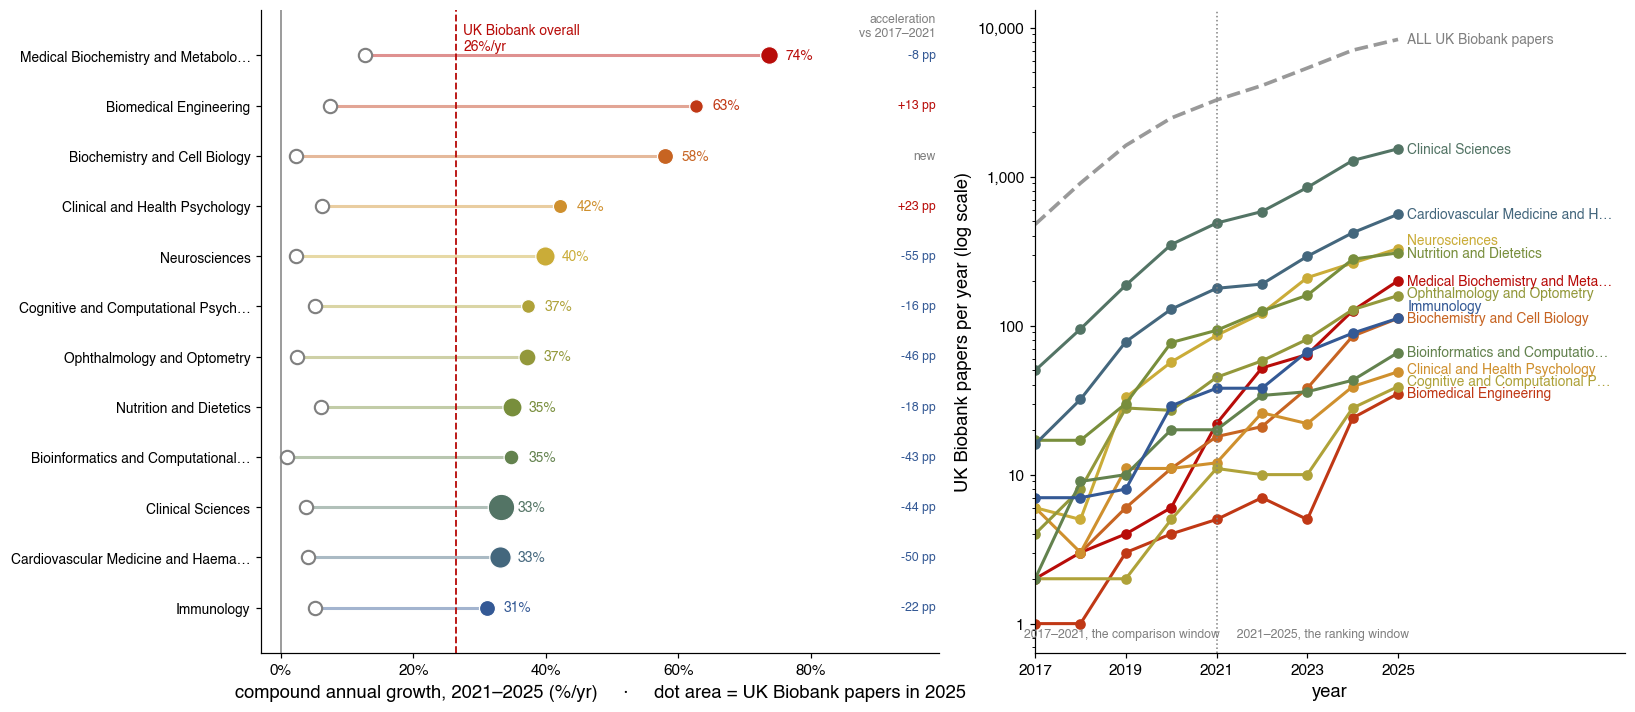

fastest-growing fields inside UK Biobank, 2021-2025 (ranked on speed alone; floors of 5 papers in 2021 and 20 in 2025).
UK Biobank overall grew 26%/yr over the same window:


,ukbb@2025,ukbb_%/yr,ukbb_accel_pp,world_%/yr,world_accel_pp,activity_x
field,,,,,,
Medical Biochemistry and Metabolomics,200,73.6,-8.5,12.6,-0.1,3.8
Biomedical Engineering,35,62.7,13.1,7.4,-0.5,9.4
Biochemistry and Cell Biology,112,57.9,NaN,2.2,-3.6,0.2
Clinical and Health Psychology,49,42.2,23.2,6.2,-0.2,0.2
Neurosciences,329,39.9,-54.7,2.2,0.9,2.2
Cognitive and Computational Psychology,39,37.2,-15.9,5.1,0.7,0.3
Ophthalmology and Optometry,159,37.1,-46.0,2.4,-5.4,1.3
Nutrition and Dietetics,308,34.9,-18.0,6.0,-1.7,3.4
Bioinformatics and Computational Biology,66,34.8,-43.0,0.9,-12.3,0.5


In [18]:
GROW_NOW  = (YEAR_MAX - 4, YEAR_MAX)     # the window the ranking is on
GROW_PREV = (YEAR_MAX - 8, YEAR_MAX - 4)  # the window it is compared against
GROW_TOP_M = 12         # how many fields to draw
# Speed is the only ranking criterion, but a rate needs a denominator that is not noise:
# 2 papers -> 8 is 400% and means nothing. These floors are as low as they can be while
# keeping that out, and they are the ONLY size condition anywhere in this chart.
GROW_MIN_BASE = 5       # UK Biobank papers in the base year
GROW_MIN_LAST = 20      # UK Biobank papers in the final year

_uts = ukbb.pivot_table(index="year", columns="code", values="n_papers", aggfunc="sum")
_wts = whole.pivot_table(index="year", columns="code", values="n_papers",
                         aggfunc="sum").reindex(columns=_uts.columns)

def _cagr(frame, win):
    """Compound annual growth between the endpoints of `win`, as %/yr."""
    (a, b) = win
    if a not in frame.index or b not in frame.index:
        return pd.Series(np.nan, index=frame.columns)
    lo, hi = frame.loc[a].replace(0, np.nan), frame.loc[b].replace(0, np.nan)
    return ((hi / lo) ** (1.0 / (b - a)) - 1.0) * 100

_ok = ((_uts.loc[GROW_NOW[0]].fillna(0) >= GROW_MIN_BASE)
       & (_uts.loc[GROW_NOW[1]].fillna(0) >= GROW_MIN_LAST))
# ACTIVITY is keyed on every code the run has, not just these, so every column is
# reindexed onto the UK Biobank arm's codes before the frame is built.
_codes = _uts.columns
GROWTH = (pd.DataFrame({
    "ukbb_now": _cagr(_uts, GROW_NOW), "ukbb_prev": _cagr(_uts, GROW_PREV),
    "world_now": _cagr(_wts, GROW_NOW), "world_prev": _cagr(_wts, GROW_PREV),
    "ukbb_papers": _uts.loc[GROW_NOW[1]], "world_papers": _wts.loc[GROW_NOW[1]],
    "activity_x": pd.Series(ACTIVITY).reindex(_codes)}, index=_codes)
    [_ok.reindex(_codes).fillna(False)]
    .assign(accel=lambda d: d.ukbb_now - d.ukbb_prev,
            world_accel=lambda d: d.world_now - d.world_prev)
    .sort_values("ukbb_now", ascending=False))
GROWTH.index = pd.Index([CODE_LABEL.get(c, c) for c in GROWTH.index], name=UNIT)

# UK Biobank's own pace over the same window: the line that separates "gaining share of
# the portfolio" from "growing, but slower than the resource as a whole".
_tot = ukbb.groupby("year").n_papers.sum()
UKBB_PACE = float((_tot[GROW_NOW[1]] / _tot[GROW_NOW[0]]) ** (1 / (GROW_NOW[1] - GROW_NOW[0])) - 1) * 100

_top = GROWTH.head(GROW_TOP_M)
# These are not the top-N fields the rest of the notebook colours, so the palette is
# local to this chart; using FIELD_COLORS would give two different fields one colour.
_cols = dict(zip(_top.index, extended_palette(len(_top))))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7),
                               gridspec_kw={"width_ratios": [1.15, 1]})

# ---- left: world rate -> UK Biobank rate, one row per field ----------------------
ypos = np.arange(len(_top))[::-1]        # fastest at the top
for y, (lab, r) in zip(ypos, _top.iterrows()):
    col = _cols[lab]
    axL.plot([r.world_now, r.ukbb_now], [y, y], color=col, lw=2, alpha=0.45,
             zorder=2, solid_capstyle="round")
    axL.scatter(r.world_now, y, s=STYLE["dot_marker_area"], facecolor="white", edgecolor=STYLE["edgecolor"],
                linewidth=1.4, zorder=3)
    axL.scatter(r.ukbb_now, y, s=40 + 260 * np.sqrt(r.ukbb_papers / _top.ukbb_papers.max()),
                color=col, edgecolor="white", linewidth=0.8, zorder=4)
    axL.annotate(f"{r.ukbb_now:.0f}%", (r.ukbb_now, y), xytext=(11, 0),
                 textcoords="offset points", va="center", fontsize=STYLE["annot_fs"],
                 color=col)
axL.axvline(0, color=STYLE["edgecolor"], lw=1)
axL.axvline(UKBB_PACE, color=STYLE["colors"][0], lw=1.2, ls="--")
axL.annotate(f"UK Biobank overall\n{UKBB_PACE:.0f}%/yr", (UKBB_PACE, len(_top) - 0.35),
             xytext=(5, 0), textcoords="offset points", va="top",
             fontsize=STYLE["annot_fs"], color=STYLE["colors"][0])
axL.set_yticks(ypos)
axL.set_yticklabels([short(l, 34) for l in _top.index], fontsize=STYLE["annot_fs"])
axL.set_ylim(-0.9, len(_top) - 0.1)
axL.set_xlim(min(-3, _top.world_now.min() - 3), _top.ukbb_now.max() * 1.35)
axL.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"))
axL.set_xlabel(f"compound annual growth, {GROW_NOW[0]}–{GROW_NOW[1]} (%/yr)"
               f"     ·     dot area = UK Biobank papers in {GROW_NOW[1]}")
set_title(axL, f"UK Biobank's growth ● vs the world's ○, fastest first",
              loc="left", fontsize=STYLE["title_fs"])

# The acceleration is a second measure, so it gets its own column rather than a second
# glyph on a row that already carries three.
_xa = axL.get_xlim()[1]
axL.annotate(f"acceleration\nvs {GROW_PREV[0]}–{GROW_PREV[1]}", (0.995, 0.995),
             xycoords="axes fraction", ha="right", va="top",
             fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"])
for y, (lab, r) in zip(ypos, _top.iterrows()):
    if r.accel != r.accel:
        txt, c = "new", STYLE["edgecolor"]
    else:
        txt = f"{r.accel:+.0f} pp"
        c = STYLE["colors"][0] if r.accel > 0 else STYLE["colors"][3]
    axL.annotate(txt, (0.995, y), xycoords=("axes fraction", "data"), ha="right",
                 va="center", fontsize=STYLE["annot_fs"] - 1, color=c)

# ---- right: the trajectories those rates summarise -------------------------------
# Absolute counts on a log axis: the SLOPE is the growth rate, so parallel lines grow
# equally fast whatever their size, and a small fast field is legible beside a large one
# instead of being flattened onto the axis.
_span = range(GROW_PREV[0], GROW_NOW[1] + 1)
_lab_at = []
for lab, r in _top.iterrows():
    code = next(c for c in _uts.columns if CODE_LABEL.get(c, c) == lab)
    s = _uts[code].reindex(_span).replace(0, np.nan).dropna()
    axR.plot(s.index, s.values, color=_cols[lab], lw=2, marker="o", ms=STYLE["marker_size"] * 0.70)
    _lab_at.append((float(s.iloc[-1]), lab))
_all_ukbb = _tot.reindex(_span)
axR.plot(_all_ukbb.index, _all_ukbb.values, color=STYLE["edgecolor"], lw=2.4, ls="--",
         alpha=0.8)
_lab_at.append((float(_all_ukbb.iloc[-1]), "ALL UK Biobank papers"))

# Direct labels beat a 13-entry legend, but several series end within a few percent of
# each other; nudge them apart in log space so every label stays readable.
_lo, _hi = min(v for v, _ in _lab_at), max(v for v, _ in _lab_at)
_gap = 0.030 * (np.log10(_hi / _lo) + 0.4)
_prev = None
for value, lab in sorted(_lab_at):
    ly = np.log10(value) if _prev is None else max(np.log10(value), _prev + _gap)
    _prev = ly
    axR.annotate(short(lab, 30), (GROW_NOW[1], 10 ** ly),
                 color=_cols.get(lab, STYLE["edgecolor"]), fontsize=STYLE["annot_fs"],
                 va="center", xytext=(6, 0), textcoords="offset points")
axR.set_yscale("log")
axR.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axR.yaxis.set_minor_formatter(mticker.NullFormatter())
axR.axvline(GROW_NOW[0], color=STYLE["edgecolor"], ls=":", lw=1)
axR.annotate(f"{GROW_PREV[0]}–{GROW_PREV[1]}, the comparison window     "
             f"{GROW_NOW[0]}–{GROW_NOW[1]}, the ranking window",
             (GROW_NOW[0], 0.02), xycoords=("data", "axes fraction"), ha="center",
             va="bottom", fontsize=STYLE["annot_fs"] - 1, color=STYLE["edgecolor"])
axR.set_xlim(GROW_PREV[0], GROW_NOW[1] + 5)
axR.set_xticks(year_ticks(GROW_PREV[0], GROW_NOW[1], 2))
axR.set_xlabel("year")
axR.set_ylabel("UK Biobank papers per year (log scale)")
set_title(axR, "…and the trajectories behind those rates", loc="left",
              fontsize=STYLE["title_fs"])

set_figure_title(fig, f"Growth, not size — {SYSTEM} ({LEVEL}{VIEW_NOTE}){DENOM_NOTE}",
             fontsize=STYLE["title_fs"], x=0.01, ha="left", y=0.995)
flag_denominator(axR)
fig.tight_layout(rect=(0, 0, 1, 0.955))
savefig(fig, f"11_fastest_growing_{COL_TYPE}_{LEVEL}{FILE_TAG}")
plt.show()

_show = (_top[["ukbb_papers", "ukbb_now", "accel", "world_now", "world_accel",
               "activity_x"]]
         .rename(columns={"ukbb_papers": f"ukbb@{GROW_NOW[1]}",
                          "ukbb_now": f"ukbb_%/yr", "accel": "ukbb_accel_pp",
                          "world_now": "world_%/yr", "world_accel": "world_accel_pp",
                          "activity_x": "activity_x"}).round(1))
_show[f"ukbb@{GROW_NOW[1]}"] = _show[f"ukbb@{GROW_NOW[1]}"].astype(int)
print(f"fastest-growing {UNIT}s inside UK Biobank, {GROW_NOW[0]}-{GROW_NOW[1]} "
      f"(ranked on speed alone; floors of {GROW_MIN_BASE} papers in {GROW_NOW[0]} and "
      f"{GROW_MIN_LAST} in {GROW_NOW[1]}).\nUK Biobank overall grew {UKBB_PACE:.0f}%/yr "
      f"over the same window:")
display(_show)

---

## Execution boundary before Part 2: Author-level citation analysis

The following reset deliberately reproduces the fresh Python kernel used by the former
`03_academic_impact_02_citation.ipynb` while leaving files written by earlier parts available to this one.


In [19]:
# Reproduce the clean-kernel boundary that separated the source notebooks.
try:
    import matplotlib as _boundary_mpl
    import matplotlib.pyplot as _boundary_plt
    _boundary_plt.close("all")
    _boundary_mpl.rcdefaults()
except ImportError:
    pass

import warnings as _boundary_warnings
_boundary_warnings.resetwarnings()

from IPython import get_ipython as _boundary_get_ipython
_boundary_get_ipython().run_line_magic("reset", "-f")


# Part II: Author-level citation impact

Part I asks what UK Biobank publishes and how well it lands, counted by **field**. This
part asks the same question counted by **person**: who produced that body of
work, how the contribution is spread across the researchers who entered the literature at
different times, and which forms of influence the leading contributors actually hold.

**Two sources, one job each.**

| source | supplies |
|---|---|
| `data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet` (`P.SHOWCASE_PLUS`) | **authorship** — the `authors` field, and nothing else |
| the 03 API pathway (`P.FOR_COUNTS_API`) | **every citation quantity**, through `AI.paper_impact` |

That split is the point of the 2026-08-26 reconcile and is not a convenience.
The parquet also carries `times_cited` and `field_citation_ratio`, and this analysis used to
read them — which put the author arm on a different citation snapshot from every other
number in analysis 03, and on a **top-decile cut-off pooled across all years and fields**.
The pooled cut-off is mostly a measure of paper age (it called 30.8% of 2014's papers
top-decile and 5.4% of 2024's), so an entry-cohort figure built on it rewarded whoever
published earliest. See §4.

**One shared author-impact window: 2015–2025**, normalised within ANZSRC 2020 Fields of
Research at L4. The eligible classified record count is recalculated and checked in §4.
Missing field-year citation references remain unavailable and are reported explicitly.

**Two author figures remain in this part**

1. **Author-entry cohort contribution profile** — the main-paper candidate for Fig. 3a.
2. **Influential-author fingerprint heatmap** — what each leading contributor is ahead on.

The former **author impact portfolio map** is now Figure 5G, built and exported by `05_author_characteristics.ipynb`. Part II still owns its underlying normalized-citation author summary because the cohort and fingerprint analyses use the same table, but it no longer draws or exports a duplicate portfolio figure.

> **Field-level counterpart.** Part I is the field-level arm (ANZSRC Fields of Research).
> Everything the two parts must agree on about
> what a citation weight *is* lives in `src/utils/data_analysis_03_academic_impact_analysis.py`
> — cell-level there, and per paper here via `AI.paper_impact`. The RCDC arm of the same
> analysis is archived at `doc/archive/03_academic_impact_02_rcdc_analysis.ipynb`; the module
> still supports it.


## 0. Inputs expected

**Authorship** — the corpus parquet at `P.SHOWCASE_PLUS`:

```text
data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
```

Columns read: `id`, `year`, `date`, `authors` (JSON, parsed by `shared_showcase` per D2),
`authors_count`, `title`, `source_title`. Its citation columns are deliberately **not**
read.

**Citations** — three files under `P.FOR_COUNTS_API`, all written by
`src/utils/data_analysis_03_academic_impact_dimensions_api.py`:

| file | supplies |
|---|---|
| `api_ukbb_records.json` | one record per paper: `times_cited`, `field_citation_ratio`, `recent_citations`, `year`, `type`, `category_for_2020` |
| `api_whole.for.parquet` | `mean_cit` per (year, field) — the reference `n_mncs` divides by |
| `field_thresholds.for.csv` | the **measured** top-decile and median cut-offs per (year, field) |

`AI.paper_impact` joins the three and is the only thing in this notebook that decides what a
citation weight means. It raises rather than falling back to the parquet if the record cache
is missing — a silent fallback there is the defect this reconcile removed.

### The measures, over the 2013–2025 publication cohort

| measure | definition |
|---|---|
| `n_mncs` | `times_cited` divided by its own field-year mean; 1.0 is that field's average paper that year |
| `n_top10f` | share of the paper's measured fields in which it clears the field-year decile cut-off |
| `n_top50f` | the same against the measured field-year median |
| `times_cited` | snapshot citation count; used for h-index, i10 and citation totals |

Coverage is printed from the current inputs. Cut-offs were measured only where UK Biobank
had at least 10 papers in a field-year cell, and the retained threshold cache has no
2013–2014 entries. Unmeasured citation metrics remain `NaN`; these publications stay in
the study cohort and are not assigned zero impact. Citation totals retain their snapshot date.


In [20]:
# ============================================================
# 1. Setup, paths, parameters and plotting style
# ============================================================

import json
import re
import sys
import warnings
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
from utils.shared_analysis_window import ANALYSIS_START_YEAR, ANALYSIS_END_YEAR, filter_analysis_window
P.bootstrap()
ROOT = P.ROOT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# --- the two data sources, and the division of labour between them ---------------
# AUTHORSHIP comes from the corpus parquet: it is the only place the `authors` field
# exists. CITATIONS come from the 03 API pathway, never from the parquet — see §4 and
# AI.paper_impact for why that separation is not optional.
from utils.shared_showcase import load_showcase
from utils import data_analysis_03_academic_impact_analysis as AI

INPUT_PARQUET = P.SHOWCASE_PLUS
COUNTS_DIR = AI.resolve_counts_dir(P.FOR_COUNTS_API)

# --- ANALYSIS PARAMETERS ---------------------------------------------------------
# All primary publication and author-impact cohorts use analysis 03's 2015–2025 window
# (D19), NOT the project-wide corpus floor of 2013: UK Biobank published 27 papers in
# 2014 against 63 in 2015, and `percentiles --min-ukbb 10` measured no 2014 cell in any
# field, so there is nothing to normalise a 2014 paper against.
# Missing field-year citation references remain unmeasured and are reported explicitly.
#
# THIS PART WRITES THE WINDOW INTO input_manifest_author_impact_notebook.csv, and
# `AI.require_author_impact_window` makes Part IV refuse to assemble figures from tables
# built on any other window. Change this and the assembly section
# stops until these tables are rebuilt.
ANALYSIS_MIN = 2015
ANALYSIS_MAX = ANALYSIS_END_YEAR

# The vocabulary the citation weights are normalised within. L4 (fine fields) is what
# the measured decile cut-offs were measured at.
FOR_LEVEL = "L4"

# Entry cohorts preserve the later comparison boundaries; the first includes 2015–2017.
# The first bin opens at ANALYSIS_MIN and its LABEL is built from the same number: the
# label is written into the retained tables as `entry_cohort` and read back as a join key
# by Part IV, so a hand-written year that drifts from the window fails
# there as a missing column rather than as a wrong window.
COHORT_BINS = [
    (ANALYSIS_MIN, 2017, f"{ANALYSIS_MIN}–2017\nfoundational entrants"),
    (2018, 2020, "2018–2020\nexpansion entrants"),
    (2021, 2023, "2021–2023\nconsolidation entrants"),
    (2024, 2025, "2024–2025\nrecent entrants"),
]
cohort_order = [label for _, _, label in COHORT_BINS]

# --- project plotting style ------------------------------------------------------
# The palette, font sizes and output directory live in universal_settings.yml at the
# repo root (section style.notebooks.03_academic_impact) so every notebook draws from
# one file. This notebook carried its own COLOUR dict and mpl.rcParams.update until
# 2026-08-26 — the §6 violation the loader exists to prevent, kept only because
# restyling would have moved every figure. Every figure moved anyway when the citation
# measures were reconciled, so the local style went with them.
from utils.shared_style import load_style, savefig
from utils.shared_style import apply_typography, set_title
apply_typography()
STYLE = load_style("03_academic_impact")
# Two export switches rather than a palette override: the base style defaults to
# save=false because most notebooks are read on screen, and this one exists to export.
STYLE["save"] = True
STYLE["formats"] = ["pdf", "png"]

# An ORDERED sequence (cohorts, percentile ranks) needs a ramp, not the categorical
# palette — four categorical colours would say the cohorts are unrelated kinds rather
# than successive waves. The ramp is built from the palette's blue so it still belongs
# to the project's colours.
UKB_SEQ = LinearSegmentedColormap.from_list(
    "ukb_seq", ["#F5F8FC", "#AFC2DC", STYLE["colors"][3], "#1B2E4D"])
cohort_palette = [UKB_SEQ(v) for v in (0.18, 0.42, 0.68, 0.94)]
INK = UKB_SEQ(0.98)      # dark end of the ramp: readable text on a pale cell
GREY = STYLE["edgecolor"]

# --- outputs: one slug, and it is the 03 slug ------------------------------------
# Figures go through savefig() to STYLE["savedir"]; tables and text are written
# directly. These were written under `05_author_impact/` until 2026-08-26.
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TEXT_DIR = P.OUTPUT / "paper_text" / "03_academic_impact"
for d in (TABLE_DIR, TEXT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", P.raw_path(ROOT))
print("authorship:", P.raw_path(INPUT_PARQUET))
print("citations: ", P.raw_path(COUNTS_DIR))
print("figures -> ", P.raw_path(STYLE["savedir"]), f"(save={STYLE['save']})")
print("tables  -> ", P.raw_path(TABLE_DIR))
print(f"analysis window {ANALYSIS_MIN}-{ANALYSIS_MAX}, normalised within FOR {FOR_LEVEL}")


Project root: .
authorship: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
citations:  data/analysis/academic_impact/for_counts_api
figures ->  output/figures/data_analysis/03_academic_impact (save=True)
tables  ->  output/tables/03_academic_impact
analysis window 2015-2025, normalised within FOR L4


In [21]:
# ============================================================
# 2. Helpers
# ============================================================
# WHAT IS NO LONGER HERE, and why:
#
#   infer_col / norm_name_for_col  — fuzzy column matching against a candidate list.
#       The corpus parquet's columns are already canonical (`id`, `year`, `authors`,
#       `times_cited`), so the fuzzy branch never fired usefully and could only ever
#       bind the WRONG column silently — its substring test would have matched
#       `authors_count` for "authors" had the exact name been missing. Columns are
#       named directly in §3 instead.
#   safe_json_loads  — a local JSON/literal parser. D2: nested columns are parsed by
#       `shared_showcase`, which tries JSON first and falls back to a Python literal,
#       so the parquet and any legacy pickle both read. `load_showcase(parse=[...])`
#       does it at load time now.
#   winsorise  — never called.

def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalise_name(x):
    """Fold a name to a comparison key: lowercase, punctuation to single spaces.

    This is the FALLBACK author key, used only where Dimensions gives no researcher_id
    (about an eighth of author slots). It is the weakest link in the author-level
    analysis in both directions: it merges two different people who publish under the
    same name, and it splits one person whose name is written two ways.
    """
    x = clean_str(x).lower()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()


def mode_or_blank(s):
    s = pd.Series(s).dropna().astype(str)
    s = s[s.str.strip() != ""]
    if s.empty:
        return ""
    m = s.mode()
    return m.iloc[0] if len(m) else s.iloc[0]


def pct_rank_safe(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).astype(float)
    if s.notna().sum() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    if s.nunique(dropna=True) <= 1:
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return s.rank(pct=True, method="average").fillna(0)


def h_index_from_citations(citations):
    vals = sorted([int(float(c)) for c in citations if not pd.isna(c)], reverse=True)
    h = 0
    for i, c in enumerate(vals, start=1):
        if c >= i:
            h = i
        else:
            break
    return h


def i10_index_from_citations(citations):
    vals = [float(c) for c in citations if not pd.isna(c)]
    return int(sum(c >= 10 for c in vals))


In [22]:
# ============================================================
# 3. Load the two sources
# ============================================================
# The corpus parquet supplies AUTHORSHIP and nothing else. Its `times_cited` and
# `field_citation_ratio` columns are deliberately NOT read: see §4.

if not INPUT_PARQUET.exists():
    raise FileNotFoundError(f"Showcase+ publication parquet not found: {INPUT_PARQUET}")

showcase = load_showcase(
    columns=["id", "year", "date", "authors", "authors_count", "title", "source_title"],
    parse=["authors"],          # JSON -> list of dicts, per D2
)
print("Showcase+ full-endpoint parquet:", P.raw_path(INPUT_PARQUET))
print("  shape:", showcase.shape, " unique ids:", showcase.id.nunique())
showcase_eligible = filter_analysis_window(showcase)

# The citation weights, one row per paper, from the same pathway and the same snapshot
# every other number in analysis 03 comes from.
impact = AI.paper_impact(COUNTS_DIR, "for", level=FOR_LEVEL,
                         year_min=ANALYSIS_MIN, year_max=ANALYSIS_MAX)

# An input manifest naming BOTH sources, so any figure can be traced to the files
# behind it rather than to "the corpus".
manifest = pd.DataFrame({
    "role": ["authorship", "citation snapshot", "field reference (mncs)",
             "measured cut-offs (top10f / top50f)", "analysis window", "level"],
    "value": [P.raw_path(INPUT_PARQUET),
              P.raw_path(COUNTS_DIR / "api_ukbb_records.json"),
              P.raw_path(COUNTS_DIR / "api_whole.for.parquet"),
              P.raw_path(COUNTS_DIR / "field_thresholds.for.csv"),
              f"{ANALYSIS_MIN}-{ANALYSIS_MAX}",
              FOR_LEVEL],
})
display(manifest)


Showcase+ full-endpoint parquet: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
  shape: (26109, 7)  unique ids: 26109


  paper_impact  22,730 papers 2015-2025 carrying >=1 L4 field (1.49 fields/paper, 113 distinct)
    n_mncs     measured for 100.0% of them
    n_top10f   measured for  98.0% of them; unmeasured records in years [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
    n_top50f   measured for  98.0% of them; unmeasured records in years [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,role,value
0,authorship,data/showcase/showcase_plus/showcase_plus_all_...
1,citation snapshot,data/analysis/academic_impact/for_counts_api/a...
2,field reference (mncs),data/analysis/academic_impact/for_counts_api/a...
3,measured cut-offs (top10f / top50f),data/analysis/academic_impact/for_counts_api/f...
4,analysis window,2015-2025
5,level,L4


## 4. The paper-level impact table and cohort audit

The study includes publications dated 1 January 2013–31 December 2025. The next cell
recounts the source corpus, resolved API records, publication-window exclusions, and
eligible records with ANZSRC L4 field assignments. It checks the paper-impact table
against that current classified cohort, rather than a count from the former 2015–2025 run.

Records without an L4 field cannot receive an L4-normalised citation score. A paper may
carry a broad L2 division without an L4 field; this is reported separately from missing
classification. Missing field-year references leave citation metrics unmeasured rather
than excluding the publication from the cohort or assigning zero impact. Coverage is
printed for each metric. Retained author tables are reusable only when their manifest
records the same 2013–2025 publication window.


In [23]:
# ============================================================
# 4. The paper-level impact table, and what the window costs
# ============================================================
# THE HEADLINE MEASURE IS n_mncs, and the TOP DECILE IS MEASURED. Both come from
# AI.paper_impact, which is the same arithmetic the field-level notebooks' count tables
# are built from — historical verification over 2015-2025 reproduced the
# fractional columns of counts.for.ukbb.parquet to four decimals.
#
# WHAT THIS REPLACED, because the replacement is the point of the reconcile:
#
#   IMPACT_METRIC used to be `field_citation_ratio`, auto-selected off the parquet and
#   then hard-filtered with `.notna()`. FCR is 96-97% populated for 2014-2024 and
#   0.2% populated for 2025, so that filter quietly cut the analysis to 17,053 papers
#   (65.3% of the corpus) ending in 2024 — while a cohort was labelled "2023-2025
#   recent entrants". n_mncs is computable for 100% of the analysis set, 2025 included.
#
#   The top decile used to be `nanpercentile(FCR, 90)` — ONE cut-off POOLED over every
#   year and every field. That is largely an age variable: it called 30.8% of 2014's
#   papers top-decile and 5.4% of 2024's, so an entry-cohort figure built on it rewarded
#   whoever published earliest. n_top10f is measured per (year, field) by counting
#   against the live index, which is what D9 requires and what Chart 9 in the field
#   notebook draws.
IMPACT_METRIC = "n_mncs"
IMPACT_LABEL = "citations vs the field average"
IMPACT_SHORT = "MNCS"

# Authorship joined to citations. Inner join: a paper needs both to be usable here.
paper_main = (impact.merge(showcase_eligible[["id", "authors", "authors_count", "title",
                                     "source_title"]],
                           on="id", how="inner")
              .rename(columns={"id": "paper_id"}))
paper_main["impact_metric"] = paper_main[IMPACT_METRIC]

# --- the funnel, for the methods section -----------------------------------------
# Recounted from the raw records rather than from paper_main, because paper_main has
# already had every filter applied and so cannot see what they removed — which is the
# entire point of this block. It walks the same steps, in the same order, as §3.1 of
# Part I, §3.1, so the two arms' audits can be read side by
# side and must agree.
_recs = json.loads((COUNTS_DIR / "api_ukbb_records.json").read_text())


def _l4_codes(rec):
    """The 4-digit FOR codes on one record. Dimensions writes the category name as
    '4202 Epidemiology', and a record may carry only its 2-digit division."""
    out = set()
    for c in (rec.get("category_for_2020") or []):
        head = str(c.get("name", "")).split()
        if head and len(head[0]) == 4 and head[0].isdigit():
            out.add(head[0])
    return out


_yrs = pd.Series([r.get("year") for r in _recs])
_n_pq, _n_api = len(showcase), len(_recs)
_below = int((_yrs < ANALYSIS_MIN).sum())
_above = int((_yrs > ANALYSIS_MAX).sum())
_noyear = int(_yrs.isna().sum())
_eligible = filter_analysis_window(pd.DataFrame(_recs))
# The shared guard starts in 2013; this author-impact cohort deliberately starts in
# ANALYSIS_MIN (2015). Apply the narrower window here exactly as paper_impact does.
_eligible = _eligible[
    pd.to_numeric(_eligible["year"], errors="coerce").between(ANALYSIS_MIN, ANALYSIS_MAX)
]
_win = [_recs[i] for i in _eligible.index]
_nocat = [r for r in _win if not r.get("category_for_2020")]
_tagged = [r for r in _win if _l4_codes(r)]
_l2only = len(_win) - len(_tagged) - len(_nocat)


def _line(label, n, base=None, note=""):
    share = f"{n / base:6.2%}" if base else "       "
    print(f"  {label:<48s} {n:>7,}  {share}  {note}")


def _years_note(mask):
    counts = _yrs[mask].value_counts().sort_index()
    return "(" + ", ".join(f"{int(y)}: {n:,}" for y, n in counts.items()) + ")"


print(f"\nUK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET "
      f"({ANALYSIS_MIN}-{ANALYSIS_MAX}, FOR {FOR_LEVEL})\n")
_line("papers in the corpus parquet", _n_pq)
_line("records the live index still resolves", _n_api, _n_pq,
      f"({_n_pq - _n_api:,} unresolved: retracted, merged or re-identified)")
print()
# The two tails are separated because they cost wildly different amounts and are
# defended on different grounds: the floor is a methodological choice worth 32 papers,
# the ceiling is a calendar worth 2,670.
_line(f"EXCLUDED  published before {ANALYSIS_MIN}", _below, _n_api,
      _years_note(_yrs < ANALYSIS_MIN))
_line(f"EXCLUDED  published after {ANALYSIS_MAX}", _above, _n_api,
      _years_note(_yrs > ANALYSIS_MAX) + " — a part-year, not a decline")
if _noyear:
    _line("EXCLUDED  no publication year", _noyear, _n_api)
print()
_line(f"IN WINDOW {ANALYSIS_MIN}-{ANALYSIS_MAX}", len(_win), _n_api)
# Split, because these are not the same failure: one is a paper Dimensions never
# classified, the other is a paper it classified only coarsely. The second is by far the
# larger, grows every year, and would mostly return at FOR L2.
_line("  of which: no FOR category at all", len(_nocat), len(_win))
_line(f"  of which: L2 division only, no {FOR_LEVEL} field", _l2only, len(_win))
_line(f"ANALYSIS SET ({FOR_LEVEL}-classified)", len(_tagged), len(_win))
_line("  …with authorship in the parquet", len(paper_main), len(_tagged))
print(f"\n  carrying {paper_main.n_codes.mean():.2f} {FOR_LEVEL} codes per paper, "
      f"{paper_main.authors_count.sum():,.0f} author slots "
      f"(mean {paper_main.authors_count.mean():.1f}, max {paper_main.authors_count.max():,.0f})")
_drop = _n_pq - len(paper_main)
print(f"\n  {_drop:,} of {_n_pq:,} corpus papers ({_drop / _n_pq:.1%}) are not in the "
      f"analysis set; {_above / _drop:.0%} of that is {ANALYSIS_MAX + 1} alone.")

# Verify against the in-window classified records, not a retained 2015–2025 count.
assert len(impact) == len(_tagged), (
    f"Paper impact has {len(impact):,} rows; the {ANALYSIS_MIN}-{ANALYSIS_MAX} "
    f"classified record cohort has {len(_tagged):,}."
)

print(f"\nimpact metric: {IMPACT_METRIC} ({IMPACT_LABEL}); "
      f"1.0 = the average paper of its own field and year")
print(f"top decile:    n_top10f, cut-off measured per (year, {FOR_LEVEL} field) — "
      f"fractional over a paper's fields")
for w in ("n_mncs", "n_top10f", "n_top50f"):
    print(f"  {w:<9s} present for {paper_main[w].notna().mean():6.1%} of the set, "
          f"mean {paper_main[w].mean():.3f}")

display(paper_main[["paper_id", "year", "times_cited", "n_codes",
                    "n_mncs", "n_top10f", "n_top50f"]].head())



UK BIOBANK CORPUS -> AUTHOR-LEVEL ANALYSIS SET (2015-2025, FOR L4)

  papers in the corpus parquet                      26,109           
  records the live index still resolves             26,080  99.89%  (29 unresolved: retracted, merged or re-identified)

  EXCLUDED  published before 2015                       32   0.12%  (2013: 5, 2014: 27)
  EXCLUDED  published after 2025                     2,670  10.24%  (2026: 2,670) — a part-year, not a decline

  IN WINDOW 2015-2025                               23,378  89.64%  
    of which: no FOR category at all                    20   0.09%  
    of which: L2 division only, no L4 field            628   2.69%  
  ANALYSIS SET (L4-classified)                      22,730  97.23%  
    …with authorship in the parquet                 22,730  100.00%  

  carrying 1.49 L4 codes per paper, 267,571 author slots (mean 11.8, max 2,119)

  3,379 of 26,109 corpus papers (12.9%) are not in the analysis set; 79% of that is 2026 alone.

impact metric: 

,paper_id,year,times_cited,n_codes,n_mncs,n_top10f,n_top50f
0,pub.1093055307,2017,87.0,2,3.375779,1.0,1.0
1,pub.1093028109,2017,1.0,1,0.039952,0.0,0.0
2,pub.1093026619,2017,0.0,2,0.000000,0.0,0.0
3,pub.1093026098,2017,0.0,2,0.000000,0.0,0.0
4,pub.1093001260,2017,35.0,1,1.023561,0.0,1.0


In [24]:
# ============================================================
# 5. Explode Dimensions authors and build author-level metrics
# ============================================================
# ONE PLACE THIS NOTEBOOK DELIBERATELY DOES NOT USE A FIELD-NORMALISED MEASURE.
# total_dataset_citations, the h-index and the i10 are raw-citation quantities and stay
# that way — an h-index over MNCS would be a count of papers whose field-relative score
# exceeds their rank, which is not a quantity anybody has a use for. What changed is
# WHICH raw citations: they now come from the API snapshot with everything else, so the
# notebook sits on one read of the index rather than mixing a 2025 parquet with a 2026
# facet. Normalised impact (mean_impact_metric) and the top-decile credit are
# field-and-year normalised, and those are the columns the figures lead with.

def normalise_authors_cell(cell):
    """A Dimensions author cell -> a list of normalised author dicts.

    `cell` arrives already parsed (load_showcase(parse=["authors"])), so this only
    normalises shape. NOTE: the parquet's author dicts have NO `name` key — only
    `first_name` / `last_name` — so the join below is load-bearing, not a fallback.
    """
    if isinstance(cell, dict):
        cell = [cell]
    if not isinstance(cell, list):
        return []

    authors = []
    for a in cell:
        if isinstance(a, dict):
            first = clean_str(a.get("first_name", a.get("first", "")))
            last = clean_str(a.get("last_name", a.get("last", "")))
            name = clean_str(a.get("name", " ".join([first, last]).strip()))
            rid = clean_str(a.get("researcher_id", ""))
            if not rid and isinstance(a.get("researcher_ids"), list) and a.get("researcher_ids"):
                rid = clean_str(a.get("researcher_ids")[0])
            if not first and name:
                first = name.split()[0]
            authors.append({"name": name, "first_name": first,
                            "last_name": last, "researcher_id": rid})
        elif isinstance(a, str):
            name = a.strip()
            authors.append({"name": name,
                            "first_name": name.split()[0] if name else "",
                            "last_name": "", "researcher_id": ""})
    return [a for a in authors if a.get("name") or a.get("researcher_id")]


# --- explode --------------------------------------------------------------------
# author_key is Dimensions' researcher_id where there is one (about 88% of author
# slots) and a normalised name otherwise. The name fallback both over- and
# under-merges (see normalise_name); it is the analysis's weakest link and every
# author-level count below inherits its error.
author_rows = []
for r in tqdm(paper_main.itertuples(index=False), total=len(paper_main),
              desc="Exploding authors"):
    authors = normalise_authors_cell(r.authors)
    if not authors:
        continue
    n_authors = len(authors)
    for pos, a in enumerate(authors, start=1):
        rid = clean_str(a.get("researcher_id", ""))
        name = clean_str(a.get("name", ""))
        author_key = rid if rid.startswith("ur.") else normalise_name(name)
        if not author_key:
            continue
        author_rows.append({
            "paper_id": r.paper_id,
            "author_position": pos,
            "n_authors": n_authors,
            "is_first_author": pos == 1,
            "is_last_author": pos == n_authors,
            "author_name": name,
            "first_name": clean_str(a.get("first_name", "")),
            "last_name": clean_str(a.get("last_name", "")),
            "researcher_id": rid,
            "author_key": author_key,
            "year": int(r.year),
            "times_cited": float(r.times_cited),
            "recent_citations": r.recent_citations,
            "field_citation_ratio": r.field_citation_ratio,
            "n_mncs": r.n_mncs,
            "n_top10f": r.n_top10f,
            "n_top50f": r.n_top50f,
            "impact_metric": r.impact_metric,
        })

author_long = pd.DataFrame(author_rows)
if author_long.empty:
    raise ValueError("No authors could be parsed from the author column.")

# Deduplicate within paper-author in case one paper lists the same person twice.
author_paper = author_long.drop_duplicates(["author_key", "paper_id"]).copy()
author_paper["author_name_clean"] = author_paper["author_name"].fillna("").astype(str).str.strip()

# --- co-author credit ------------------------------------------------------------
# Each co-author receives 1/n_authors of the paper and of its citations. The
# top-decile credit follows the same rule, but on a FRACTIONAL indicator: n_top10f is
# the share of the paper's measured fields in which it cleared the decile, so a paper
# top-decile in one of its two fields hands its authors half the credit rather than
# all of it. That is the same weighting the field-level count tables use.
_share = 1 / author_paper["n_authors"].clip(lower=1)
author_paper["fractional_paper_credit"] = _share
author_paper["fractional_citation_credit"] = author_paper["times_cited"] * _share
author_paper["fractional_top_decile_credit"] = author_paper["n_top10f"].fillna(0.0) * _share
author_paper["leadership_author_credit"] = (author_paper["is_first_author"].astype(int)
                                            + author_paper["is_last_author"].astype(int))

# --- author-level summary ---------------------------------------------------------
base = (
    author_paper.groupby("author_key")
    .agg(
        author_name=("author_name_clean", mode_or_blank),
        researcher_id=("researcher_id", mode_or_blank),
        showcase_paper_count=("paper_id", "nunique"),
        fractional_paper_credit=("fractional_paper_credit", "sum"),
        total_dataset_citations=("times_cited", "sum"),
        fractional_citation_credit=("fractional_citation_credit", "sum"),
        mean_dataset_citations=("times_cited", "mean"),
        median_dataset_citations=("times_cited", "median"),
        mean_field_citation_ratio=("field_citation_ratio", "mean"),
        mean_impact_metric=("n_mncs", "mean"),
        median_impact_metric=("n_mncs", "median"),
        # A sum of fractions, not a count of papers — hence the rename. A paper that
        # cleared the decile in one of two fields contributes 0.5.
        top_decile_credit=("n_top10f", "sum"),
        above_median_credit=("n_top50f", "sum"),
        # How many of the author's papers had a MEASURED cut-off to be judged against.
        # A cut-off exists only where UK Biobank had >= 10 papers in the (year, field),
        # so this is the denominator top_decile_share must use — not the paper count.
        top_decile_measured_papers=("n_top10f", "count"),
        fractional_top_decile_credit=("fractional_top_decile_credit", "sum"),
        first_author_paper_count=("is_first_author", "sum"),
        last_author_paper_count=("is_last_author", "sum"),
        leadership_author_credit=("leadership_author_credit", "sum"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
)

metric_rows = []
for key, g in author_paper.groupby("author_key"):
    cites = pd.to_numeric(g["times_cited"], errors="coerce").fillna(0).tolist()
    metric_rows.append({
        "author_key": key,
        "showcase_h_index": h_index_from_citations(cites),
        "showcase_i10_index": i10_index_from_citations(cites),
    })
author_summary = base.merge(pd.DataFrame(metric_rows), on="author_key", how="left")

author_summary["active_span_years"] = (author_summary["last_year"]
                                       - author_summary["first_year"] + 1)
author_summary["leadership_share"] = (
    author_summary["first_author_paper_count"] + author_summary["last_author_paper_count"]
) / author_summary["showcase_paper_count"].clip(lower=1)
# Divided by the MEASURED papers, so an author whose fields were never thresholded is
# NaN here rather than 0 — "we did not look" is not "did not make it".
author_summary["top_decile_share"] = (
    author_summary["top_decile_credit"]
    / author_summary["top_decile_measured_papers"].replace(0, np.nan))

# --- entry cohorts ----------------------------------------------------------------
def assign_entry_cohort(y):
    if pd.isna(y):
        return np.nan
    y = int(y)
    for lo, hi, label in COHORT_BINS:
        if lo <= y <= hi:
            return label
    return np.nan


author_summary["entry_cohort"] = author_summary["first_year"].apply(assign_entry_cohort)
author_paper = author_paper.merge(author_summary[["author_key", "entry_cohort"]],
                                  on="author_key", how="left")

# --- composite influence score ----------------------------------------------------
# The weights are unchanged by the metric swap: every term is a PERCENTILE RANK, so
# replacing FCR with MNCS re-orders the ranks without disturbing how they are combined.
score_terms = {
    "total citations": 0.26 * pct_rank_safe(np.log1p(author_summary["total_dataset_citations"])),
    "fractional citations": 0.20 * pct_rank_safe(np.log1p(author_summary["fractional_citation_credit"])),
    "Showcase+ h-index": 0.20 * pct_rank_safe(author_summary["showcase_h_index"]),
    f"mean {IMPACT_SHORT}": 0.16 * pct_rank_safe(author_summary["mean_impact_metric"]),
    "leadership authorships": 0.12 * pct_rank_safe(author_summary["leadership_author_credit"]),
    "active span": 0.06 * pct_rank_safe(author_summary["active_span_years"]),
}
author_summary["ukb_influence_score"] = 100 * sum(score_terms.values())

author_summary = author_summary.sort_values(
    ["ukb_influence_score", "showcase_h_index", "total_dataset_citations"],
    ascending=False,
).reset_index(drop=True)

# --- export ------------------------------------------------------------------------
author_long.to_csv(TABLE_DIR / "author_long_all_parsed_rows.csv", index=False)
author_paper.to_csv(TABLE_DIR / "author_paper_fractional_credit_table.csv", index=False)
author_summary.to_csv(TABLE_DIR / "author_summary_with_impact_metrics.csv", index=False)
author_summary.sort_values("showcase_paper_count", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_most_ukb_papers.csv", index=False)
author_summary.sort_values("ukb_influence_score", ascending=False).to_csv(
    TABLE_DIR / "top_authors_by_ukb_influence_score.csv", index=False)
try:
    author_summary.to_excel(TABLE_DIR / "author_summary_with_impact_metrics.xlsx", index=False)
except Exception as e:
    print("Excel export skipped:", e)

print("Author-slot rows parsed:  ", f"{len(author_long):,}")
print("Author-paper rows (dedup):", f"{len(author_paper):,}")
print("Distinct authors:         ", f"{len(author_summary):,}",
      f"({author_summary.researcher_id.str.startswith('ur.').mean():.1%} keyed on a "
      f"researcher_id, the rest on a normalised name)")
print("Recurrent authors (>=5 papers):", f"{int((author_summary.showcase_paper_count >= 5).sum()):,}")
print("Authors with >=1 measured top-decile cell:",
      f"{int((author_summary.top_decile_measured_papers > 0).sum()):,}")

display(author_summary.head(25))

# Publish the cohort manifest only after the author tables have been rebuilt.
manifest.to_csv(TABLE_DIR / "input_manifest_author_impact_notebook.csv", index=False)


Exploding authors:   0%|          | 0/22730 [00:00<?, ?it/s]

Author-slot rows parsed:   267,468
Author-paper rows (dedup): 266,131
Distinct authors:          88,662 (77.0% keyed on a researcher_id, the rest on a normalised name)
Recurrent authors (>=5 papers): 11,030
Authors with >=1 measured top-decile cell: 87,596


,author_key,author_name,researcher_id,showcase_paper_count,fractional_paper_credit,total_dataset_citations,fractional_citation_credit,mean_dataset_citations,median_dataset_citations,mean_field_citation_ratio,mean_impact_metric,median_impact_metric,top_decile_credit,above_median_credit,top_decile_measured_papers,fractional_top_decile_credit,first_author_paper_count,last_author_paper_count,leadership_author_credit,first_year,last_year,showcase_h_index,showcase_i10_index,active_span_years,leadership_share,top_decile_share,entry_cohort,ukb_influence_score
0,ur.0641770103.91,Rory Collins,ur.0641770103.91,49,3.114371,25412.0,1612.780772,518.612245,26.0,110.682326,23.721565,2.969556,25.500000,35.500000,47,1.263811,0,5,5,2015,2025,25,34,11,0.102041,0.542553,2015–2017\nfoundational entrants,98.633744
1,ur.01371335603.13,Peter Donnelly,ur.01371335603.13,18,1.747667,11833.0,698.974993,657.388889,88.0,124.635000,27.048916,3.856398,10.000000,13.500000,18,1.056724,0,6,6,2016,2025,12,12,10,0.333333,0.555556,2015–2017\nfoundational entrants,98.438079
2,ur.014132776271.93,Adrian Cortes,ur.014132776271.93,22,2.015942,11952.0,650.185372,543.272727,16.0,91.860000,22.819085,1.297698,8.000000,15.333333,21,0.547656,4,1,5,2016,2025,12,12,10,0.227273,0.380952,2015–2017\nfoundational entrants,98.245934
3,ur.012100033157.47,Lloyd T. Elliott,ur.012100033157.47,17,1.604681,12610.0,823.596046,741.764706,39.0,124.598125,28.638120,3.338118,9.000000,13.000000,17,0.831918,2,2,4,2017,2025,11,12,9,0.235294,0.529412,2015–2017\nfoundational entrants,98.228677
4,ur.0627601545.87,Paul M. Matthews,ur.0627601545.87,61,5.964912,22293.0,1165.968231,365.459016,32.0,79.500566,16.520300,2.566997,28.666667,41.000000,56,1.820387,1,10,11,2015,2025,31,39,11,0.180328,0.511905,2015–2017\nfoundational entrants,98.169193
5,ur.01225067535.64,Olivier Delaneau,ur.01225067535.64,30,4.280384,13899.0,907.610026,463.300000,13.0,89.515000,18.105128,1.918303,14.333333,23.000000,30,1.631534,4,12,16,2015,2025,15,16,11,0.533333,0.477778,2015–2017\nfoundational entrants,98.161997
6,ur.014735204720.83,Jonathan Marchini,ur.014735204720.83,54,5.911600,21484.0,1206.499822,397.851852,26.0,66.835102,16.329504,2.943089,30.000000,40.500000,53,2.645017,0,15,15,2015,2025,26,33,11,0.277778,0.566038,2015–2017\nfoundational entrants,98.154621
7,ur.0577003004.68,Naomi Allen,ur.0577003004.68,102,12.215923,34327.0,2283.794502,336.539216,21.5,66.119149,15.102137,1.570922,38.500000,71.000000,99,3.574779,3,21,24,2015,2025,38,65,11,0.235294,0.388889,2015–2017\nfoundational entrants,98.130146
8,ur.010254226477.98,Cathie Sudlow,ur.010254226477.98,70,6.227241,26983.0,1665.637156,385.471429,38.5,70.846667,15.084451,2.409149,34.166667,52.833333,66,2.471749,1,18,19,2015,2025,35,49,11,0.271429,0.517677,2015–2017\nfoundational entrants,98.108987
9,ur.01215063233.82,Christian Benner,ur.01215063233.82,24,1.809263,7828.0,337.970566,326.166667,86.5,73.236818,22.014204,5.766377,15.500000,21.166667,24,0.860787,3,0,3,2017,2025,17,18,9,0.125000,0.645833,2015–2017\nfoundational entrants,98.041540


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,4464.00,17343.00,31738.00,35117.00
Fractional paper credit,4105.58,5795.02,7376.15,5399.48
Fractional citation credit,282003.02,215833.70,132527.29,28141.29
Top-decile paper credit,1385.82,1607.36,1796.74,882.50
First/last-author credit,8395.00,12016.00,14829.00,10117.00


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,5.0,19.6,35.8,39.6
Fractional paper credit,18.1,25.6,32.5,23.8
Fractional citation credit,42.8,32.8,20.1,4.3
Top-decile paper credit,24.4,28.3,31.7,15.6
First/last-author credit,18.5,26.5,32.7,22.3


saved output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.pdf


saved output/figures/data_analysis/03_academic_impact/fig3a_author_entry_cohort_academic_impact_profile.png


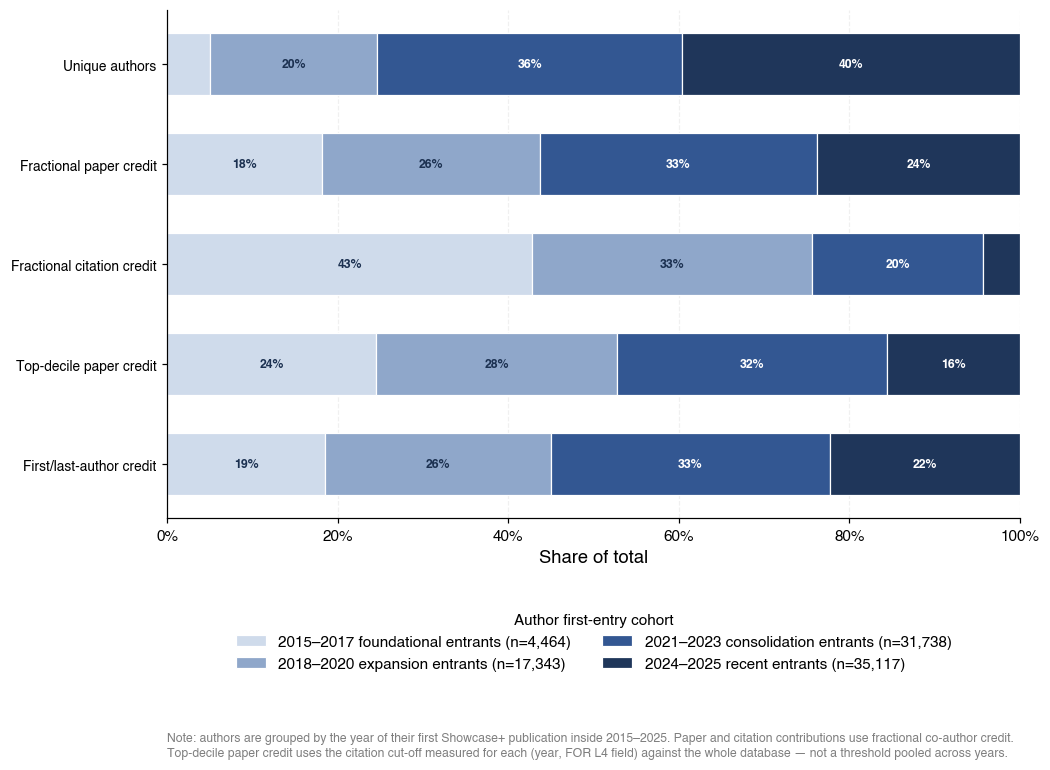


cohort shares (%), 2015-2025:

  Unique authors               2015–2017   5.0%  2018–2020  19.6%  2021–2023  35.8%  2024–2025  39.6%
  Fractional paper credit      2015–2017  18.1%  2018–2020  25.6%  2021–2023  32.5%  2024–2025  23.8%
  Fractional citation credit   2015–2017  42.8%  2018–2020  32.8%  2021–2023  20.1%  2024–2025   4.3%
  Top-decile paper credit      2015–2017  24.4%  2018–2020  28.3%  2021–2023  31.7%  2024–2025  15.6%
  First/last-author credit     2015–2017  18.5%  2018–2020  26.5%  2021–2023  32.7%  2024–2025  22.3%


In [25]:
# ============================================================
# 6. Candidate Fig. 3a — Author-entry cohort contribution profile
# ============================================================
# Was UK Biobank's impact produced mainly by early foundational contributors, or by
# successive waves of researchers entering the literature?
#
# READ THE TOP-DECILE ROW AGAINST ITS OWN HISTORY. Under the pooled FCR cut-off this
# notebook used before the reconcile, that row was substantially a measure of paper
# age and the earliest cohort dominated it by construction. It is now the measured
# per-(year, field) decile, so a 2024 paper is judged against 2024's bar and the row
# says something about the work rather than about the calendar.

cohort_author = author_summary[author_summary["entry_cohort"].isin(cohort_order)].copy()
cohort_author["entry_cohort"] = pd.Categorical(cohort_author["entry_cohort"],
                                               categories=cohort_order, ordered=True)
cohort_paper = author_paper[author_paper["entry_cohort"].isin(cohort_order)].copy()
cohort_paper["entry_cohort"] = pd.Categorical(cohort_paper["entry_cohort"],
                                              categories=cohort_order, ordered=True)

_by_author = cohort_author.groupby("entry_cohort", observed=True)
_by_paper = cohort_paper.groupby("entry_cohort", observed=True)
unique_author_counts = _by_author["author_key"].nunique()

contrib = pd.DataFrame({
    "Unique authors": unique_author_counts,
    "Fractional paper credit": _by_paper["fractional_paper_credit"].sum(),
    "Fractional citation credit": _by_paper["fractional_citation_credit"].sum(),
    "Top-decile paper credit": _by_paper["fractional_top_decile_credit"].sum(),
    "First/last-author credit": _by_paper["leadership_author_credit"].sum(),
}).T
contrib = contrib[cohort_order].fillna(0)
contrib_share = contrib.div(contrib.sum(axis=1), axis=0)

contrib_share.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_shares.csv")
contrib.to_csv(TABLE_DIR / "fig3a_author_entry_cohort_contribution_raw.csv")

display(contrib.round(2))
display((100 * contrib_share).round(1))

fig, ax = plt.subplots(figsize=STYLE["figsize_small"])
y = np.arange(len(contrib_share.index))
left = np.zeros(len(contrib_share))

for i, cohort in enumerate(cohort_order):
    vals = contrib_share[cohort].values
    ax.barh(y, vals, left=left, height=0.62, color=cohort_palette[i],
            edgecolor="white", linewidth=0.8, label=cohort.replace("\n", " "))
    for yi, x0, v in zip(y, left, vals):
        if v >= 0.065:
            ax.text(x0 + v / 2, yi, f"{100 * v:.0f}%", ha="center", va="center",
                    fontsize=STYLE["annot_fs"] - 1,
                    color="white" if i >= 2 else INK, fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(contrib_share.index, fontsize=STYLE["annot_fs"])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Share of total")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
set_title(ax, f"Author-entry cohorts and academic impact in the UK Biobank literature "
             f"({ANALYSIS_MIN}–{ANALYSIS_MAX})",
             loc="left", fontsize=STYLE["title_fs"])
ax.grid(axis="x", color="#E6E6E6", linewidth=0.8)
ax.set_axisbelow(True)

cohort_ns = unique_author_counts.reindex(cohort_order).fillna(0).astype(int)
handles, _ = ax.get_legend_handles_labels()
# Legend then note, both in AXES fractions: laid out in figure coordinates they were
# positioned independently of the axes height and the note met the legend title.
ax.legend(handles,
          [f"{c.replace(chr(10), ' ')} (n={cohort_ns[c]:,})" for c in cohort_order],
          loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False,
          title="Author first-entry cohort", fontsize=STYLE["legend_fs"])

ax.annotate(
         ("Note: authors are grouped by the year of their first Showcase+ publication "
          f"inside {ANALYSIS_MIN}–{ANALYSIS_MAX}. Paper and citation contributions use "
          "fractional co-author credit.\nTop-decile paper credit uses the citation "
          f"cut-off measured for each (year, FOR {FOR_LEVEL} field) against the whole "
          "database — not a threshold pooled across years."),
         (0, -0.42), xycoords="axes fraction",
         ha="left", va="top", fontsize=STYLE["annot_fs"] - 1, color=GREY)

savefig(fig, "fig3a_author_entry_cohort_academic_impact_profile")
plt.show()

print(f"\ncohort shares (%), {ANALYSIS_MIN}-{ANALYSIS_MAX}:\n")
for row in contrib_share.index:
    parts = "  ".join(f"{c.split(chr(10))[0]} {100 * contrib_share.loc[row, c]:5.1f}%"
                      for c in cohort_order)
    print(f"  {row:<28s} {parts}")


,author_name,ukb_influence_score,showcase_paper_count,fractional_paper_credit,fractional_citation_credit,showcase_h_index,mean_impact_metric,fractional_top_decile_credit,leadership_share,active_span_years
0,Rory Collins,98.633744,49,3.114371,1612.780772,25,23.721565,1.263811,0.102041,11
1,Peter Donnelly,98.438079,18,1.747667,698.974993,12,27.048916,1.056724,0.333333,10
2,Adrian Cortes,98.245934,22,2.015942,650.185372,12,22.819085,0.547656,0.227273,10
3,Lloyd T. Elliott,98.228677,17,1.604681,823.596046,11,28.638120,0.831918,0.235294,9
4,Paul M. Matthews,98.169193,61,5.964912,1165.968231,31,16.520300,1.820387,0.180328,11
5,Olivier Delaneau,98.161997,30,4.280384,907.610026,15,18.105128,1.631534,0.533333,11
6,Jonathan Marchini,98.154621,54,5.911600,1206.499822,26,16.329504,2.645017,0.277778,11
7,Naomi Allen,98.130146,102,12.215923,2283.794502,38,15.102137,3.574779,0.235294,11
8,Cathie Sudlow,98.108987,70,6.227241,1665.637156,35,15.084451,2.471749,0.271429,11
9,Christian Benner,98.041540,24,1.809263,337.970566,17,22.014204,0.860787,0.125000,9


saved output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.pdf


saved output/figures/data_analysis/03_academic_impact/fig_author_influence_fingerprint_heatmap.png


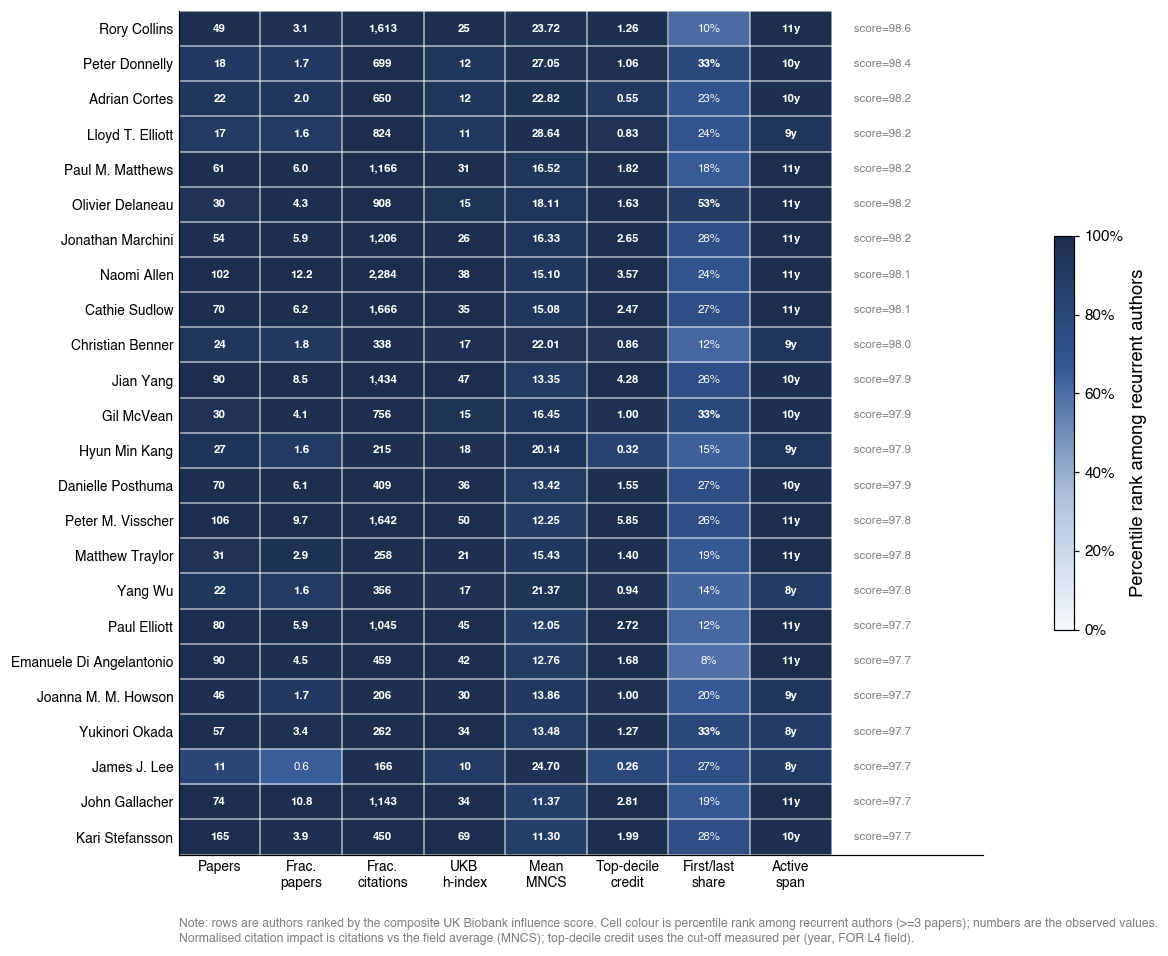

In [26]:
# ============================================================
# 8. Supplement — Influential-author fingerprint heatmap
# ============================================================
# A leaderboard says who is ahead; this says what each of them is ahead ON. Rows are
# the top authors by composite score, columns the dimensions that make them
# influential. Cell colour is the percentile rank among RECURRENT authors, so a cell
# is read against the field of contributors rather than against the 24 shown.

fingerprint_source = author_summary[author_summary["showcase_paper_count"] >= 3].copy()
if fingerprint_source.empty:
    fingerprint_source = author_summary.copy()

top_n = 24
fingerprint = author_summary.head(top_n).copy()

metric_specs = [
    # Every label is two lines. On one line "Frac. papers", "Frac. citations" and
    # "UKB h-index" run into each other at this column width.
    ("showcase_paper_count", "Papers", lambda x: f"{int(x):,}"),
    ("fractional_paper_credit", "Frac.\npapers", lambda x: f"{x:.1f}"),
    ("fractional_citation_credit", "Frac.\ncitations", lambda x: f"{x:,.0f}"),
    ("showcase_h_index", "UKB\nh-index", lambda x: f"{int(x):,}"),
    ("mean_impact_metric", f"Mean\n{IMPACT_SHORT}", lambda x: f"{x:.2f}"),
    # A sum of fractional credits, not a paper count: a paper top-decile in one of its
    # two fields contributes 0.5, shared again across its co-authors.
    ("fractional_top_decile_credit", "Top-decile\ncredit", lambda x: f"{x:.2f}"),
    ("leadership_share", "First/last\nshare", lambda x: f"{100 * x:.0f}%"),
    ("active_span_years", "Active\nspan", lambda x: f"{int(x)}y"),
]

norm_matrix, raw_text = [], []
for col, label, fmt in metric_specs:
    ranks = pct_rank_safe(fingerprint_source[col])
    rank_map = pd.Series(ranks.values, index=fingerprint_source["author_key"])
    norm_matrix.append(fingerprint["author_key"].map(rank_map).fillna(0).values)
    raw_text.append([fmt(v) if pd.notna(v) else "" for v in fingerprint[col].values])

norm_matrix = np.array(norm_matrix).T
raw_text = np.array(raw_text).T

fingerprint[["author_name", "ukb_influence_score"] + [m[0] for m in metric_specs]].to_csv(
    TABLE_DIR / "fig_author_influence_fingerprint_top_authors.csv", index=False)

display(fingerprint[["author_name", "ukb_influence_score"]
                    + [m[0] for m in metric_specs]].head(top_n))

fig_height = max(7.2, 0.34 * len(fingerprint) + 1.8)
fig, ax = plt.subplots(figsize=(10.5, fig_height))

im = ax.imshow(norm_matrix, aspect="auto", cmap=UKB_SEQ, vmin=0, vmax=1)

ax.set_yticks(np.arange(len(fingerprint)))
ax.set_yticklabels(fingerprint["author_name"].fillna(""), fontsize=STYLE["annot_fs"])
ax.set_xticks(np.arange(len(metric_specs)))
ax.set_xticklabels([m[1] for m in metric_specs], rotation=0, ha="center",
                   fontsize=STYLE["annot_fs"])

for i in range(norm_matrix.shape[0]):
    for j in range(norm_matrix.shape[1]):
        val = norm_matrix[i, j]
        ax.text(j, i, raw_text[i, j], ha="center", va="center",
                fontsize=STYLE["annot_fs"] - 1.5,
                color="white" if val > 0.58 else INK,
                fontweight="bold" if val > 0.78 else "normal")

# Thin white cell boundaries.
ax.set_xticks(np.arange(-0.5, len(metric_specs), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(fingerprint), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0)

set_title(ax, f"Multidimensional influence profile of leading UK Biobank contributors "
             f"({ANALYSIS_MIN}–{ANALYSIS_MAX})",
             loc="left", fontsize=STYLE["title_fs"])
ax.set_xlim(-0.5, len(metric_specs) + 1.35)

for i, (_, r) in enumerate(fingerprint.iterrows()):
    ax.text(len(metric_specs) - 0.35, i, f"   score={r['ukb_influence_score']:.1f}",
            ha="left", va="center", fontsize=STYLE["annot_fs"] - 1.5, color=GREY)

cbar = fig.colorbar(im, ax=ax, fraction=0.022, pad=0.08)
cbar.set_label("Percentile rank among recurrent authors")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Anchored on the AXES, not the figure: at fig y=-0.045 the note sat an inch and a
# half below a 24-row panel and tight-bbox kept all of that whitespace.
ax.annotate(
         ("Note: rows are authors ranked by the composite UK Biobank influence score. "
          "Cell colour is percentile rank among recurrent authors (>=3 papers); "
          "numbers are the observed values.\nNormalised citation impact is "
          f"{IMPACT_LABEL} ({IMPACT_SHORT}); top-decile credit uses the cut-off "
          f"measured per (year, FOR {FOR_LEVEL} field)."),
         (0, -0.075), xycoords="axes fraction",
         ha="left", va="top", fontsize=STYLE["annot_fs"] - 1, color=GREY)

savefig(fig, "fig_author_influence_fingerprint_heatmap")
plt.show()


---

## Execution boundary before Part 3: Showcase+ citation diagnostics

The following reset deliberately reproduces the fresh Python kernel used by the former
`03_academic_impact_02_citation_extra.ipynb` while leaving files written by earlier parts available to this one.


In [27]:
# Reproduce the clean-kernel boundary that separated the source notebooks.
try:
    import matplotlib as _boundary_mpl
    import matplotlib.pyplot as _boundary_plt
    _boundary_plt.close("all")
    _boundary_mpl.rcdefaults()
except ImportError:
    pass

import warnings as _boundary_warnings
_boundary_warnings.resetwarnings()

from IPython import get_ipython as _boundary_get_ipython
_boundary_get_ipython().run_line_magic("reset", "-f")


# Part III: Showcase+ citation and disciplinary figures

This notebook makes the disciplinary and citation figures from the publication-level full-endpoint parquet. It does not run BERTopic and does not depend on any topic-model cache.

The input is the repository's `showcase_plus_all_endpoints_wide.parquet`. The analysis uses its publication fields only, so every figure is calculated from the same one-row-per-paper table. Figures are shown in the notebook and saved under `output/non_topic_figures/` as PNG and PDF files; the tables behind them are saved as CSV files. Set `UKB_FULL_ENDPOINT_PARQUET` or `UKB_NON_TOPIC_OUTPUT` to override these paths.

Topic waves and other BERTopic outputs are deliberately kept in the topic notebook. The earlier source-route comparison is also omitted because `source_route` is not a field in the full-endpoint parquet and would require a second input table. The former leading-publication-venues chart is now Figure 5H, built from the same Showcase+ fields by `05_author_characteristics.ipynb`; it is not duplicated here.


## 1. set the input




In [28]:
from pathlib import Path
import os
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
from utils.shared_style import PNG_DPI
from utils.shared_style import apply_typography, finalize_figure, set_title
apply_typography()
from utils.shared_analysis_window import ANALYSIS_START_DATE, ANALYSIS_START_YEAR, ANALYSIS_END_DATE, ANALYSIS_END_YEAR, filter_analysis_window
P.bootstrap()

PARQUET_PATH = Path(
    os.environ.get(
        "UKB_FULL_ENDPOINT_PARQUET",
        P.SHOWCASE_PLUS,
    )
).expanduser()
OUTPUT_DIR = Path(
    os.environ.get(
        "UKB_NON_TOPIC_OUTPUT",
        P.OUTPUT / "non_topic_figures",
    )
).expanduser()
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        f"Full-endpoint parquet not found: {PARQUET_PATH}\n"
        "Set UKB_FULL_ENDPOINT_PARQUET to the full-endpoint parquet, then rerun."
    )

for directory in (FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Input: {PARQUET_PATH}")
print(f"Figures: {FIGURE_DIR}")
print(f"Tables: {TABLE_DIR}")


Input: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/twenty_years_of_ukb/data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
Figures: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/twenty_years_of_ukb/output/non_topic_figures/figures
Tables: /home/jinx/CharlieRahal Dropbox/Charlie RAHAL/twenty_years_of_ukb/output/non_topic_figures/tables


## 2. Analysis settings and shared style

Publications are included from 1 January 2013 through 31 December 2025. The August 2026 citation snapshot remains separate from that publication cutoff and is used to calculate citations per year.


In [29]:
import ast
import json
import re
from textwrap import wrap

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

MIN_YEAR = ANALYSIS_START_YEAR
MAX_YEAR = ANALYSIS_END_YEAR
CITATION_SNAPSHOT_YEAR = 2026
TOP_N = 15

COLOUR = {
    "blue_dark": "#344874",
    "gold": "#FFBB00",
    "blue": "#5B8DB8",
    "teal": "#2A9D8F",
    "coral": "#E76F51",
    "purple": "#8E6C9E",
    "grey_dark": "#3A3A3A",
    "grey": "#777777",
    "grey_light": "#E8E8E8",
}

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 600,
    "font.family": "Helvetica",
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.3,
    "ytick.labelsize": 9.3,
    "legend.fontsize": 8.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
apply_typography()

field_cmap = LinearSegmentedColormap.from_list(
    "ukb_field", ["#E4F3EF", COLOUR["teal"], "#17645D"]
)


## 3. Load the publication table

Only the columns needed below are read from the wide parquet. Duplicate publication IDs are checked and collapsed before analysis, so one paper cannot be counted twice because of the endpoint merge.


In [30]:
PUBLICATION_COLUMNS = [
    "id",
    "title",
    "year",
    "date",
    "times_cited",
    "field_citation_ratio",
    "relative_citation_ratio",
    "category_for_2020",
]

papers = pd.read_parquet(PARQUET_PATH, columns=PUBLICATION_COLUMNS)

missing = [column for column in PUBLICATION_COLUMNS if column not in papers.columns]
if missing:
    raise ValueError(f"The parquet is missing required publication columns: {missing}")

input_rows = len(papers)
duplicate_ids = int(papers["id"].duplicated(keep=False).sum())
papers = papers.drop_duplicates(subset="id", keep="first").copy()

papers["year"] = pd.to_numeric(papers["year"], errors="coerce")
papers["times_cited"] = pd.to_numeric(papers["times_cited"], errors="coerce").fillna(0)
papers["field_citation_ratio"] = pd.to_numeric(
    papers["field_citation_ratio"], errors="coerce"
)
papers["relative_citation_ratio"] = pd.to_numeric(
    papers["relative_citation_ratio"], errors="coerce"
)

analysis_papers = filter_analysis_window(papers)
analysis_papers = analysis_papers[analysis_papers["year"].between(MIN_YEAR, MAX_YEAR)].copy()
analysis_papers["year"] = analysis_papers["year"].astype(int)
analysis_papers["citation_age_years"] = (
    CITATION_SNAPSHOT_YEAR - analysis_papers["year"] + 1
).clip(lower=1)
analysis_papers["citations_per_year"] = (
    analysis_papers["times_cited"] / analysis_papers["citation_age_years"]
)

if analysis_papers.empty:
    raise ValueError("No eligible publication rows remain after the year checks.")

print(f"Rows read: {input_rows:,}")
print(f"Duplicate-ID rows found: {duplicate_ids:,}")
print(f"Unique publications: {len(papers):,}")
print(
    f"Complete-year analysis set: {len(analysis_papers):,} "
    f"({analysis_papers['year'].min()}-{analysis_papers['year'].max()})"
)
display(analysis_papers.head(3))


Rows read: 26,109
Duplicate-ID rows found: 0
Unique publications: 26,109
Complete-year analysis set: 23,442 (2013-2025)


,id,title,year,date,times_cited,field_citation_ratio,relative_citation_ratio,category_for_2020,citation_age_years,citations_per_year
0,pub.1000169743,Ethnic-Specific Obesity Cutoffs for Diabetes R...,2014,2014-08-07,223,32.97,5.16,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",13,17.153846
1,pub.1000305094,Data science for mental health: a UK perspecti...,2016,2016-10-01,56,8.91,1.36,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,5.090909
2,pub.1001609820,"Ambient air pollution, traffic noise and adult...",2016,2016-10-20,73,22.92,2.67,"[{""id"":""80003"",""name"":""32 Biomedical and Clini...",11,6.636364


## 4. Prepare journal and Field of Research values

Dimensions stores journals and Fields of Research as JSON-like values. This cell turns them into ordinary labels. Four-digit FoR 2020 groups are used for the field plots. When a paper has several groups, its weight is split equally between them rather than counted several times.


In [31]:
def parse_json_like(value):
    if isinstance(value, (list, dict)):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "null"}:
        return None
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return text


def four_digit_for_groups(value):
    parsed = parse_json_like(value)
    if isinstance(parsed, dict):
        parsed = [parsed]
    if not isinstance(parsed, list):
        return []

    groups = {}
    for item in parsed:
        if isinstance(item, dict):
            name = str(item.get("name") or item.get("title") or "").strip()
        else:
            name = str(item).strip()
        match = re.match(r"^(\d{4})\s+(.+)$", name)
        if match:
            groups[match.group(1)] = match.group(2).strip()
    return sorted(groups.items())


def wrapped(text, width=38):
    return "\n".join(wrap(str(text), width=width))


def save_figure(figure, stem):
    finalize_figure(figure)
    for extension in ("png", "pdf"):
        figure.savefig(
            FIGURE_DIR / f"{stem}.{extension}",
            bbox_inches="tight",
            facecolor="white",
            **({"dpi": PNG_DPI} if extension == "png" else {}),
        )
    print(f"Saved: {P.raw_path(FIGURE_DIR / (stem + '.png'))}")


for_rows = []
for row in analysis_papers[
    ["id", "year", "times_cited", "category_for_2020"]
].itertuples(index=False):
    groups = four_digit_for_groups(row.category_for_2020)
    if not groups:
        continue
    weight = 1.0 / len(groups)
    for code_value, field_name in groups:
        for_rows.append({
            "id": row.id,
            "year": row.year,
            "times_cited": row.times_cited,
            "for_code": code_value,
            "for_name": field_name,
            "fractional_papers": weight,
            "fractional_citations": row.times_cited * weight,
        })

for_long = pd.DataFrame(for_rows)
if for_long.empty:
    raise ValueError("No four-digit FoR 2020 assignments could be parsed.")

print(f"Papers with a four-digit FoR group: {for_long['id'].nunique():,}")
print(f"Distinct four-digit FoR groups: {for_long['for_code'].nunique():,}")


Papers with a four-digit FoR group: 22,793
Distinct four-digit FoR groups: 113


## 5. Disciplinary composition

This first plot shows where Showcase+ papers sit across the four-digit FoR 2020 groups. Fractional counting keeps the total contribution of each paper at one even when Dimensions assigns it to several fields.


Saved: output/non_topic_figures/figures/fig01_disciplinary_composition.png


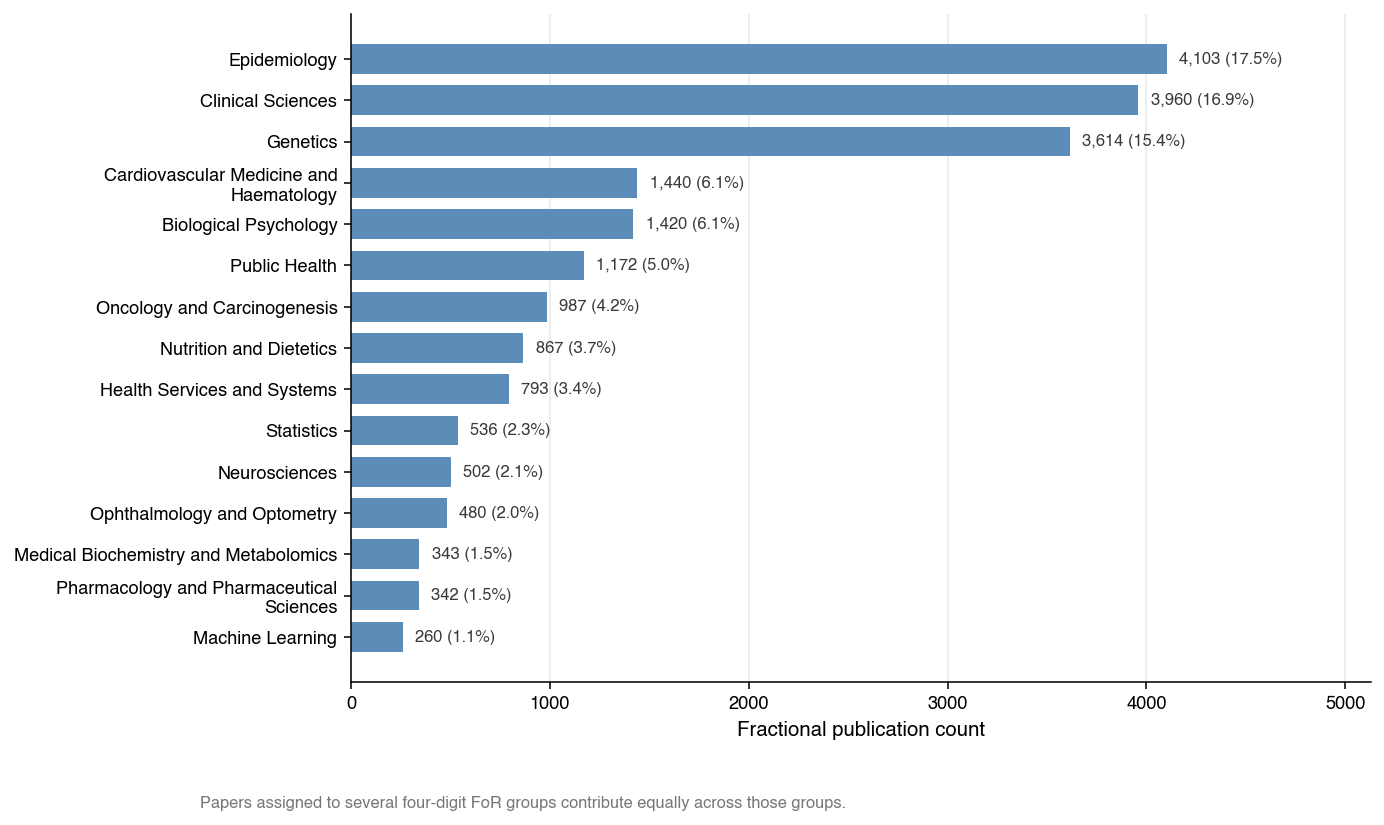

,for_code,for_name,fractional_paper_count,papers,percent_of_corpus
69,4202,Epidemiology,4102.916667,6279,17.502417
15,3202,Clinical Sciences,3959.750000,5467,16.891690
10,3105,Genetics,3614.250000,5328,15.417840
14,3201,Cardiovascular Medicine and Haematology,1439.666667,1906,6.141399
109,5202,Biological Psychology,1419.916667,2245,6.057148
73,4206,Public Health,1172.333333,1880,5.000995
24,3211,Oncology and Carcinogenesis,986.750000,1360,4.209325
23,3210,Nutrition and Dietetics,867.166667,1115,3.699201
70,4203,Health Services and Systems,793.166667,1213,3.383528
103,4905,Statistics,535.833333,1140,2.285783


In [32]:
discipline_summary = (
    for_long.groupby(["for_code", "for_name"], as_index=False)
    .agg(
        fractional_paper_count=("fractional_papers", "sum"),
        papers=("id", "nunique"),
    )
)
discipline_summary["percent_of_corpus"] = (
    100 * discipline_summary["fractional_paper_count"] / analysis_papers["id"].nunique()
)

discipline_plot = (
    discipline_summary.nlargest(TOP_N, "fractional_paper_count")
    .sort_values("fractional_paper_count")
    .copy()
)

figure, axis = plt.subplots(figsize=(9.4, 6.2))
bars = axis.barh(
    np.arange(len(discipline_plot)),
    discipline_plot["fractional_paper_count"],
    color=COLOUR["blue"],
    height=0.72,
)
axis.set_yticks(np.arange(len(discipline_plot)))
axis.set_yticklabels(discipline_plot["for_name"].map(wrapped))
axis.set_xlabel("Fractional publication count")
set_title(axis, "Disciplinary composition of Showcase+ publications")
axis.grid(axis="x", color=COLOUR["grey_light"], linewidth=0.8)
axis.set_axisbelow(True)

maximum = discipline_plot["fractional_paper_count"].max()
axis.set_xlim(0, maximum * 1.25)
for bar, row in zip(bars, discipline_plot.itertuples(index=False)):
    axis.text(
        bar.get_width() + maximum * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row.fractional_paper_count:,.0f} ({row.percent_of_corpus:.1f}%)",
        va="center",
        fontsize=8.5,
        color=COLOUR["grey_dark"],
    )

figure.text(
    0.01,
    -0.035,
    "Papers assigned to several four-digit FoR groups contribute equally across those groups.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig01_disciplinary_composition")
plt.show()

discipline_summary.sort_values(
    "fractional_paper_count", ascending=False
).to_csv(TABLE_DIR / "fig01_disciplinary_composition.csv", index=False)
display(discipline_summary.nlargest(TOP_N, "fractional_paper_count"))


## 6. Cumulative publication output and citation stock

This plot places publication growth and citation impact on the same percentage scale. It uses the current citation count attached to each paper, grouped by publication year; it is not a historical record of how many citations existed in each calendar year.


Saved: output/non_topic_figures/figures/fig02_cumulative_output_and_citation_stock.png


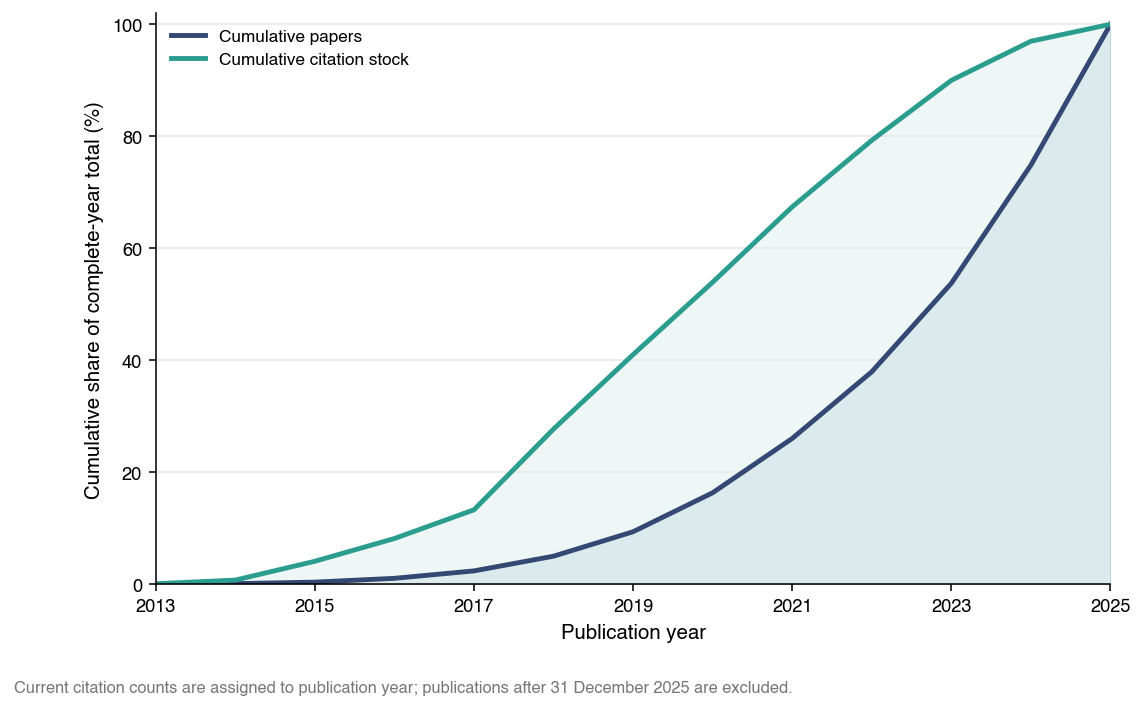

,year,papers,citations,cumulative_papers,cumulative_citations,cumulative_paper_share,cumulative_citation_share
0,2013,5,792,5,792,0.021329,0.118133
1,2014,27,4377,32,5169,0.136507,0.771000
2,2015,63,22511,95,27680,0.405256,4.128706
3,2016,160,27235,255,54915,1.087791,8.191036
4,2017,310,34371,565,89286,2.410204,13.317761
5,2018,616,96627,1181,185913,5.037966,27.730495
6,2019,1023,89144,2204,275057,9.401928,41.027075
7,2020,1631,86615,3835,361672,16.359526,53.946434
8,2021,2273,90212,6108,451884,26.055797,67.402316
9,2022,2792,79627,8900,531511,37.966044,79.279356


In [33]:
yearly = (
    analysis_papers.groupby("year", as_index=False)
    .agg(
        papers=("id", "nunique"),
        citations=("times_cited", "sum"),
    )
    .sort_values("year")
)
yearly["cumulative_papers"] = yearly["papers"].cumsum()
yearly["cumulative_citations"] = yearly["citations"].cumsum()
yearly["cumulative_paper_share"] = (
    100 * yearly["cumulative_papers"] / yearly["cumulative_papers"].iloc[-1]
)
yearly["cumulative_citation_share"] = (
    100 * yearly["cumulative_citations"] / yearly["cumulative_citations"].iloc[-1]
)

figure, axis = plt.subplots(figsize=(8.8, 5.3))
axis.plot(
    yearly["year"], yearly["cumulative_paper_share"],
    color=COLOUR["blue_dark"], linewidth=2.5, label="Cumulative papers",
)
axis.plot(
    yearly["year"], yearly["cumulative_citation_share"],
    color=COLOUR["teal"], linewidth=2.5, label="Cumulative citation stock",
)
axis.fill_between(
    yearly["year"], 0, yearly["cumulative_paper_share"],
    color=COLOUR["blue"], alpha=0.12,
)
axis.fill_between(
    yearly["year"], 0, yearly["cumulative_citation_share"],
    color=COLOUR["teal"], alpha=0.08,
)
axis.set_xlim(yearly["year"].min(), yearly["year"].max())
axis.set_ylim(0, 102)
axis.set_xticks(np.arange(yearly["year"].min(), yearly["year"].max() + 1, 2))
axis.set_xlabel("Publication year")
axis.set_ylabel("Cumulative share of complete-year total (%)")
set_title(axis, "Cumulative Showcase+ output and citation stock")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
axis.legend(frameon=False, loc="upper left")

figure.text(
    0.01,
    -0.035,
    f"Current citation counts are assigned to publication year; publications after {ANALYSIS_END_DATE:%d %B %Y} are excluded.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig02_cumulative_output_and_citation_stock")
plt.show()

yearly.to_csv(TABLE_DIR / "fig02_cumulative_output_and_citation_stock.csv", index=False)
display(yearly)


## 7. Citation impact by Field of Research

The same fractional rule is used for citations: if a paper belongs to two four-digit FoR groups, each receives half of that paper's citation count. The bars therefore show how citation impact is distributed without inflating the overall total.


Saved: output/non_topic_figures/figures/fig04_field_citation_impact.png


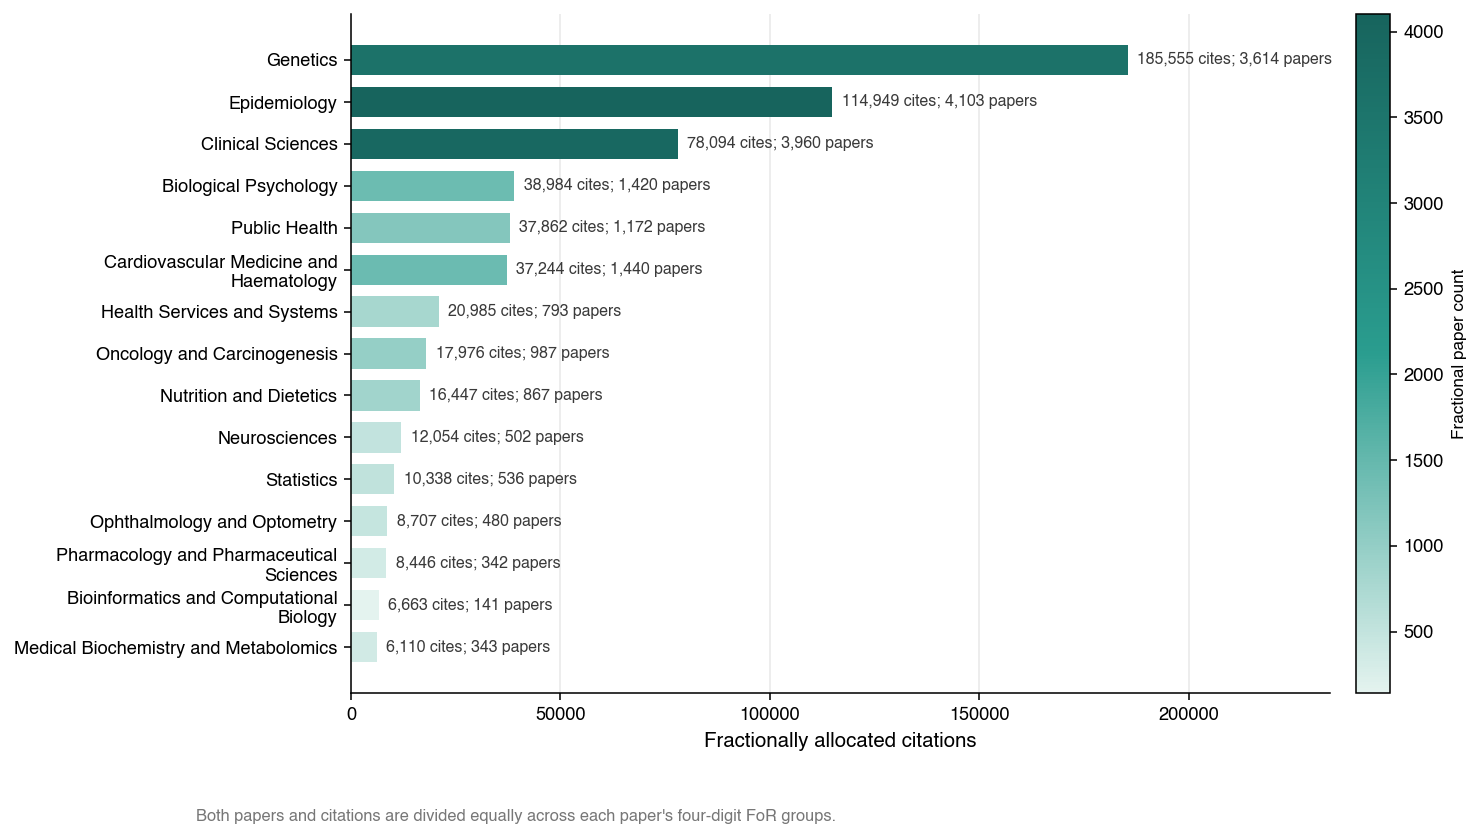

,for_code,for_name,fractional_papers,papers,fractional_citations,citations_per_fractional_paper
10,3105,Genetics,3614.250000,5328,185554.583333,51.339720
69,4202,Epidemiology,4102.916667,6279,114949.250000,28.016472
15,3202,Clinical Sciences,3959.750000,5467,78093.666667,19.721868
109,5202,Biological Psychology,1419.916667,2245,38983.833333,27.455015
73,4206,Public Health,1172.333333,1880,37862.500000,32.296702
14,3201,Cardiovascular Medicine and Haematology,1439.666667,1906,37243.500000,25.869530
70,4203,Health Services and Systems,793.166667,1213,20985.250000,26.457554
24,3211,Oncology and Carcinogenesis,986.750000,1360,17976.250000,18.217634
23,3210,Nutrition and Dietetics,867.166667,1115,16446.750000,18.966077
22,3209,Neurosciences,502.500000,1114,12054.166667,23.988391


In [34]:
field_impact = (
    for_long.groupby(["for_code", "for_name"], as_index=False)
    .agg(
        fractional_papers=("fractional_papers", "sum"),
        papers=("id", "nunique"),
        fractional_citations=("fractional_citations", "sum"),
    )
)
field_impact["citations_per_fractional_paper"] = (
    field_impact["fractional_citations"] / field_impact["fractional_papers"]
)

field_plot = (
    field_impact.nlargest(TOP_N, "fractional_citations")
    .sort_values("fractional_citations")
    .copy()
)
normaliser = Normalize(
    field_plot["fractional_papers"].min(),
    field_plot["fractional_papers"].max(),
)

figure, axis = plt.subplots(figsize=(9.6, 6.3))
bars = axis.barh(
    np.arange(len(field_plot)),
    field_plot["fractional_citations"],
    color=field_cmap(normaliser(field_plot["fractional_papers"])),
    height=0.72,
)
axis.set_yticks(np.arange(len(field_plot)))
axis.set_yticklabels(field_plot["for_name"].map(wrapped))
axis.set_xlabel("Fractionally allocated citations")
set_title(axis, "Leading Fields of Research by citation impact")
axis.grid(axis="x", color=COLOUR["grey_light"], linewidth=0.8)
axis.set_axisbelow(True)

maximum = field_plot["fractional_citations"].max()
axis.set_xlim(0, maximum * 1.26)
for bar, row in zip(bars, field_plot.itertuples(index=False)):
    axis.text(
        bar.get_width() + maximum * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{row.fractional_citations:,.0f} cites; {row.fractional_papers:,.0f} papers",
        va="center",
        fontsize=8.2,
        color=COLOUR["grey_dark"],
    )

mapper = ScalarMappable(norm=normaliser, cmap=field_cmap)
mapper.set_array([])
colour_bar = figure.colorbar(mapper, ax=axis, fraction=0.035, pad=0.025)
colour_bar.set_label("Fractional paper count", fontsize=8.8)
figure.text(
    0.01,
    -0.035,
    "Both papers and citations are divided equally across each paper's four-digit FoR groups.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig04_field_citation_impact")
plt.show()

field_impact.sort_values("fractional_citations", ascending=False).to_csv(
    TABLE_DIR / "fig04_field_citation_impact.csv", index=False
)
display(field_impact.nlargest(TOP_N, "fractional_citations"))


## 8. Citation concentration

This curve orders papers from most to least cited. It answers a straightforward question: what share of all citations is carried by the top 1%, 5%, 10%, and so on? The diagonal is the equal-share reference.


Saved: output/non_topic_figures/figures/fig05_citation_concentration.png


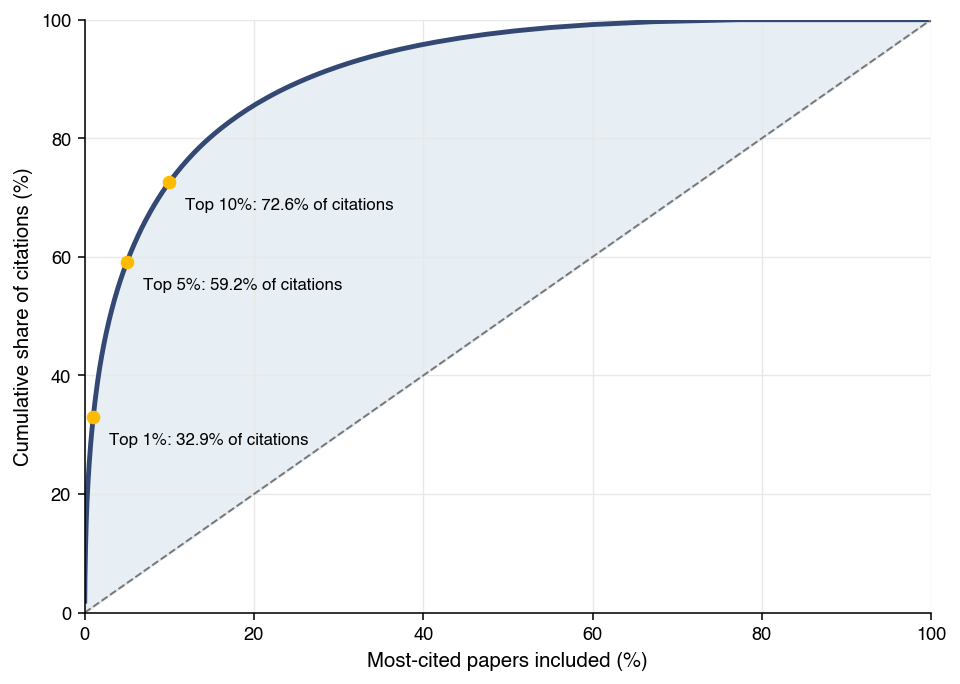

,top_paper_percent,citation_percent
0,1,32.949847
1,5,59.201137
2,10,72.615851
3,20,85.559971
4,50,97.987107


In [35]:
ordered_citations = analysis_papers["times_cited"].clip(lower=0).sort_values(
    ascending=False
).reset_index(drop=True)
total_citations = ordered_citations.sum()
if total_citations <= 0:
    raise ValueError("Citation concentration cannot be calculated because all counts are zero.")

concentration = pd.DataFrame({
    "top_paper_share": 100 * np.arange(1, len(ordered_citations) + 1) / len(ordered_citations),
    "citation_share": 100 * ordered_citations.cumsum() / total_citations,
})

checkpoints = []
for top_share in (1, 5, 10, 20, 50):
    index = max(0, int(np.ceil(len(ordered_citations) * top_share / 100)) - 1)
    checkpoints.append({
        "top_paper_percent": top_share,
        "citation_percent": concentration.iloc[index]["citation_share"],
    })
checkpoint_table = pd.DataFrame(checkpoints)

figure, axis = plt.subplots(figsize=(7.8, 5.5))
axis.plot(
    concentration["top_paper_share"],
    concentration["citation_share"],
    color=COLOUR["blue_dark"],
    linewidth=2.5,
)
axis.fill_between(
    concentration["top_paper_share"],
    concentration["citation_share"],
    concentration["top_paper_share"],
    where=concentration["citation_share"].ge(concentration["top_paper_share"]),
    color=COLOUR["blue"],
    alpha=0.14,
)
axis.plot([0, 100], [0, 100], color=COLOUR["grey"], linestyle="--", linewidth=1)

for row in checkpoint_table.itertuples(index=False):
    if row.top_paper_percent in {1, 5, 10}:
        axis.scatter(row.top_paper_percent, row.citation_percent, color=COLOUR["gold"], zorder=3)
        axis.annotate(
            f"Top {row.top_paper_percent}%: {row.citation_percent:.1f}% of citations",
            (row.top_paper_percent, row.citation_percent),
            xytext=(8, -14),
            textcoords="offset points",
            fontsize=8.6,
        )

axis.set_xlim(0, 100)
axis.set_ylim(0, 100)
axis.set_xlabel("Most-cited papers included (%)")
axis.set_ylabel("Cumulative share of citations (%)")
set_title(axis, "Concentration of citations across Showcase+ papers")
axis.grid(color=COLOUR["grey_light"], linewidth=0.7)
save_figure(figure, "fig05_citation_concentration")
plt.show()

concentration.to_csv(TABLE_DIR / "fig05_citation_concentration_curve.csv", index=False)
checkpoint_table.to_csv(TABLE_DIR / "fig05_citation_concentration_checkpoints.csv", index=False)
display(checkpoint_table)


## 9. Age-adjusted citation impact by publication cohort

Older papers have had more time to collect citations. To make broad cohorts easier to compare, each paper's current citation count is divided by the number of years since publication. The distributions are still descriptive: this adjustment handles exposure time, not differences between research fields.


Saved: output/non_topic_figures/figures/fig06_age_adjusted_citation_cohorts.png


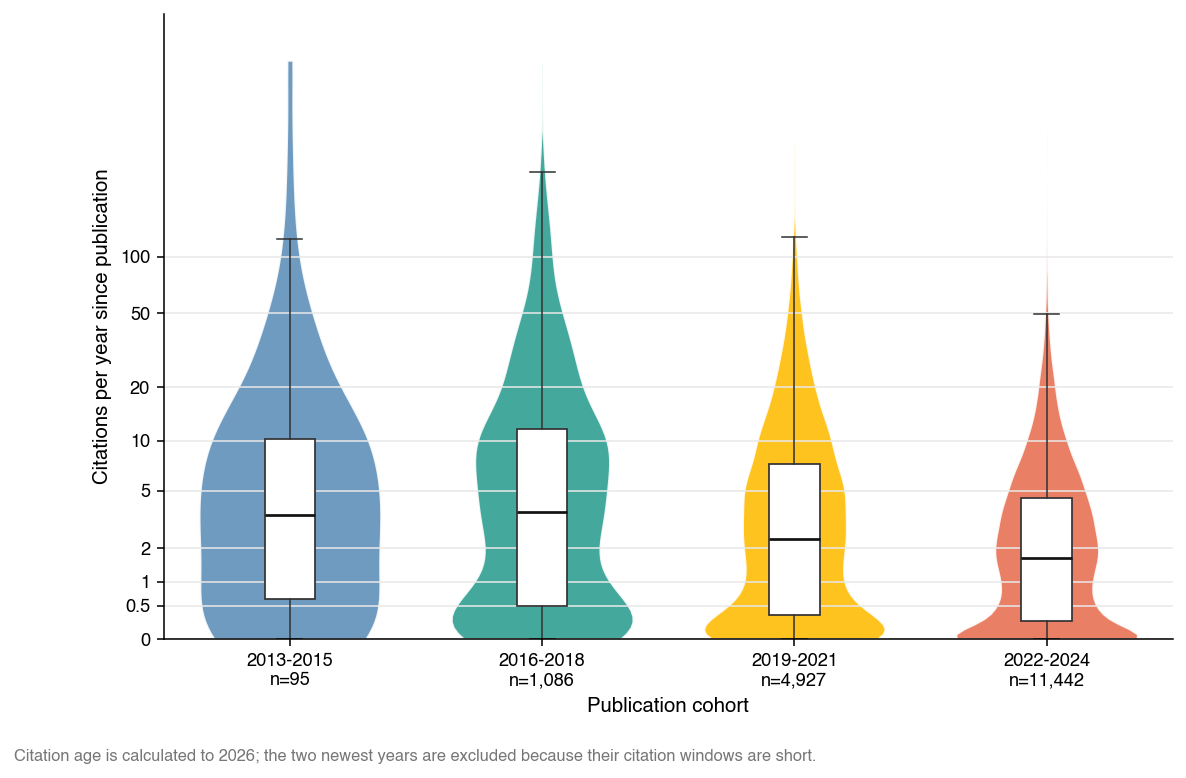

,cohort,papers,median_citations_per_year,p90_citations_per_year,top_decile_share
0,2013-2015,95,3.461538,31.476923,20.000000
1,2016-2018,1086,3.666667,34.590909,22.836096
2,2019-2021,4927,2.333333,18.166667,14.633651
3,2022-2024,11442,1.666667,9.800000,6.921867


In [36]:
IMPACT_MAX_YEAR = CITATION_SNAPSHOT_YEAR - 2
cohort_papers = analysis_papers[analysis_papers["year"].le(IMPACT_MAX_YEAR)].copy()
cohort_papers["log_citations_per_year"] = np.log10(
    cohort_papers["citations_per_year"] + 1
)

cohort_edges = list(range(MIN_YEAR, IMPACT_MAX_YEAR + 2, 3))
if cohort_edges[-1] <= IMPACT_MAX_YEAR:
    cohort_edges.append(IMPACT_MAX_YEAR + 1)
cohort_labels = [
    f"{start}-{end - 1}" for start, end in zip(cohort_edges[:-1], cohort_edges[1:])
]
cohort_papers["cohort"] = pd.cut(
    cohort_papers["year"],
    bins=cohort_edges,
    labels=cohort_labels,
    right=False,
    include_lowest=True,
)

top_decile_threshold = cohort_papers["citations_per_year"].quantile(0.90)
cohort_summary = (
    cohort_papers.dropna(subset=["cohort"])
    .groupby("cohort", observed=True)
    .agg(
        papers=("id", "nunique"),
        median_citations_per_year=("citations_per_year", "median"),
        p90_citations_per_year=("citations_per_year", lambda values: values.quantile(0.90)),
        top_decile_share=("citations_per_year", lambda values: 100 * values.ge(top_decile_threshold).mean()),
    )
    .reset_index()
)

plot_labels = cohort_summary["cohort"].astype(str).tolist()
plot_values = [
    cohort_papers.loc[
        cohort_papers["cohort"].astype(str).eq(label),
        "log_citations_per_year",
    ].dropna().to_numpy()
    for label in plot_labels
]
positions = np.arange(len(plot_values))

figure, axis = plt.subplots(figsize=(9.3, 5.8))
violins = axis.violinplot(
    plot_values,
    positions=positions,
    widths=0.72,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
palette = [COLOUR["blue"], COLOUR["teal"], COLOUR["gold"], COLOUR["coral"], COLOUR["purple"]]
for body, colour in zip(violins["bodies"], palette):
    body.set_facecolor(colour)
    body.set_edgecolor("white")
    body.set_alpha(0.88)

axis.boxplot(
    plot_values,
    positions=positions,
    widths=0.20,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#111111", "linewidth": 1.4},
    boxprops={"facecolor": "white", "edgecolor": "#333333", "linewidth": 0.9},
    whiskerprops={"color": "#333333", "linewidth": 0.8},
    capprops={"color": "#333333", "linewidth": 0.8},
)

axis.set_xticks(positions)
axis.set_xticklabels([
    f"{row.cohort}\nn={row.papers:,}" for row in cohort_summary.itertuples(index=False)
])
raw_ticks = np.array([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
log_ticks = np.log10(raw_ticks + 1)
upper_limit = max(np.nanmax(values) for values in plot_values) * 1.08
keep = log_ticks <= upper_limit
axis.set_yticks(log_ticks[keep])
axis.set_yticklabels([f"{value:g}" for value in raw_ticks[keep]])
axis.set_ylim(0, upper_limit)
axis.set_xlabel("Publication cohort")
axis.set_ylabel("Citations per year since publication")
set_title(axis, "Age-adjusted citation impact by publication cohort")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
figure.text(
    0.01,
    -0.04,
    f"Citation age is calculated to {CITATION_SNAPSHOT_YEAR}; the two newest years are excluded because their citation windows are short.",
    fontsize=8.4,
    color=COLOUR["grey"],
)
save_figure(figure, "fig06_age_adjusted_citation_cohorts")
plt.show()

cohort_summary.to_csv(TABLE_DIR / "fig06_age_adjusted_citation_cohorts.csv", index=False)
display(cohort_summary)


## 10. Field-normalised citation performance

Field Citation Ratio is available for many, but not all, publications. A value of one is the Dimensions benchmark; values above one indicate citation performance above that benchmark. The curve shows the full distribution rather than reducing it to a single mean. If FCR is unavailable in a future export, the cell falls back to RCR and then to citations per year.


Saved: output/non_topic_figures/figures/fig07_normalised_citation_performance.png


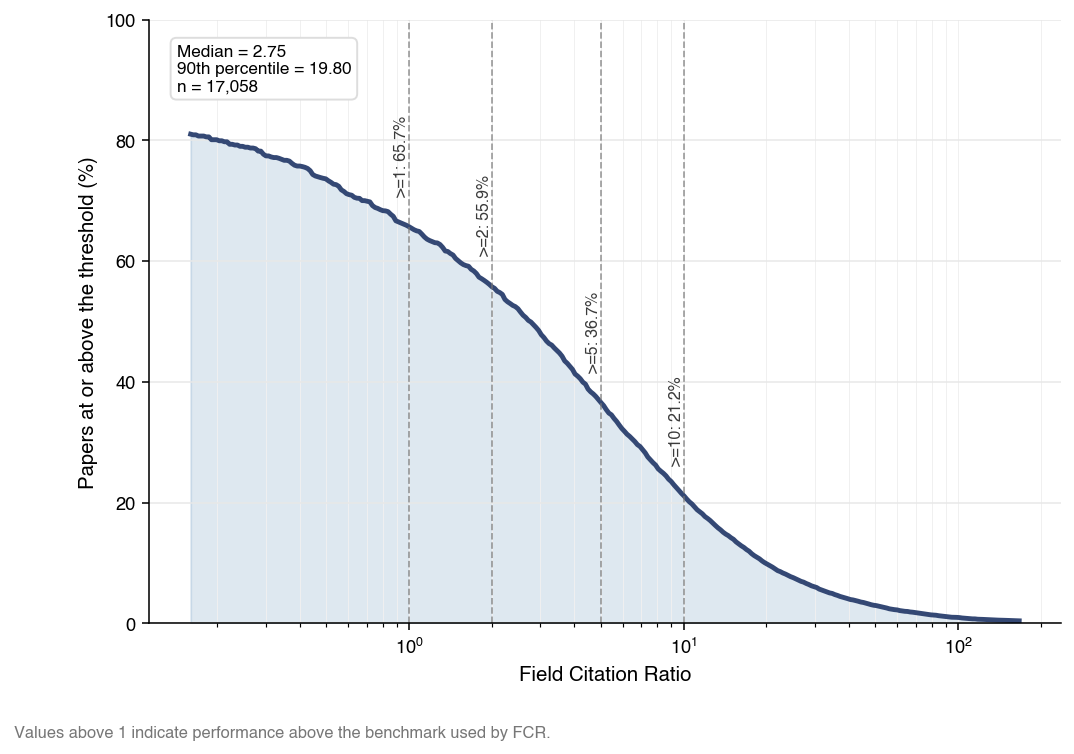

,threshold,papers_at_or_above,percent_at_or_above
0,1,11210,65.716966
1,2,9538,55.915113
2,5,6252,36.651425
3,10,3611,21.168953


In [37]:
metric_candidates = [
    ("field_citation_ratio", "Field Citation Ratio", "FCR"),
    ("relative_citation_ratio", "Relative Citation Ratio", "RCR"),
    ("citations_per_year", "Citations per year", "annualised citations"),
]
for metric_column, metric_label, metric_short in metric_candidates:
    valid_metric = analysis_papers[metric_column].replace([np.inf, -np.inf], np.nan).dropna()
    valid_metric = valid_metric[valid_metric.ge(0)]
    if len(valid_metric) >= 100:
        break
else:
    raise ValueError("No citation impact metric has enough valid values.")

positive_metric = valid_metric[valid_metric.gt(0)]
if positive_metric.empty:
    raise ValueError(f"{metric_label} has no positive values.")

x_min = max(float(positive_metric.quantile(0.005)), 0.02)
x_max = float(positive_metric.quantile(0.995))
x_grid = np.logspace(np.log10(x_min), np.log10(x_max), 320)
y_share = np.array([100 * valid_metric.ge(value).mean() for value in x_grid])

thresholds = [1, 2, 5, 10]
threshold_summary = pd.DataFrame({
    "threshold": thresholds,
    "papers_at_or_above": [int(valid_metric.ge(value).sum()) for value in thresholds],
    "percent_at_or_above": [100 * valid_metric.ge(value).mean() for value in thresholds],
})

figure, axis = plt.subplots(figsize=(8.4, 5.6))
axis.plot(x_grid, y_share, color=COLOUR["blue_dark"], linewidth=2.5)
axis.fill_between(x_grid, y_share, 0, color=COLOUR["blue"], alpha=0.20)

for row in threshold_summary.itertuples(index=False):
    if x_min <= row.threshold <= x_max:
        axis.axvline(
            row.threshold,
            color=COLOUR["grey"],
            linewidth=0.9,
            linestyle="--",
            alpha=0.7,
        )
        axis.text(
            row.threshold,
            min(96, row.percent_at_or_above + 5),
            f">={row.threshold:g}: {row.percent_at_or_above:.1f}%",
            rotation=90,
            ha="right",
            va="bottom",
            fontsize=8.2,
            color=COLOUR["grey_dark"],
        )

axis.set_xscale("log")
axis.set_ylim(0, 100)
axis.set_xlabel(metric_label)
axis.set_ylabel("Papers at or above the threshold (%)")
set_title(axis, "Field-normalised citation performance of Showcase+ papers")
axis.grid(axis="y", color=COLOUR["grey_light"], linewidth=0.8)
axis.grid(axis="x", color="#F0F0F0", linewidth=0.5, which="both")
axis.text(
    0.03,
    0.96,
    f"Median = {valid_metric.median():.2f}\n90th percentile = {valid_metric.quantile(0.90):.2f}\nn = {len(valid_metric):,}",
    transform=axis.transAxes,
    ha="left",
    va="top",
    fontsize=8.8,
    bbox={"facecolor": "white", "edgecolor": "#DDDDDD", "boxstyle": "round,pad=0.35"},
)

note = (
    f"Values above 1 indicate performance above the benchmark used by {metric_short}."
    if metric_short in {"FCR", "RCR"}
    else "A field-normalised ratio was unavailable, so citations per year are shown."
)
figure.text(0.01, -0.035, note, fontsize=8.4, color=COLOUR["grey"])
save_figure(figure, "fig07_normalised_citation_performance")
plt.show()

threshold_summary.to_csv(
    TABLE_DIR / "fig07_normalised_citation_thresholds.csv", index=False
)
display(threshold_summary)


## 11. Output check

The final cell lists the files written by this run. The notebook itself remains the readable record of how each figure was calculated.


In [38]:
promoted_stems = {"fig03_leading_venues_by_citations"}
figure_files = sorted(
    path for path in FIGURE_DIR.glob("*.png") if path.stem not in promoted_stems
)
table_files = sorted(
    path for path in TABLE_DIR.glob("*.csv") if path.stem != "fig03_venue_impact"
)

print(f"Created {len(figure_files)} PNG figures (with matching PDF files).")
for path in figure_files:
    print(" -", path.name)

print(f"\nCreated {len(table_files)} analysis tables.")
for path in table_files:
    print(" -", path.name)


Created 6 PNG figures (with matching PDF files).
 - fig01_disciplinary_composition.png
 - fig02_cumulative_output_and_citation_stock.png
 - fig04_field_citation_impact.png
 - fig05_citation_concentration.png
 - fig06_age_adjusted_citation_cohorts.png
 - fig07_normalised_citation_performance.png

Created 7 analysis tables.
 - fig01_disciplinary_composition.csv
 - fig02_cumulative_output_and_citation_stock.csv
 - fig04_field_citation_impact.csv
 - fig05_citation_concentration_checkpoints.csv
 - fig05_citation_concentration_curve.csv
 - fig06_age_adjusted_citation_cohorts.csv
 - fig07_normalised_citation_thresholds.csv


---

## Execution boundary before Part 4: Publication figure assembly

The following reset deliberately reproduces the fresh Python kernel used by the former
`03_academic_impact_99_all.ipynb` while leaving files written by earlier parts available to this one.


In [39]:
# Reproduce the clean-kernel boundary that separated the source notebooks.
try:
    import matplotlib as _boundary_mpl
    import matplotlib.pyplot as _boundary_plt
    _boundary_plt.close("all")
    _boundary_mpl.rcdefaults()
except ImportError:
    pass

import warnings as _boundary_warnings
_boundary_warnings.resetwarnings()

from IPython import get_ipython as _boundary_get_ipython
_boundary_get_ipython().run_line_magic("reset", "-f")


# Part IV: Assembled publication panels

**What this part is.** The one place analysis 03's figures are *selected* and
*assembled*, on the model of
[`04_non_academic.ipynb`](04_non_academic.ipynb). Parts I–III retain the
data work and diagnostics, while this part re-draws the charts that made the cut into
one main-paper panel and three
supplementary panels.

| source part | charts | arm |
|---|---|---|
| Part I | 11 | volume, activity index, citation impact, quality bands, growth — by **field** |
| Part II | 2 current figures plus retained author tables | entry cohorts and influence fingerprint — by **author** |
| Part III | 6 | publication-level citation and disciplinary diagnostics |

## The argument the figures make

Analysis 01 owns UK Biobank's *output*. This one owns its **position relative to the rest
of the literature**, which is the only thing the two-arm design can say and nothing else
in the project can. Every panel is a ratio against the whole database:

> where UK Biobank's work **lands** against how much of it there is (A) · what it is
> disproportionately **about** (B) · how much of each field's **best** work is its (C) ·
> and how its footprint splits at each field's own bars, field by field (D–K).

**Comparative panel window: 2015–2025 inclusive**, for both UK Biobank and the comparison
literature. Citation references unavailable in early years are reported as unmeasured.
UK Biobank accounts for a small share of the tagged literature. A *share* of a field is therefore small everywhere by
construction and mostly reproduces "which fields are big", which is why both of the
page's ranking panels are activity indexes rather than shares, and why none of the volume
charts made the cut.

## Re-drawn, not pasted

Same rule as 04 (D28). Every panel is re-drawn from the data through `draw_<name>(ax, D)`
functions in
[`data_analysis_03_academic_impact_panels.py`](../utils/data_analysis_03_academic_impact_panels.py),
into a figure this notebook has already sized, under one style section — never by pasting
saved images. **Nothing has to be on disk for that**, which is why §1 is an inventory and
not a gate: Part I inherits `save: false` and writes none of its 11 charts.

The palette is `shared_style.PALETTE_COLORS` — **the same seven named colours analysis 04
is drawn in** (D29), so the two figure families belong to one paper. Where a chart needs
more than seven categories or an ordered ramp, it is derived from those anchors rather
than reaching for a new hue.

## The selection

Decided with the project owner on **2026-09-09** against all 14 charts, and cut again on
**2026-09-10**. Unlike 04, this selection **does** discard: nine of the fourteen are in
neither the main figure nor the SI — including all three of the author arm's, which were
SI 3 until the second cut — and §3 records the reason per chart rather than leaving it
implicit.

| figure | panels | contents |
|---|---|---|
| **Main** | A–K | impact map (2×2) · activity index · top-decile share · the footprint cut twice, a 2×4 field block spanning the page, one letter per field |
| **SI 1** | A–B | the impact map at 25 fields, every point labelled · those same 25 fields' top-decile share year by year |
| **SI 2** | A–B | growth, not size: rates, and the trajectories behind them |

## Naming

Per **D30**, the pages are named by the `01_growth` scheme —
`03_01_figure_05_…` for manuscript Figure 5 and `03_02_supplementary_figure_01_…` onwards for
the SI — not by the role-based scheme 04 originally used and has since been renamed off.

## 1. Setup

The style section is `03_academic_impact_panels` — the seven-colour palette that
`shared_style.PALETTE_COLORS` names, dashed gridlines on both axes and both tick levels,
and `save: true` writing PDF and PNG, with PNG at 500 dpi into
`output/figures/data_analysis/03_academic_impact/`.

§1's inventory is **informational**. The author arm's three figures are on disk because
Part II sets `save = True`; the field arm's eleven are not, because Part I inherits
`save: false`. Neither fact affects anything below — nothing here reads a saved figure,
and none of those three is drawn on this page any more (§3).

In [40]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched from
# (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# The panel module is edited while this notebook stays open; without autoreload a
# re-run of a figure cell silently reuses the function imported at kernel start.
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from utils.shared_style import PALETTE_COLORS, load_style
from utils import data_analysis_03_academic_impact_panels as NP

STYLE = load_style("03_academic_impact_panels")

FIG_DIR = Path(STYLE["savedir"])
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("palette :", ", ".join(f"{k}={v}" for k, v in PALETTE_COLORS.items()))
print("figures :", P.raw_path(FIG_DIR), "|", ", ".join(STYLE["formats"]),
      "at dpi", STYLE["dpi"])
print("tables  :", P.raw_path(TABLE_DIR))
print("grid    :", STYLE["grid_linestyle"], "on both axes, major and minor")

_on_disk = sorted({f.stem for f in FIG_DIR.glob("*.*")
                   if f.suffix.lower() in {".pdf", ".png"}})
print(f"\n{len(_on_disk)} figure stem(s) already under that directory "
      f"(informational — the assembly re-draws and reads none of them):")
for stem in _on_disk:
    print("   ", stem)

palette : red=#E66859, cream=#FEE7BA, light_blue=#75BBD4, blue=#74ADD1, steel_blue=#416FA0, navy=#274668, green=#74D1AF
figures : output/figures/data_analysis/03_academic_impact | pdf, png at dpi 500
tables  : output/tables/03_academic_impact
grid    : -- on both axes, major and minor

8 figure stem(s) already under that directory (informational — the assembly re-draws and reads none of them):
    03_01_figure_05_academic_impact
    03_02_supplementary_figure_01_impact_map_full
    03_03_supplementary_figure_02_growth
    03_03_supplementary_figure_02_top_decile_share
    03_04_supplementary_figure_03_author_arm
    03_04_supplementary_figure_03_growth
    fig3a_author_entry_cohort_academic_impact_profile
    fig_author_influence_fingerprint_heatmap


## 2. Build the aggregates — once, from both arms

Roughly 20 seconds: `AI.build` loads the two count arms off the API pathway, then the
measured cut-off tables and the author arm's two written tables. Everything the panels
draw comes out of this one dict, so a figure cannot quietly read a different vintage of
the data than its neighbour.

**The author arm is read, not rebuilt.** Its tables come from
Part II, which is responsible for them;
rebuilding here would mean re-exploding 267,571 author slots out of the corpus parquet to
reproduce a file that already exists. The paper-level table is 62 MB and is read six
columns wide rather than twenty-four.

`assert_parameters_match()` then checks the loaded run against this module's constants —
they are copied from Part I's §2 rather than imported, because a notebook
cannot be imported, so the tripwire is what stops the two drifting.

In [41]:
D = NP.build_panel_data()
NP.assert_parameters_match(D)
print("\nparameters match the loaded run.")

loading both arms from data/analysis/academic_impact/for_counts_api (API pathway) …
loading for partials from data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 613 rows, 113 fields, blank labels 0.0%
  background 1 partial(s), 2,223 rows, 171 fields, blank labels 0.0%
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10f, n_top10f_docs, n_top50f, n_top50f_docs
  citation weights: n_cit, n_top10f, n_top50f, n_mncs
  no relative ratio for n_cit — not normalised by publication year, and the two arms'
     papers are not s

  cut-offs: top decile in 213 cell(s), median in 213


  author arm: 266,131 author-paper rows, 88,662 distinct authors
  growth: 23 field(s) clear the floors; UK Biobank overall 26%/yr over 2021-2025

UK Biobank is 0.044% of the whole database over 2015-2025 (n_papers).
done.

parameters match the loaded run.


### What the two arms actually contain

Printed rather than remembered — these are the numbers the panels are drawn on, and they
are the rows to check against `doc/STATE.md` §2 before quoting anything from the figures.

In [42]:
print(f"analysis window      {NP.ANALYSIS_MIN}-{NP.ANALYSIS_MAX}   "
      f"(vocabulary: {D['SYSTEM']} {D['LEVEL']})")
print(f"UK Biobank's share   {D['ukbb_overall_share']:.3f}% of the whole database")
print(f"citation window      {D['CITE_WIN'][0]}-{D['CITE_WIN'][1]}   "
      f"headline {D['CITE_HEADLINE']}")
print(f"measured cut-offs    {int(D['CUTS'].thr10.notna().sum())} (year, field) cells")
print(f"authors              {len(D['author']['summary']):,} distinct\n")

print(f"UK Biobank's top {NP.TOP_N} fields — share, activity index, relative impact:\n")
_head = D["CITE_HEADLINE"][2:]
_rows = []
for code_, lab in zip(D["TOP_CODES"], D["TOP_LABELS"]):
    _rows.append({
        "field": lab,
        "ukbb_papers": int(D["ukbb"][(D["ukbb"].for_label == lab)
                                     & D["ukbb"].year.between(NP.ANALYSIS_MIN,
                                                              NP.ANALYSIS_MAX)]
                           [D["VALUE"]].sum()),
        "activity_x": round(D["ACTIVITY"].get(code_, float("nan")), 2),
        f"rci_{_head}": round(D["IMPACT"].loc[code_, f"rci_{_head}"], 2),
    })
display(pd.DataFrame(_rows))

print("author-entry cohort shares (%):")
display((100 * D["author"]["contrib_share"]).round(1))

analysis window      2015-2025   (vocabulary: Fields of Research (ANZSRC 2020) L4)
UK Biobank's share   0.044% of the whole database
citation window      2015-2025   headline n_mncs
measured cut-offs    213 (year, field) cells
authors              88,662 distinct

UK Biobank's top 8 fields — share, activity index, relative impact:



,field,ukbb_papers,activity_x,rci_mncs
0,Epidemiology,6256,12.00,1.80
1,Clinical Sciences,5458,0.86,2.83
2,Genetics,5321,6.20,2.72
3,Biological Psychology,2244,2.42,2.12
4,Cardiovascular Medicine and Haematology,1904,1.84,4.29
5,Public Health,1864,0.93,3.11
6,Oncology and Carcinogenesis,1359,0.74,1.62
7,Health Services and Systems,1207,0.32,3.04


author-entry cohort shares (%):


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,5.0,19.6,35.8,39.6
Fractional paper credit,18.1,25.6,32.5,23.8
Fractional citation credit,42.8,32.8,20.1,4.3
Top-decile paper credit,24.4,28.3,31.7,15.6
First/last-author credit,18.5,26.5,32.7,22.3


## 3. The selection, on the record

One row per panel: which figure, which letter, and the caption line that goes under it —
plus the charts that are in **neither** figure, with the reason. Written to
`output/tables/03_academic_impact/panel_selection.csv` so the paper draft and this
notebook cannot disagree about which chart is panel D, or about why chart 6 is absent.

**Two debts this selection leaves owing**, both consequences of dropping the quality-band
SI and chart 6:

1. **Chart 9 is now a main-paper panel (D), so its cut-offs need a methods home.** §6.1 of
   Part I measures what "top decile" and "above the median" were worth in
   citations per (year, field) — 213 measured L4 cells, the decile landing at 7.30–10.00%
   and the median at 34.23–50.00%. The panel annotations carry the final year's pair, so
   the figure is partly self-documenting, but the full table belongs in the methods
   section as a **table**.
2. **Nothing now shows the impact result surviving the choice of measure.** That was
   chart 6's left panel. `n_mncs`, `n_top10f` and `n_top50f` rank the fields differently
   by construction. Cheapest mitigation: carry all three columns in SI 1's `IMPACT` table
   rather than the headline alone — which the table written below does.

In [43]:
rows = [{"figure": P.MAIN_FIGURE_STEMS[5], "panel": letter,
         "caption": caption}
        for letter, caption in NP.MAIN_CAPTION.items()]
_si_stems = {"impact_map": "03_02_supplementary_figure_01_impact_map_full",
             "top_decile": "03_03_supplementary_figure_02_top_decile_share",
             "growth": "03_04_supplementary_figure_03_growth"}
rows += [{"figure": _si_stems[section], "panel": letter, "caption": caption}
         for section, captions in NP.SI_CAPTIONS.items()
         for letter, caption in captions.items()]

# The charts in NEITHER figure. Recorded here so the reason survives the decision rather
# than living only in a chat log.
EXCLUDED = {
    "chart 1":  "whole-database trends with UK Biobank stacked in. The slice is invisible "
                "in 7 of 8 panels - true, and the point of the 0.044% fact, but it cannot "
                "carry a panel. 01_growth owns output.",
    "chart 2":  "UK Biobank papers per field and share of field. Volume, not position; "
                "01_growth owns it, and panel A divides the size out anyway.",
    "chart 3":  "annual growth speed, the first difference of chart 1. A diagnostic - the "
                "series is dominated by year-to-year sawtooth.",
    "chart 6":  "the measures-agree dot chart and impact over time. Dropped in favour of "
                "chart 7 as the single impact headline; the IMPACT table now has to carry "
                "the measure-robustness result numerically. See the note in section 3.",
    "chart 9a": "chart 9 against the cut-offs themselves on a second axis.",
    "chart 10": "the size of each field's top-decile pool and UK Biobank's share of it.",
    "sec 4.3":  "the marginal annual increase table (before vs after UKBB_YEAR).",
    "fig3a":    "author entry cohorts: share of authors, credit and top-decile credit by "
                "the year an author first published. Was SI 3A until 2026-09-10, when the "
                "author arm came out of this figure set - the page is the FIELD arm's "
                "argument, and a reader who wants the author result has "
                "Part II of this notebook, which owns the tables either way.",
    "fig3b":    "the author portfolio map, 11,022 authors as output against "
                "field-normalised impact. Out with the rest of the author arm "
                "(2026-09-10); it was also the 8 MB svg that ended svg exports.",
    "fig3c":    "the author influence fingerprint, 25 named individuals by percentile "
                "rank. Out with the rest of the author arm (2026-09-10).",
}
rows += [{"figure": "(excluded)", "panel": chart, "caption": why}
         for chart, why in EXCLUDED.items()]

selection = pd.DataFrame(rows)
selection.to_csv(TABLE_DIR / "panel_selection.csv", index=False)
print(f"{len(NP.MAIN_CAPTION)} main panels + "
      f"{sum(len(c) for c in NP.SI_CAPTIONS.values())} SI panels + "
      f"{len(EXCLUDED)} excluded charts -> "
      f"{P.raw_path(TABLE_DIR / 'panel_selection.csv')}\n")
display(selection)

4 main panels + 4 SI panels + 10 excluded charts -> output/tables/03_academic_impact/panel_selection.csv



,figure,panel,caption
0,03_01_figure_05_academic_impact,A,Where UK Biobank concentrates against where th...
1,03_01_figure_05_academic_impact,B,"A's horizontal axis on its own, ranked: what U..."
2,03_01_figure_05_academic_impact,C,"A's vertical question over time, at the sharp ..."
3,03_01_figure_05_academic_impact,D-K,"The footprint cut twice, one lettered panel pe..."
4,03_02_supplementary_figure_01_impact_map_full,A,The impact map at UK Biobank's 25 largest fiel...
5,03_03_supplementary_figure_02_top_decile_share,A,Main-figure panel C undrawn-down: UK Biobank's...
6,03_04_supplementary_figure_03_growth,A,"Compound annual growth 2021–2025 by field, UK ..."
7,03_04_supplementary_figure_03_growth,B,The absolute trajectories those rates summaris...
8,(excluded),chart 1,whole-database trends with UK Biobank stacked ...
9,(excluded),chart 2,UK Biobank papers per field and share of field...


## 4. The main-paper panel

Three lettered panels on a three-column grid, over a block of eight more:

```text
+---------------------------+-----------+
|                           |     B     |   A     impact map        (2 rows x 2 cols)
|             A             +-----------+   B     activity index    (top right)
|                           |     C     |   C     top-decile share  (below it)
+---------------------------------------+   D-K   the footprint block, full width,
|                  D  -  K              |         one lettered panel per field
+---------------------------------------+
```

**The impact map leads and takes the largest slot.** It is the one panel carrying both
questions at once — how much UK Biobank publishes in a field, and how well that work is
cited there — so the two panels beside it read as its margins: **B** is its horizontal
axis on its own, ranked; **C** is its vertical question over time, at the sharp end.
**D–K** then put the quality claim back into each field's own citation distribution,
which is why they need the full width.

Reading notes worth carrying into the caption:

* **A**'s solid rule is UK Biobank's **own** average impact, not world parity. Against the
  world essentially every field is above 1×, so that line tells nothing apart. Its
  horizontal axis is measured `within_parent` — each L4 field against its own L2 division
  — which is what removes "UK Biobank is a biomedical resource" from the comparison.
  Epidemiology reads **12.0×** its own division and **61.4×** against all research; the
  gap between those two numbers is why the notebook defaults to the former.
* **A** labels Clinical Sciences to the **left** of its point, alone among the labels.
  It sits a few percent left of the parity rule with Public Health just right of it at
  almost the same impact, so a label to the right runs over Public Health's dot.
* **B** is cut to 10 fields. **C** is cut to the **five** fields that reach furthest and
  names them in a boxed legend, three rows by two, rather than at the end of each line:
  eight direct labels and the empty years they need to sit in were spending a third of the
  panel's width on names, in the panel that has the least width to spend. The legend names
  the fields and nothing else — the shares are on the axis the lines are read against — and
  the dashed overall rule takes the sixth entry, so the rule is named once, in the legend,
  and annotated on the axis with its value alone. SI 1B is the same chart at 25 fields and
  full width, where direct labels are affordable and are the better encoding.
* **C** and **D–K** share a numerator and differ in denominator, and they are not the same
  number. C divides by the **field's** top-decile papers ("how much of this field's best
  work is UK Biobank's", 7.3% for Epidemiology in 2025); the block's solid band divides by
  **all** the field's papers; its in-panel % divides by **UK Biobank's own** papers in the
  field. Two of them being close in a given year is a coincidence, not a cross-check.
* **The block states no cut-offs and carries no grid.** Each sub-panel used to carry a
  grey line giving what the two bars were worth in citations that year; it was removed on
  2026-09-09 to leave the bands uncluttered, and the gridlines followed on 2026-09-10 —
  eight small panels of dashed rules read as hatching, and each is read for the shape of
  its bands rather than off its ticks. §4.1 writes those numbers to a table instead, and
  **the methods section now has to carry it** — without it the figure does not say whether
  a median band means "above the median" or "cited at all".
* **Every field gets its own letter, D through K.** They were one panel D until
  2026-09-10; they are eight panels, and a reader citing the genetics one needs an address
  for it.

**Panel E is gone from this page**, and so is the author arm it belonged to. The cohort
profile moved to SI 3 when the page went to three columns on 2026-09-09, and came out of
the figure set altogether the next day (§3).


saved output/figures/data_analysis/03_academic_impact/03_01_figure_05_academic_impact.pdf


saved output/figures/data_analysis/03_academic_impact/03_01_figure_05_academic_impact.png


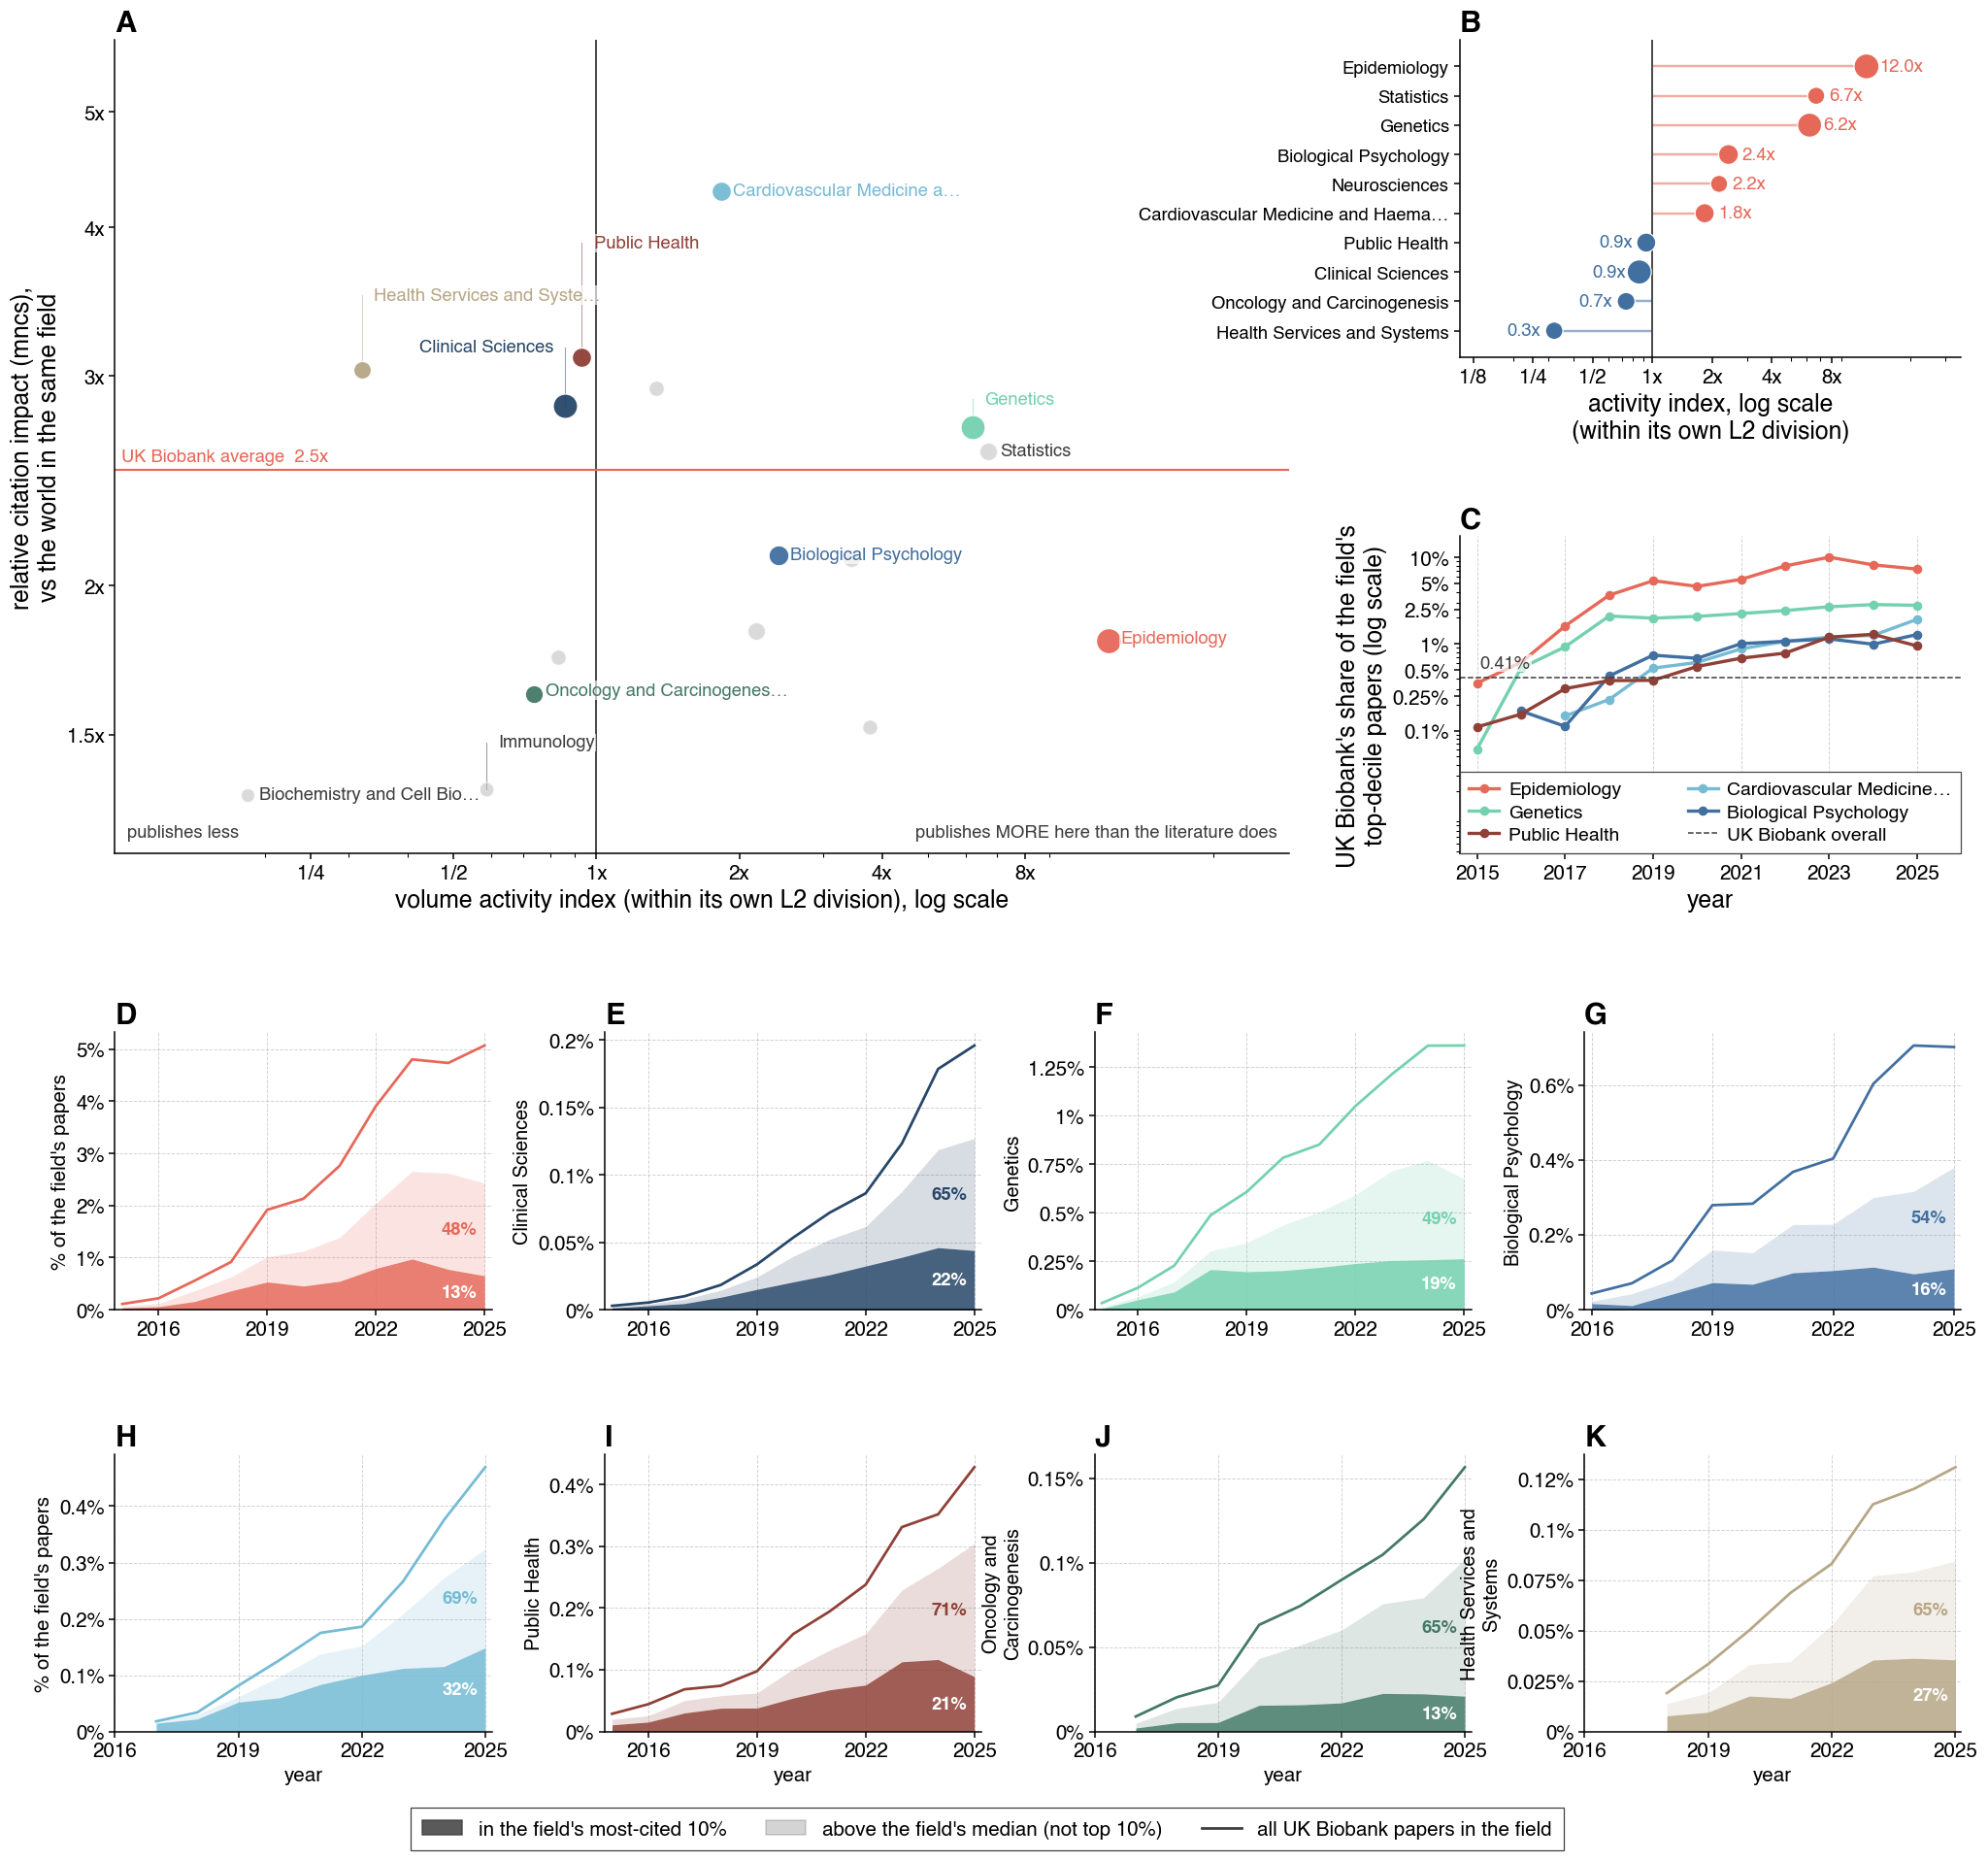

In [44]:
fig_main = NP.figure_main(D)

### 4.1 What panel D's bars were worth, in citations *(for the methods section)*

Panel D cuts each field's footprint at that field's own top decile and median. Both
cut-offs are **measured** per (year, field) by binary search against the live index, not
interpolated — and both fall steeply with publication year because citations accrue:
2015's tenth-best Epidemiology paper needed 63 citations, 2025's needs 8. That is the
clock, not a decline in standards, and it is exactly why the cut is taken per year.

**Read `median_achieved_pct` before quoting a median band.** Citations are small integers
with enormous ties, so in a recent year the cut lands at "≥ 1 citation" and keeps as
little as 34% of the field. The count above the cut is still exact; what is approximate is
calling it the 50th percentile.

The table holds the cells **panel D draws** — the eight fields, inside the window, where
the decile was actually measured. That is a subset of the **213** measured L4 cells across
all 113 fields, over which the decile lands at 7.30–10.00% (median 9.77%) and the median
at 34.23–50.00% (median 47.69%).

In [45]:
cuts = NP.cut_off_table(D)
cuts.to_csv(TABLE_DIR / "panel_d_citation_cutoffs.csv", index=False)
print(f"{len(cuts)} measured (year, field) cells -> "
      f"{P.raw_path(TABLE_DIR / 'panel_d_citation_cutoffs.csv')}\n")

_m = cuts.dropna(subset=["median_achieved_pct"])
print(f"top-decile cut achieved  {cuts.top_decile_cites.notna().sum()} cells")
print(f"median cut achieved      {_m.median_achieved_pct.min():.2f}% - "
      f"{_m.median_achieved_pct.max():.2f}%  (median {_m.median_achieved_pct.median():.2f}%); "
      f"{int((_m.median_achieved_pct < 45).sum())} cells more than five points short\n")

# The final year for each field, which is what the panels' sharp end shows.
display(cuts[cuts.year == NP.ANALYSIS_MAX]
        .set_index("field")[["top_decile_cites", "median_cites", "mean_cites",
                             "median_achieved_pct"]])

81 measured (year, field) cells -> output/tables/03_academic_impact/panel_d_citation_cutoffs.csv

top-decile cut achieved  81 cells
median cut achieved      34.77% - 50.00%  (median 48.13%); 12 cells more than five points short



,top_decile_cites,median_cites,mean_cites,median_achieved_pct
field,,,,
Biological Psychology,7.0,1.0,2.21,49.03
Cardiovascular Medicine and Haematology,5.0,1.0,1.45,34.77
Clinical Sciences,5.0,1.0,1.69,41.76
Epidemiology,8.0,2.0,2.90,39.06
Genetics,7.0,2.0,2.60,38.00
Health Services and Systems,5.0,1.0,1.72,42.34
Oncology and Carcinogenesis,8.0,1.0,2.67,48.24
Public Health,6.0,1.0,2.09,48.44


## 5. SI 1 — The impact map at 25 fields

Main-figure panel A carries UK Biobank's 16 largest fields and labels the top eight plus
whatever is extreme on either axis. This is the same map undrawn-down: 25 fields, every
one labelled, at full page.

**SI 2 is its companion** — the same 25 fields' share of their own top decile, year by
year. Both pages take their field set from `map_fields`, so they cannot disagree about
which 25, and a field's line there can be read straight off its point here. They are two
pages rather than one because two label-dense full-width panels on a single sheet leave
neither of them readable.

The `IMPACT` table beneath the figure is the numbers behind every version of the map, and
it carries **every** weight that takes a ratio rather than only the headline — which is
where the measure-robustness result now lives, chart 6 having been dropped (§3).


saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.pdf


saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.png
25 fields x 8 measures -> output/tables/03_academic_impact/si1_impact_table_all_weights.csv



,ukbb_papers,activity_x,rci_top10f,act_top10f,rci_top50f,act_top50f,rci_mncs,act_mncs
field,,,,,,,,
Epidemiology,6256.0,12.003,1.965,12.902,1.134,14.367,1.797,44.029
Clinical Sciences,5458.0,0.859,3.118,0.617,1.477,0.563,2.832,2.090
Genetics,5321.0,6.201,2.484,4.774,1.196,4.433,2.719,19.496
Biological Psychology,2244.0,2.420,2.064,1.926,1.104,1.986,2.123,6.854
Cardiovascular Medicine and Haematology,1904.0,1.835,4.302,2.135,1.677,1.605,4.289,6.758
Public Health,1864.0,0.932,3.231,1.647,1.453,1.428,3.111,5.918
Oncology and Carcinogenesis,1359.0,0.738,1.946,0.382,1.370,0.518,1.624,1.029
Health Services and Systems,1207.0,0.320,3.080,0.604,1.392,0.526,3.037,1.985
Statistics,1136.0,6.695,2.088,2.229,1.230,2.532,2.594,8.838


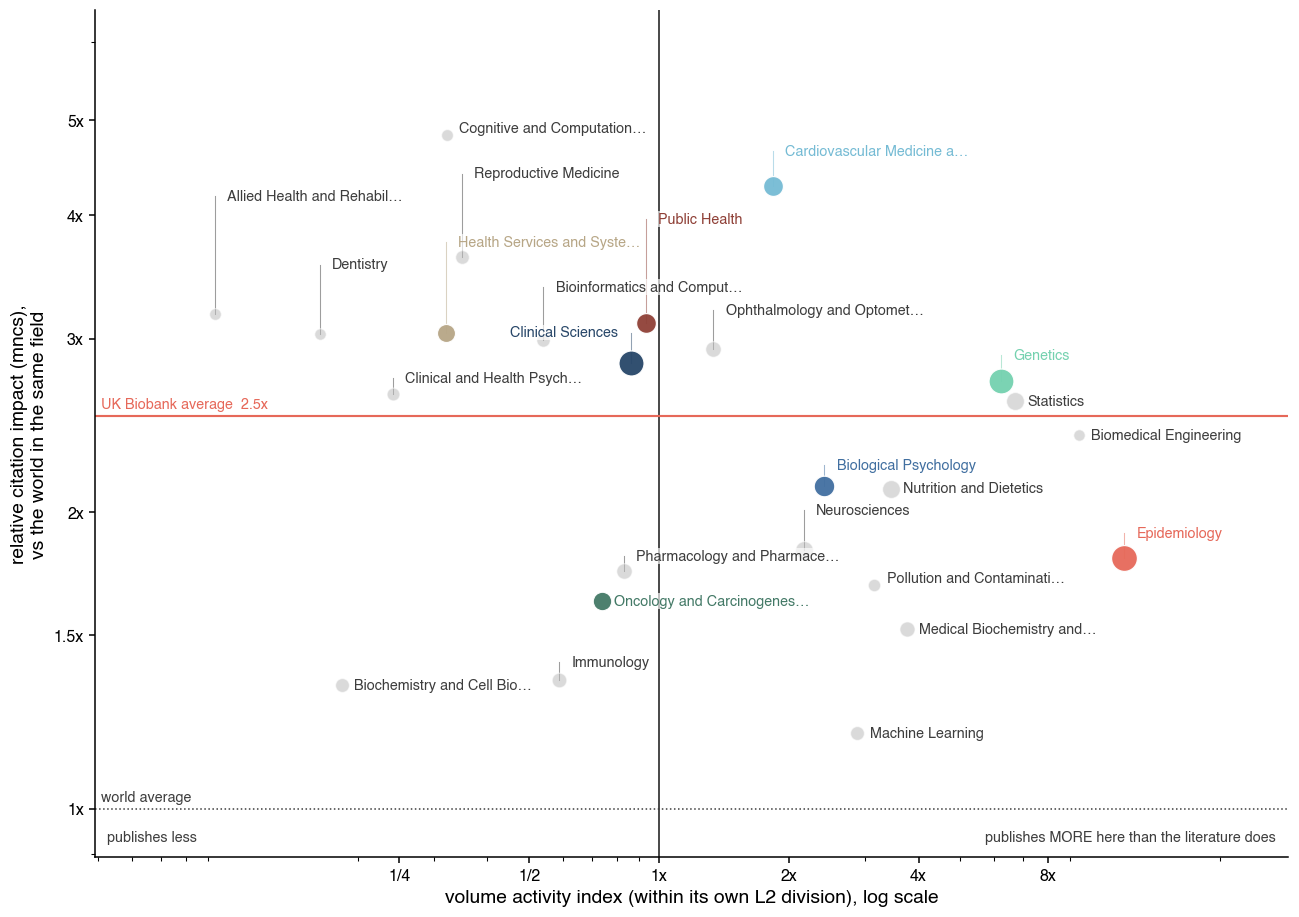

In [46]:
fig_si1 = NP.figure_si_impact_map(D)

# Every rci_ weight, not just the headline: with chart 6 out of the figure set, this
# table is the only place the reader can see whether a field's ranking survives the
# choice of measure.
_cols = ["ukbb_papers", "activity_x"] + [c for c in D["IMPACT"].columns
                                         if c.startswith(("rci_", "act_"))]
impact_out = (D["IMPACT"][_cols]
              .assign(field=[D["label_of"](c) for c in D["IMPACT"].index])
              .set_index("field")
              .nlargest(NP.MAP_M_SI, "ukbb_papers")
              .round(3))
impact_out.to_csv(TABLE_DIR / "si1_impact_table_all_weights.csv")
print(f"{len(impact_out)} fields x {len(_cols)} measures -> "
      f"{P.raw_path(TABLE_DIR / 'si1_impact_table_all_weights.csv')}\n")
display(impact_out)

## 6. SI 2 — The top-decile share at 25 fields

Main-figure panel C is cut to the five fields that reach furthest and read off a legend,
because it has one column of three to live in. This is the same chart at full page with
nothing left implicit: every field SI 1 maps gets its line and its name, the eight the
family follows in their own colours and the other 17 in the map's grey.

It is the panel that carries the analysis's sharpest claim — UK Biobank is 0.044% of the
literature and **7.3%** of Epidemiology's most-cited tenth in 2025 — so the SI shows the
claim's whole surface: which fields clear the overall 0.41% rule, which sit under it, and
how far down the tail the measure stays interpretable at all.


saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.pdf


saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.png


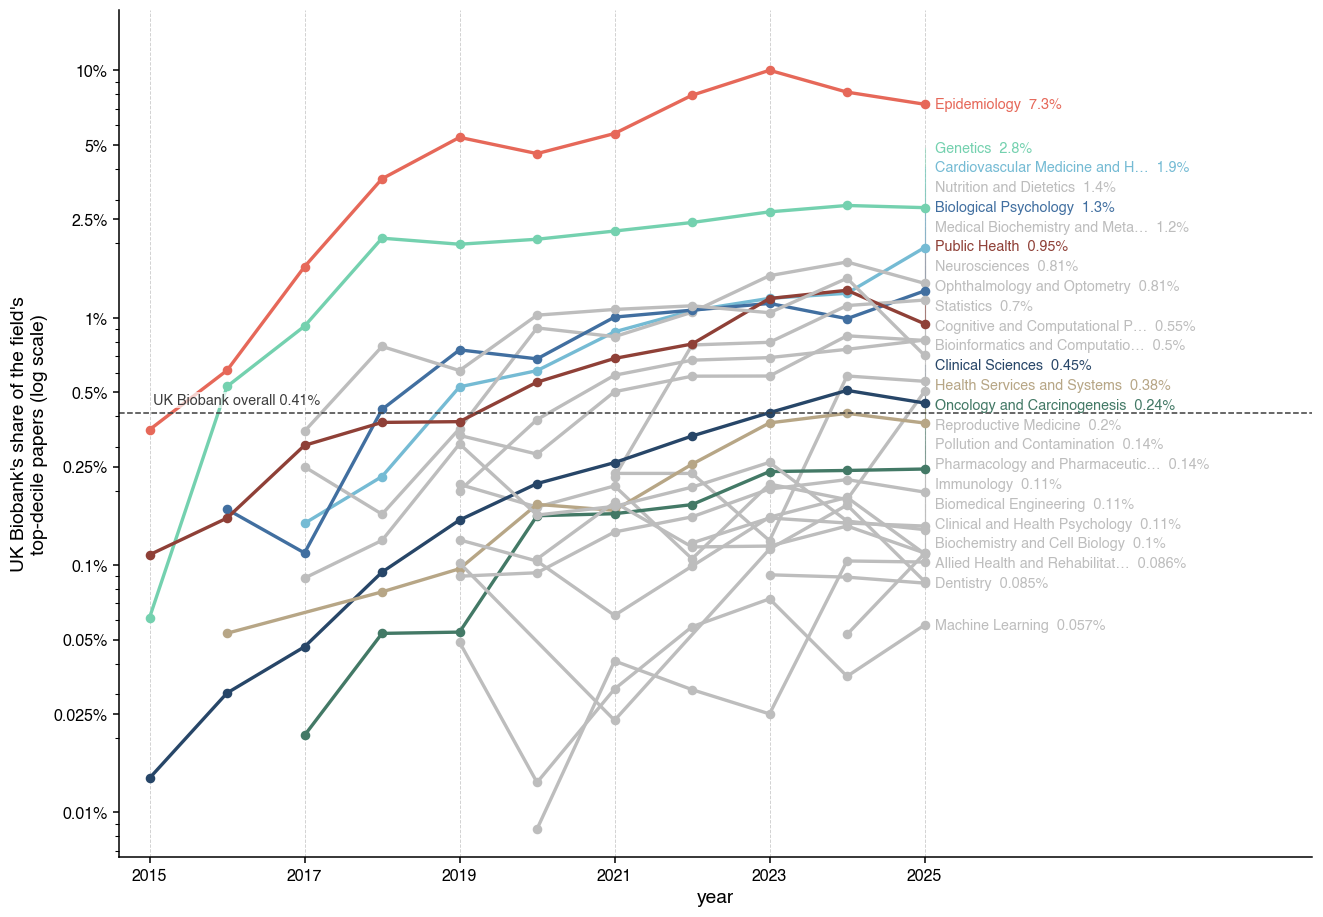

In [47]:
fig_si2 = NP.figure_si_top_decile(D)

## 7. SI 3 — Growth, not size

Every other panel in this family ranks fields by size, which is stable by construction —
Epidemiology and Clinical Sciences were the biggest in 2016 and will be in 2026 — so it
cannot show a field *arriving*. This ranks by speed and drops the size filter.

It is in the SI rather than the main figure because it answers a **growth** question
inside an impact analysis, and analysis 01 owns growth. It is kept because the result is
not available anywhere else: the hollow marker is the same field's growth in the whole
database, so the gap between the markers is UK Biobank **moving into** a field rather than
the field itself taking off. Neurosciences is the sharpest case — the world's output is
flat (−0.2%/yr) while UK Biobank's grows 47%/yr.

Read the acceleration column knowing UK Biobank's own output was doubling annually in the
late 2010s from a base of almost nothing, so nearly every field decelerates against that
window. The number says "growing less explosively than during the ramp-up", not
"shrinking".

saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.pdf


saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.png
UK Biobank overall grew 26%/yr over 2021-2025



,ukbb@2025,ukbb_%/yr,ukbb_accel_pp,world_%/yr,activity_x
label,,,,,
Medical Biochemistry and Metabolomics,200.0,73.6,-8.5,12.6,3.8
Biomedical Engineering,35.0,62.7,13.1,7.4,9.4
Biochemistry and Cell Biology,112.0,57.9,NaN,2.2,0.2
Clinical and Health Psychology,49.0,42.2,23.2,6.2,0.2
Neurosciences,329.0,39.9,-54.7,2.2,2.2
Cognitive and Computational Psychology,39.0,37.2,-15.9,5.1,0.3
Ophthalmology and Optometry,159.0,37.1,-46.0,2.4,1.3
Nutrition and Dietetics,308.0,34.9,-18.0,6.0,3.4
Bioinformatics and Computational Biology,66.0,34.8,-43.0,0.9,0.5


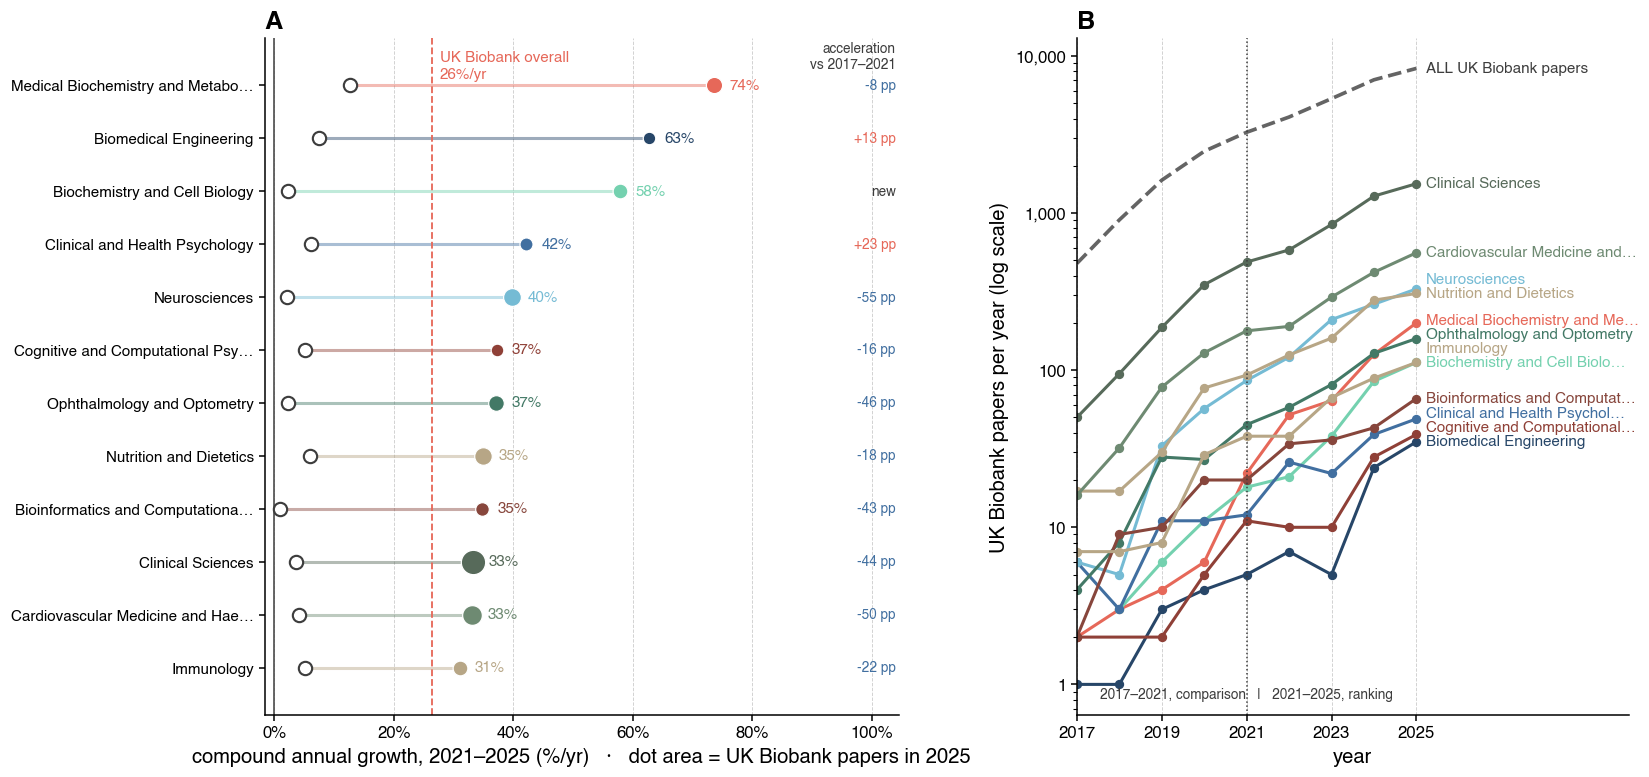

In [48]:
fig_si3 = NP.figure_si_growth(D)

growth_out = (D["GROWTH"].head(NP.GROW_TOP_M)
              .set_index("label")[["ukbb_papers", "ukbb_now", "accel",
                                   "world_now", "activity_x"]]
              .rename(columns={"ukbb_papers": f"ukbb@{NP.GROW_NOW[1]}",
                               "ukbb_now": "ukbb_%/yr", "accel": "ukbb_accel_pp",
                               "world_now": "world_%/yr"})
              .round(1))
growth_out.to_csv(TABLE_DIR / "si2_fastest_growing_fields.csv")
print(f"UK Biobank overall grew {D['UKBB_PACE']:.0f}%/yr over "
      f"{NP.GROW_NOW[0]}-{NP.GROW_NOW[1]}\n")
display(growth_out)

## 8. What was written

Every file this notebook produced, with its size, so a re-run can be compared against the
last one rather than trusted. **pdf and png only** — svg was dropped from every style
section on 2026-09-09 (the author-arm portfolio panel alone was an 8 MB svg, because each
of its 11,022 authors became its own element) and svg files are gitignored. The glob
follows D30's naming scheme, so the author notebook's own three figures — which sit in the
same directory under their `fig…` stems — are correctly not listed here, and neither is
`03_04_supplementary_figure_03_author_arm`, which this notebook no longer writes.

In [49]:
written = sorted(
    p for p in FIG_DIR.glob("03_[0-9][0-9]_*.*")
    if p.suffix.lower() in {".pdf", ".png"}
)
manifest = pd.DataFrame([
    {"file": P.raw_path(p), "kb": p.stat().st_size // 1024,
     "modified": pd.Timestamp(p.stat().st_mtime, unit="s").round("s")}
    for p in written
])
manifest.to_csv(TABLE_DIR / "panel_manifest.csv", index=False)
print(f"{len(written)} figure files under {P.raw_path(FIG_DIR)} "
      f"({manifest.kb.sum() / 1024:.1f} MB)\n")
display(manifest)

12 figure files under output/figures/data_analysis/03_academic_impact (10.0 MB)



,file,kb,modified
0,output/figures/data_analysis/03_academic_impac...,40,2026-09-22 17:15:13
1,output/figures/data_analysis/03_academic_impac...,2862,2026-09-22 17:15:15
2,output/figures/data_analysis/03_academic_impac...,20,2026-09-22 17:15:16
3,output/figures/data_analysis/03_academic_impac...,751,2026-09-22 17:15:16
4,output/figures/data_analysis/03_academic_impac...,30,2026-09-11 08:59:08
5,output/figures/data_analysis/03_academic_impac...,1669,2026-09-11 08:59:08
6,output/figures/data_analysis/03_academic_impac...,26,2026-09-22 17:15:17
7,output/figures/data_analysis/03_academic_impac...,1551,2026-09-22 17:15:17
8,output/figures/data_analysis/03_academic_impac...,88,2026-09-11 09:47:26
9,output/figures/data_analysis/03_academic_impac...,1783,2026-09-11 09:47:27
